<a href="https://colab.research.google.com/github/grammatikth/Statistics-Guided-Biomedical-Subgraph-Selection-for-Drug-Disease-Link-Prediction/blob/main/statistical_analysis_of_knowledge_graph.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import os

file_path="/content/drive/MyDrive/kg.csv"

print("File exists:", os.path.exists(file_path))
print("File size in MB:", os.path.getsize(file_path) / (1024 * 1024))

kg = pd.read_csv(file_path, low_memory=False)

print("Shape:", kg.shape)
print("Columns:")
print(kg.columns)

kg.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
File exists: True
File size in MB: 936.270938873291
Shape: (8100498, 12)
Columns:
Index(['relation', 'display_relation', 'x_index', 'x_id', 'x_type', 'x_name',
       'x_source', 'y_index', 'y_id', 'y_type', 'y_name', 'y_source'],
      dtype='object')


,relation,display_relation,x_index,x_id,x_type,x_name,x_source,y_index,y_id,y_type,y_name,y_source
0,protein_protein,ppi,0,9796,gene/protein,PHYHIP,NCBI,8889,56992,gene/protein,KIF15,NCBI
1,protein_protein,ppi,1,7918,gene/protein,GPANK1,NCBI,2798,9240,gene/protein,PNMA1,NCBI
2,protein_protein,ppi,2,8233,gene/protein,ZRSR2,NCBI,5646,23548,gene/protein,TTC33,NCBI
3,protein_protein,ppi,3,4899,gene/protein,NRF1,NCBI,11592,11253,gene/protein,MAN1B1,NCBI
4,protein_protein,ppi,4,5297,gene/protein,PI4KA,NCBI,2122,8601,gene/protein,RGS20,NCBI


In [ ]:
#generan information

x_nodes = kg[["x_index", "x_id", "x_type", "x_name", "x_source"]].copy()
x_nodes.columns = ["node_index", "node_id", "node_type", "node_name", "node_source"]

y_nodes = kg[["y_index", "y_id", "y_type", "y_name", "y_source"]].copy()
y_nodes.columns = ["node_index", "node_id", "node_type", "node_name", "node_source"]

nodes = pd.concat([x_nodes, y_nodes], ignore_index=True)
nodes = nodes.drop_duplicates(subset=["node_index"]).reset_index(drop=True)

print("Unique nodes:", nodes.shape[0])
print("Edges:", kg.shape[0])
print("Node types:", nodes["node_type"].nunique())
print("Relation types:", kg["display_relation"].nunique())

display(nodes.head())

Unique nodes: 129375
Edges: 8100498
Node types: 10
Relation types: 18


,node_index,node_id,node_type,node_name,node_source
0,0,9796,gene/protein,PHYHIP,NCBI
1,1,7918,gene/protein,GPANK1,NCBI
2,2,8233,gene/protein,ZRSR2,NCBI
3,3,4899,gene/protein,NRF1,NCBI
4,4,5297,gene/protein,PI4KA,NCBI


In [ ]:
print("Rows:", kg.shape[0])
print("Columns:", kg.shape[1])

print('------------------------')

print("x_type counts:")
print(kg["x_type"].value_counts())


kg.info()

Rows: 8100498
Columns: 12
------------------------
x_type counts:
x_type
drug                  2805696
gene/protein          2631229
anatomy               1566154
disease                341244
effect/phenotype       257096
biological_process     252202
molecular_function      96723
cellular_component      93102
pathway                 47716
exposure                 9336
Name: count, dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8100498 entries, 0 to 8100497
Data columns (total 12 columns):
 #   Column            Dtype 
---  ------            ----- 
 0   relation          object
 1   display_relation  object
 2   x_index           int64 
 3   x_id              object
 4   x_type            object
 5   x_name            object
 6   x_source          object
 7   y_index           int64 
 8   y_id              object
 9   y_type            object
 10  y_name            object
 11  y_source          object
dtypes: int64(2), object(10)
memory usage: 741.6+ MB


display_relation
expression present         3036406
synergistic interaction    2672628
interacts with              686550
ppi                         642150
phenotype present           300634
parent-child                281744
associated with             167482
side effect                 129568
contraindication             61350
expression absent            39774
target                       32760
indication                   18776
enzyme                       10634
transporter                   6184
off-label use                 5136
linked to                     4608
phenotype absent              2386
carrier                       1728
Name: count, dtype: int64


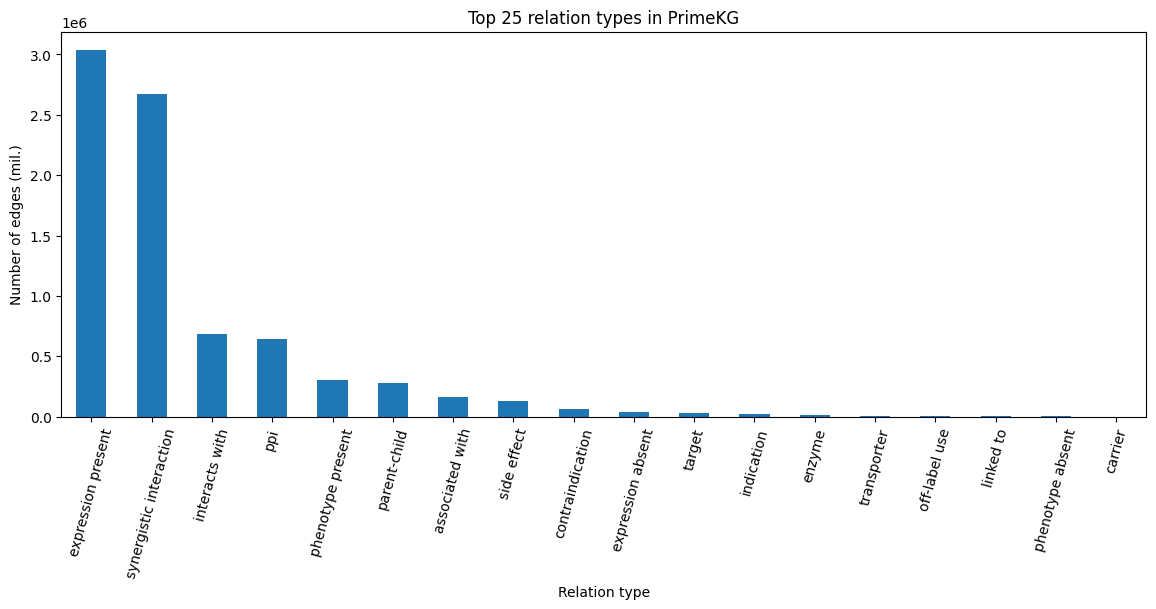

In [ ]:
#top type edges
relation_counts = kg["display_relation"].value_counts()

print(relation_counts.head(40))



import matplotlib.pyplot as plt

relation_counts.head(25).plot(kind="bar", figsize=(14, 5))
plt.title("Top 25 relation types in PrimeKG")
plt.xlabel("Relation type")
plt.ylabel("Number of edges (mil.)")
plt.xticks(rotation=75)
plt.show()

type_pair
drug - drug                                2672628
anatomy - gene/protein                     1538090
gene/protein - anatomy                     1538090
gene/protein - gene/protein                 642150
effect/phenotype - disease                  151510
disease - effect/phenotype                  151510
biological_process - gene/protein           144805
gene/protein - biological_process           144805
biological_process - biological_process     105772
cellular_component - gene/protein            83402
gene/protein - cellular_component            83402
gene/protein - disease                       80411
disease - gene/protein                       80411
molecular_function - gene/protein            69530
gene/protein - molecular_function            69530
drug - effect/phenotype                      64784
effect/phenotype - drug                      64784
disease - disease                            64388
pathway - gene/protein                       42646
gene/protein - pathwa

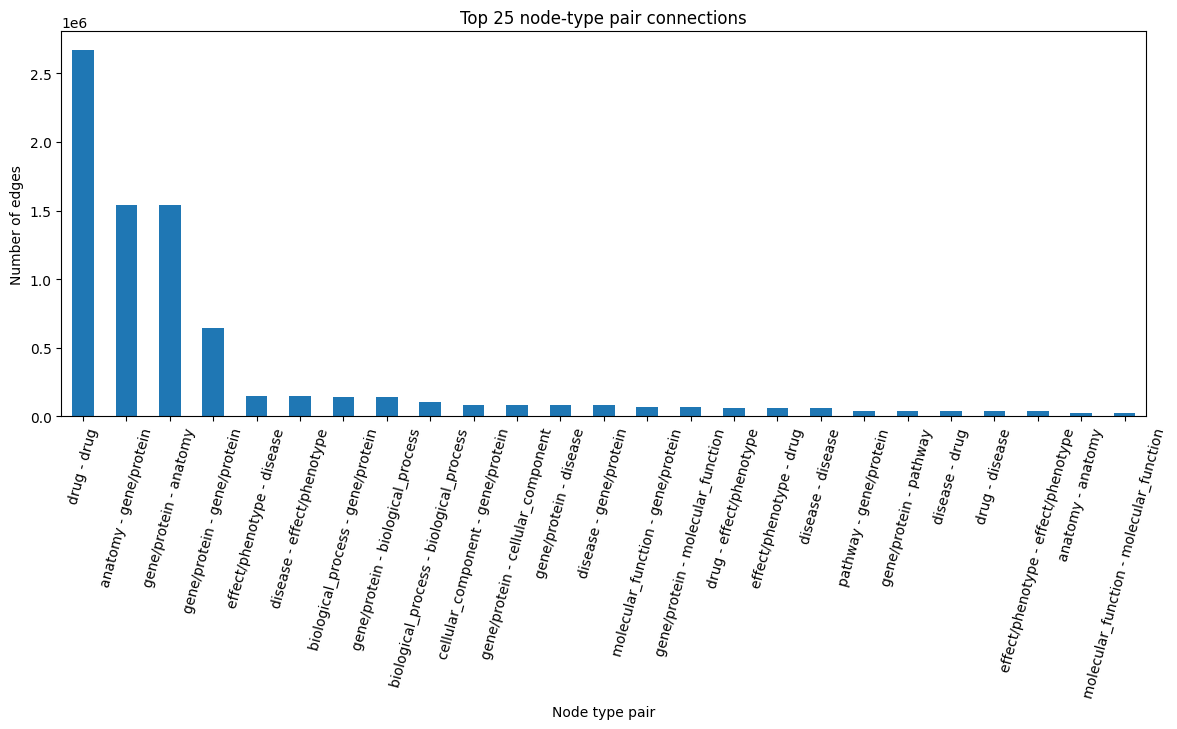

In [ ]:
kg["type_pair"] = kg["x_type"] + " - " + kg["y_type"]

type_pair_counts = kg["type_pair"].value_counts()

print(type_pair_counts.head(30))


type_pair_counts.head(25).plot(kind="bar", figsize=(14, 5))
plt.title("Top 25 node-type pair connections")
plt.xlabel("Node type pair")
plt.ylabel("Number of edges")
plt.xticks(rotation=75)
plt.show()

In [ ]:
drug_disease = kg[
    ((kg["x_type"] == "drug") & (kg["y_type"] == "disease")) |
    ((kg["x_type"] == "disease") & (kg["y_type"] == "drug"))
].copy()

# 2* only drug-> disease= 2*42631 = 85262
print("Drug-disease edges:", drug_disease.shape)

print(drug_disease["display_relation"].value_counts())

Drug-disease edges: (85262, 13)
display_relation
contraindication    61350
indication          18776
off-label use        5136
Name: count, dtype: int64


In [ ]:
#Drug–Protein
drug_protein = kg[
    ((kg["x_type"] == "drug") & (kg["y_type"] == "gene/protein")) |
    ((kg["x_type"] == "gene/protein") & (kg["y_type"] == "drug"))
].copy()

print("Drug-protein edges:", drug_protein.shape)
print(drug_protein["display_relation"].value_counts().head(30))

Drug-protein edges: (51306, 13)
display_relation
target         32760
enzyme         10634
transporter     6184
carrier         1728
Name: count, dtype: int64


In [ ]:
#Disease–Protein
disease_protein = kg[
    ((kg["x_type"] == "disease") & (kg["y_type"] == "gene/protein")) |
    ((kg["x_type"] == "gene/protein") & (kg["y_type"] == "disease"))
].copy()

print("Disease-protein edges:", disease_protein.shape)
print(disease_protein["display_relation"].value_counts().head(30))

Disease-protein edges: (160822, 13)
display_relation
associated with    160822
Name: count, dtype: int64


In [ ]:
#Pathway σχέσεις
pathway_edges = kg[
    (kg["x_type"].str.contains("pathway", case=False, na=False)) |
    (kg["y_type"].str.contains("pathway", case=False, na=False))
].copy()

print("Pathway-related edges:", pathway_edges.shape)
print(pathway_edges["x_type"].value_counts())
print(pathway_edges["y_type"].value_counts())
print(pathway_edges["display_relation"].value_counts().head(30))

Pathway-related edges: (90362, 13)
x_type
pathway         47716
gene/protein    42646
Name: count, dtype: int64
y_type
pathway         47716
gene/protein    42646
Name: count, dtype: int64
display_relation
interacts with    85292
parent-child       5070
Name: count, dtype: int64


Αν υπάρχουν πολλές drug–protein και disease–protein σχέσεις,
τότε έχει νόημα να χρησιμοποιήσουμε GNN που αξιοποιεί έμμεσες σχέσεις.

Αν υπάρχουν αρκετά indications και contraindications,
τότε έχει νόημα να κάνουμε drug–disease link prediction.

Αν υπάρχουν pathways,
τότε μπορούμε να δώσουμε και κάποια ερμηνεία μέσω paths.

In [ ]:
kg["x_type"].value_counts()
kg["y_type"].value_counts()
kg["display_relation"].value_counts().head(40)
drug_disease["display_relation"].value_counts()

#  off_laber use ειναι ενδιαφέρον για έλεγχο

,count
display_relation,
contraindication,61350
indication,18776
off-label use,5136


H αρχική στατιστική ανάλυση δείχνει πως το PrimeKG είναι κατάλληλο γιατι έχουμε:

1. αρκετές drug–disease σχέσεις για training/evaluation
2. αρκετές contraindication σχέσεις για negative sampling
3. αρκετές drug–protein και disease–protein σχέσεις για έμμεση βιολογική συσχέτιση
4. pathway πληροφορία για ερμηνεία αποτελεσμάτων

Άρα μπόρουμε να πλαρουμε ενα graph model όπως R-GCN, αντί για ένα απλό tabular/classical ML μοντέλο.


Από την αρχική στατιστική ανάλυση του PrimeKG προκύπτει ότι ο γράφος περιλαμβάνει πλούσια ετερογενή πληροφορία, με διαφορετικούς τύπους κόμβων όπως drugs, diseases, gene/proteins, pathways και phenotypes. Οι drug–disease σχέσεις περιλαμβάνουν 18,776 indications, 61,350 contraindications και 5,136 off-label use σχέσεις, γεγονός που καθιστά εφικτή τη διαμόρφωση task για drug–disease link prediction. Επιπλέον, εντοπίστηκαν 51,306 drug–protein σχέσεις και 160,822 disease–protein σχέσεις, κάτι που δείχνει ότι υπάρχουν αρκετές έμμεσες βιολογικές διαδρομές μεταξύ φαρμάκων και ασθενειών μέσω γονιδίων/πρωτεϊνών. Τέλος, η ύπαρξη 90,362 pathway-related σχέσεων επιτρέπει μια πρώτη μορφή βιολογικής ερμηνείας των προβλέψεων μέσω μονοπατιών στον γράφο.

Με βάση τα παραπάνω, η χρήση ενός ετερογενούς Graph Neural Network, όπως το R-GCN, θεωρείται κατάλληλη, κα

In [ ]:
#Data quality checks

print("Missing values per column:")
display(kg.isna().sum())

duplicate_edges = kg.duplicated(
    subset=["x_index", "y_index", "relation", "display_relation"]
).sum()

self_loops = (kg["x_index"] == kg["y_index"]).sum()

print("Duplicate edges:", duplicate_edges)
print("Self-loops:", self_loops)

print("\nUnique x_type values:")
print(sorted(kg["x_type"].dropna().unique()))

print("\nUnique y_type values:")
print(sorted(kg["y_type"].dropna().unique()))


# The conclusion is that the data is clean

Missing values per column:


,0
relation,0
display_relation,0
x_index,0
x_id,0
x_type,0
x_name,0
x_source,0
y_index,0
y_id,0
y_type,0


Duplicate edges: 0
Self-loops: 0

Unique x_type values:
['anatomy', 'biological_process', 'cellular_component', 'disease', 'drug', 'effect/phenotype', 'exposure', 'gene/protein', 'molecular_function', 'pathway']

Unique y_type values:
['anatomy', 'biological_process', 'cellular_component', 'disease', 'drug', 'effect/phenotype', 'exposure', 'gene/protein', 'molecular_function', 'pathway']


,node_type,count,percentage
0,biological_process,28642,22.138744
1,gene/protein,27671,21.388213
2,disease,17080,13.201932
3,effect/phenotype,15311,11.834589
4,anatomy,14035,10.848309
5,molecular_function,11169,8.633043
6,drug,7957,6.150338
7,cellular_component,4176,3.227826
8,pathway,2516,1.944734
9,exposure,818,0.632271


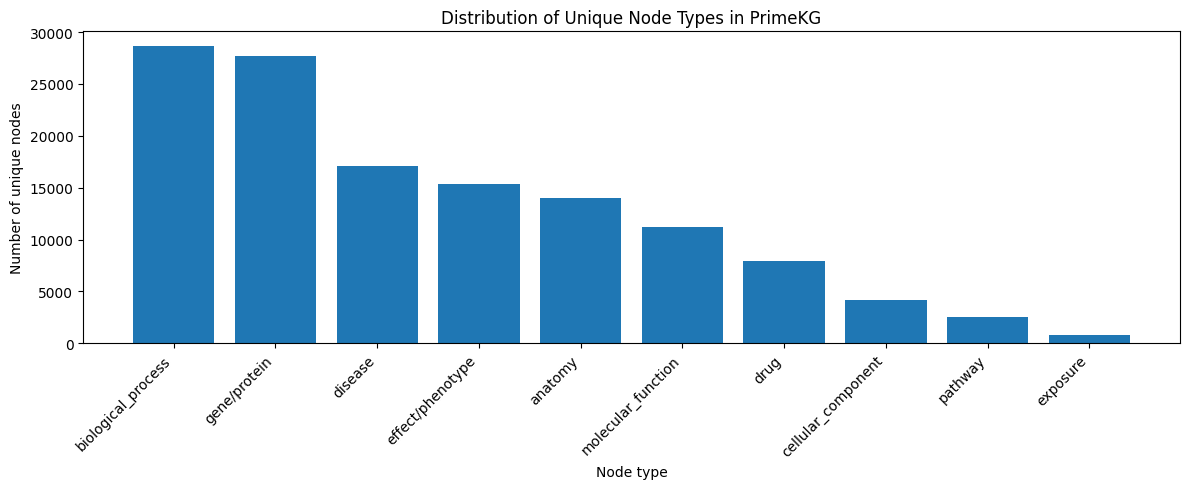

In [ ]:
# Node type distribution using unique nodes

node_type_counts = (
    nodes["node_type"]
    .value_counts()
    .reset_index()
)

node_type_counts.columns = ["node_type", "count"]
node_type_counts["percentage"] = 100 * node_type_counts["count"] / node_type_counts["count"].sum()

display(node_type_counts)

plt.figure(figsize=(12, 5))
plt.bar(node_type_counts["node_type"], node_type_counts["count"])
plt.title("Distribution of Unique Node Types in PrimeKG")
plt.xlabel("Node type")
plt.ylabel("Number of unique nodes")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

,display_relation,count,percentage
0,expression present,3036406,37.484189
1,synergistic interaction,2672628,32.993379
2,interacts with,686550,8.475405
3,ppi,642150,7.927290
4,phenotype present,300634,3.711303
5,parent-child,281744,3.478107
6,associated with,167482,2.067552
7,side effect,129568,1.599507
8,contraindication,61350,0.757361
9,expression absent,39774,0.491007


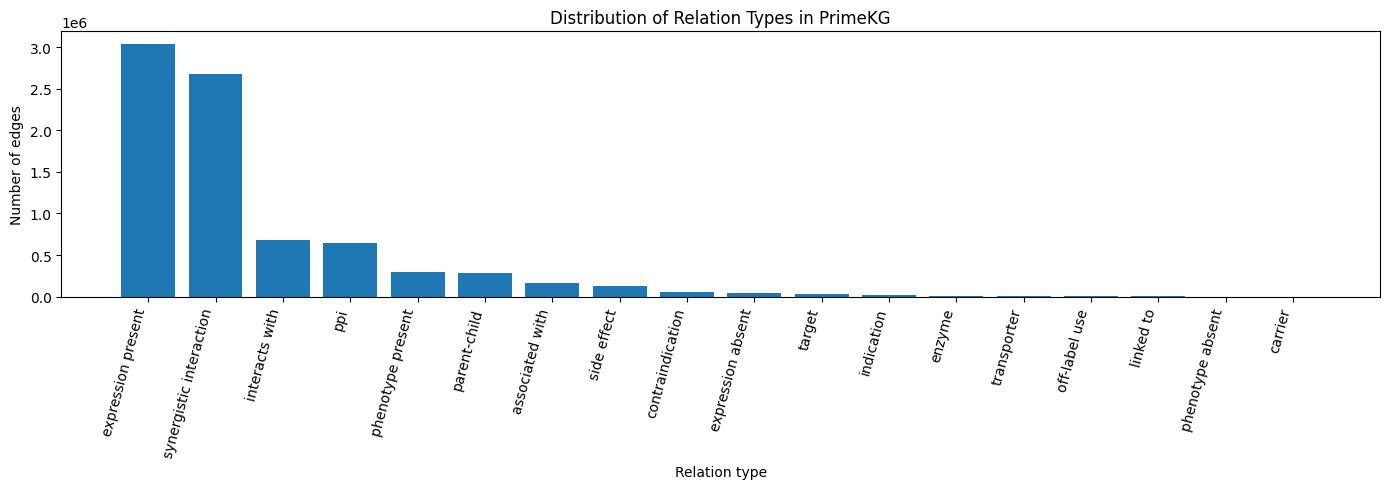

In [ ]:
#Relation distribution with percentages


relation_counts = (
    kg["display_relation"]
    .value_counts()
    .reset_index()
)

relation_counts.columns = ["display_relation", "count"]
relation_counts["percentage"] = 100 * relation_counts["count"] / relation_counts["count"].sum()

display(relation_counts)

plt.figure(figsize=(14, 5))
plt.bar(relation_counts["display_relation"], relation_counts["count"])
plt.title("Distribution of Relation Types in PrimeKG")
plt.xlabel("Relation type")
plt.ylabel("Number of edges")
plt.xticks(rotation=75, ha="right")
plt.tight_layout()
plt.show()

,type_pair,count,percentage
0,anatomy -- gene/protein,1538090,37.975196
1,drug -- drug,1336314,32.993379
2,gene/protein -- gene/protein,321075,7.927290
3,disease -- effect/phenotype,151510,3.740758
4,biological_process -- gene/protein,144805,3.575212
5,cellular_component -- gene/protein,83402,2.059182
6,disease -- gene/protein,80411,1.985335
7,gene/protein -- molecular_function,69530,1.716685
8,drug -- effect/phenotype,64784,1.599507
9,biological_process -- biological_process,52886,1.305747


Original directed edges: 8100498
Unique undirected edges: 4050249


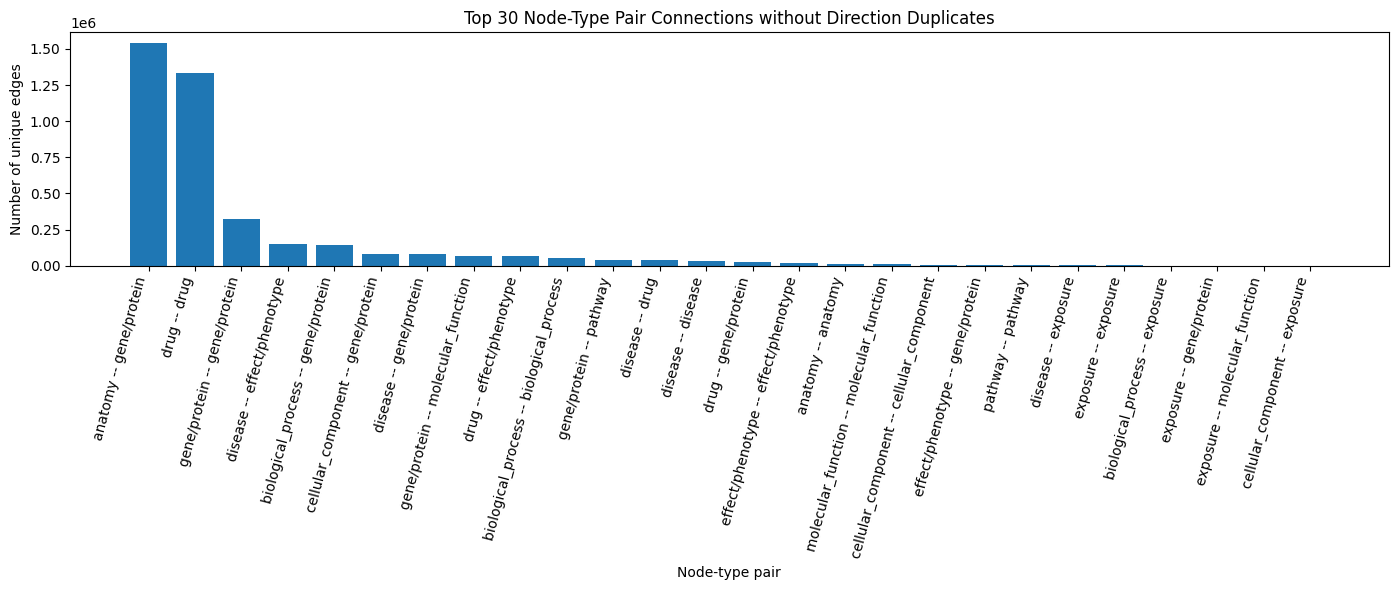

y_type,anatomy,biological_process,cellular_component,disease,drug,effect/phenotype,exposure,gene/protein,molecular_function,pathway
x_type,,,,,,,,,,
anatomy,28064,0,0,0,0,0,0,1538090,0,0
biological_process,0,105772,0,0,0,0,1625,144805,0,0
cellular_component,0,0,9690,0,0,0,10,83402,0,0
disease,0,0,0,64388,42631,151510,2304,80411,0,0
drug,0,0,0,42631,2672628,64784,0,25653,0,0
effect/phenotype,0,0,0,151510,64784,37472,0,3330,0,0
exposure,0,1625,10,2304,0,0,4140,1212,45,0
gene/protein,1538090,144805,83402,80411,25653,3330,1212,642150,69530,42646
molecular_function,0,0,0,0,0,0,45,69530,27148,0


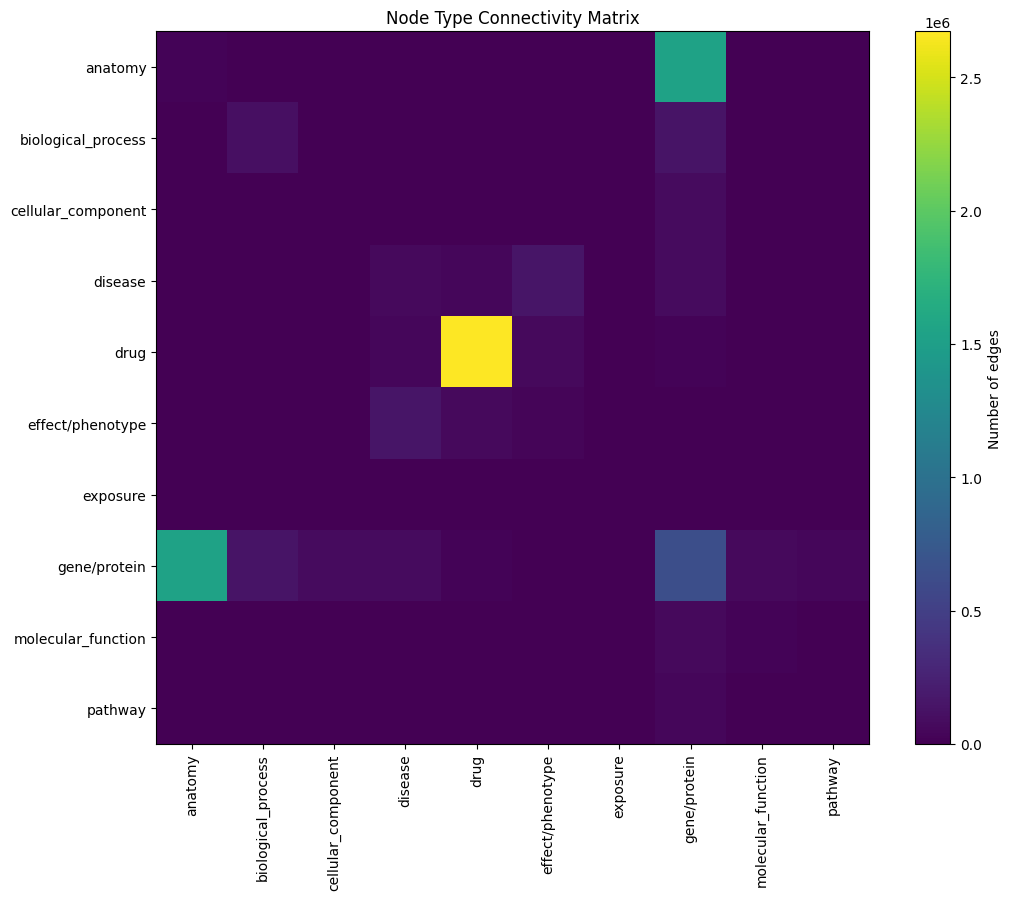

In [ ]:
import matplotlib.pyplot as plt

kg_undirected = kg.copy()
kg_undirected["node_u"] = kg_undirected[["x_index", "y_index"]].min(axis=1)
kg_undirected["node_v"] = kg_undirected[["x_index", "y_index"]].max(axis=1)

kg_undirected["type_u"] = kg_undirected[["x_type", "y_type"]].min(axis=1)
kg_undirected["type_v"] = kg_undirected[["x_type", "y_type"]].max(axis=1)
kg_undirected["type_pair"] = (kg_undirected["type_u"].astype(str) + " -- " + kg_undirected["type_v"].astype(str))

unique_edges_undirected = kg_undirected.drop_duplicates(subset=["node_u", "node_v", "display_relation"]).reset_index(drop=True)




type_pair_counts = (
    unique_edges_undirected["type_pair"]
    .value_counts()
    .reset_index()
)

type_pair_counts.columns = ["type_pair", "count"]
type_pair_counts["percentage"] = (
    100 * type_pair_counts["count"] / type_pair_counts["count"].sum()

)
display(type_pair_counts.head(40))
print("Original directed edges:", kg.shape[0])
print("Unique undirected edges:", unique_edges_undirected.shape[0])
plt.figure(figsize=(14, 6))
plt.bar(type_pair_counts["type_pair"].head(30),type_pair_counts["count"].head(30))

plt.title("Top 30 Node-Type Pair Connections without Direction Duplicates")
plt.xlabel("Node-type pair")
plt.ylabel("Number of unique edges")
plt.xticks(rotation=75, ha="right")
plt.tight_layout()
plt.show()


 #Type-to-type connectivity matrix

type_matrix = pd.crosstab(kg["x_type"], kg["y_type"])

display(type_matrix)

plt.figure(figsize=(11, 9))
plt.imshow(type_matrix.values)
plt.xticks(range(len(type_matrix.columns)), type_matrix.columns, rotation=90)
plt.yticks(range(len(type_matrix.index)), type_matrix.index)
plt.colorbar(label="Number of edges")
plt.title("Node Type Connectivity Matrix")
plt.tight_layout()
plt.show()

##Συμπέρασμα

Το βασικό συμπέρασμα είναι ότι το PrimeKG είναι ανισορροπημένος γράφος.
Δηλαδή λίγοι τύποι σχέσεων έχουν πάρα πολλές ακμές
ετσι πρέπει να επιλέξουμε συγκεκριμένα υποσύνολα σχέσεων (υπογραφους)

In [ ]:

# Degree (Undirected) analysis without double-counting directions


kg_undirected_degree = kg.copy()
kg_undirected_degree["node_u"] = kg_undirected_degree[["x_index", "y_index"]].min(axis=1)
kg_undirected_degree["node_v"] = kg_undirected_degree[["x_index", "y_index"]].max(axis=1)

unique_undirected_edges = kg_undirected_degree.drop_duplicates(
    subset=["node_u", "node_v", "display_relation"]
).copy()


u_degree = (
    unique_undirected_edges.groupby("node_u")
    .size()
    .reset_index(name="degree")
    .rename(columns={"node_u": "node_index"})
)


v_degree =(
    unique_undirected_edges.groupby("node_v")
    .size()
    .reset_index(name="degree")
    .rename(columns={"node_v": "node_index"})
)
undirected_degree_df =(
    pd.concat([u_degree, v_degree], ignore_index=True)
    .groupby("node_index", as_index=False)["degree"]
    .sum()
)
undirected_degree_df = undirected_degree_df.merge(
    nodes[["node_index", "node_name", "node_type"]],
    on="node_index",
    how="left"
)

print("Undirected degree table shape:", undirected_degree_df.shape)
print("Average undirected degree:", undirected_degree_df["degree"].mean())
print("Median undirected degree:", undirected_degree_df["degree"].median())
print("Max undirected degree:", undirected_degree_df["degree"].max())
print("Min undirected degree:", undirected_degree_df["degree"].min())

display(
    undirected_degree_df
    .sort_values("degree", ascending=False)
    .head(30)
)

Undirected degree table shape: (129375, 4)
Average undirected degree: 62.612544927536234
Median undirected degree: 4.0
Max undirected degree: 17355
Min undirected degree: 1


,node_index,degree,node_name,node_type
129373,129373,17355,multi-cellular organism,anatomy
64546,64546,16855,small intestine,anatomy
63376,63376,16743,testis,anatomy
66050,66050,16742,fallopian tube,anatomy
64796,64796,16619,prostate gland,anatomy
64544,64544,16600,spleen,anatomy
63223,63223,16542,intestine,anatomy
69442,69442,16513,dorsolateral prefrontal cortex,anatomy
63500,63500,16476,esophagus,anatomy
63423,63423,16473,stomach,anatomy


,node_type,count,mean,median,max,min
0,drug,7957,352.607264,13.0,2600,1
1,anatomy,14035,111.589170,1.0,17355,1
2,gene/protein,27671,95.089769,71.0,5580,1
3,cellular_component,4176,22.294540,2.0,5407,1
4,disease,17080,19.979157,6.0,1524,1
5,pathway,2516,18.965024,9.0,479,1
6,effect/phenotype,15311,16.791588,3.0,2399,1
7,exposure,818,11.413203,4.0,341,1
8,biological_process,28642,8.805321,4.0,1656,1
9,molecular_function,11169,8.659952,2.0,12546,1


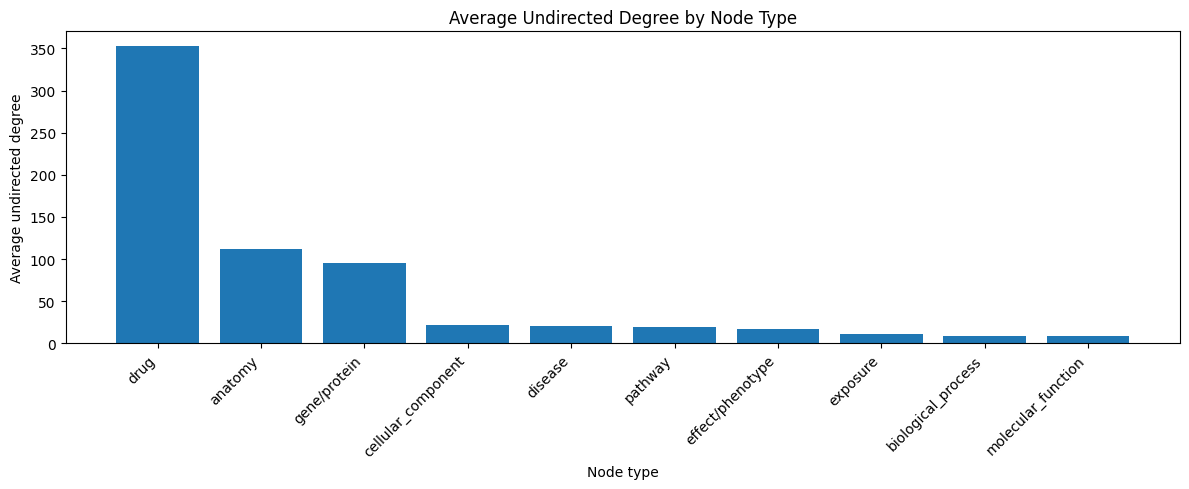

In [ ]:

# Degree (undirected) statistics by node type

import matplotlib.pyplot as plt

degree_stats_by_type = (
    undirected_degree_df
    .groupby("node_type")["degree"]
    .agg(["count", "mean", "median", "max", "min"])
    .sort_values("mean", ascending=False)
    .reset_index()
)

display(degree_stats_by_type)

plt.figure(figsize=(12, 5))
plt.bar(degree_stats_by_type["node_type"], degree_stats_by_type["mean"])
plt.title("Average Undirected Degree by Node Type")
plt.xlabel("Node type")
plt.ylabel("Average undirected degree")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Τα περισσότερα drugs έχουν λίγες συνδέσεις, λίγα drugs έχουν πάρα πολλές συνδέσεις (μεγάλο μέσο όρο με μικρή διάμεσο) και έτσι αυτά τα λίγα ανεβάζουν τον μέσο όρο.
Το παραπάνω ισχύει και για τα anatomy, cellular_component	κοκ.


In [ ]:
# Normalize drug-disease edges


drug_disease = kg[
    ((kg["x_type"] == "drug") & (kg["y_type"] == "disease")) |
    ((kg["x_type"] == "disease") & (kg["y_type"] == "drug"))
].copy()

def extract_drug(row):
    if row["x_type"] == "drug":
        return pd.Series([row["x_index"], row["x_name"], row["x_id"]])
    return pd.Series([row["y_index"], row["y_name"], row["y_id"]])

def extract_disease(row):
    if row["x_type"] == "disease":
        return pd.Series([row["x_index"], row["x_name"], row["x_id"]])
    return pd.Series([row["y_index"], row["y_name"], row["y_id"]])

drug_disease[["drug_index", "drug_name", "drug_id"]] = drug_disease.apply(extract_drug, axis=1)
drug_disease[["disease_index", "disease_name", "disease_id"]] = drug_disease.apply(extract_disease, axis=1)

print("Drug-disease edges:", drug_disease.shape[0])

dd_relation_counts = (
    drug_disease["display_relation"]
    .value_counts()
    .reset_index()
)

dd_relation_counts.columns = ["relation", "count"]
dd_relation_counts["percentage"] = 100 * dd_relation_counts["count"] / dd_relation_counts["count"].sum()

display(dd_relation_counts)
display(drug_disease.head())

Drug-disease edges: 85262


,relation,count,percentage
0,contraindication,61350,71.954681
1,indication,18776,22.021534
2,off-label use,5136,6.023786


,relation,display_relation,x_index,x_id,x_type,x_name,x_source,y_index,y_id,y_type,y_name,y_source,type_pair,drug_index,drug_name,drug_id,disease_index,disease_name,disease_id
346728,contraindication,contraindication,15193,DB05271,drug,Rotigotine,DrugBank,33577,5044,disease,hypertensive disorder,MONDO,drug - disease,15193,Rotigotine,DB05271,33577,hypertensive disorder,5044
346729,contraindication,contraindication,15193,DB05271,drug,Rotigotine,DrugBank,36035,1200_1134_15512_5080_100078,disease,hypertension,MONDO_grouped,drug - disease,15193,Rotigotine,DB05271,36035,hypertension,1200_1134_15512_5080_100078
346730,indication,indication,16687,DB00492,drug,Fosinopril,DrugBank,33577,5044,disease,hypertensive disorder,MONDO,drug - disease,16687,Fosinopril,DB00492,33577,hypertensive disorder,5044
346731,indication,indication,16687,DB00492,drug,Fosinopril,DrugBank,36035,1200_1134_15512_5080_100078,disease,hypertension,MONDO_grouped,drug - disease,16687,Fosinopril,DB00492,36035,hypertension,1200_1134_15512_5080_100078
346732,contraindication,contraindication,14483,DB13956,drug,Estradiol valerate,DrugBank,33577,5044,disease,hypertensive disorder,MONDO,drug - disease,14483,Estradiol valerate,DB13956,33577,hypertensive disorder,5044


In [ ]:
#Drug-disease coverage




all_drugs = nodes[nodes["node_type"] == "drug"].copy()
all_diseases = nodes[nodes["node_type"] == "disease"].copy()

diseases_with_any_drug_relation = set(drug_disease["disease_index"])
drugs_with_any_disease_relation = set(drug_disease["drug_index"])

print("Total drugs:", all_drugs.shape[0])
print("Drugs with at least one drug-disease relation:", len(drugs_with_any_disease_relation))
print("Drugs without drug-disease relation:", all_drugs.shape[0] - len(drugs_with_any_disease_relation))

print("\nTotal diseases:", all_diseases.shape[0])
print("Diseases with at least one drug-disease relation:", len(diseases_with_any_drug_relation))
print("Diseases without drug-disease relation:", all_diseases.shape[0] - len(diseases_with_any_drug_relation))

Total drugs: 7957
Drugs with at least one drug-disease relation: 2074
Drugs without drug-disease relation: 5883

Total diseases: 17080
Diseases with at least one drug-disease relation: 2054
Diseases without drug-disease relation: 15026


##Το 2.074 / 7.957 = 26% drugs έχουν τουλάχιστον μία άμεση σχέση με disease

##Τα υπόλοιπα περίπου 74% των drugs δεν έχουν άμεση drug–disease σχέση

##Το 2.054 / 17.080 = 12% diseases έχουν τουλάχιστον μία άμεση σχέση με drug.

##Τα υπόλοιπα περίπου 88% των diseases δεν έχουν άμεση drug–disease σχέση.

Άρα ο γράφος έχει πολλές οντότητες που μπορεί να συνδέονται έμμεσα μέσω άλλων κόμβων, όπως proteins ή pathways, αλλά δεν έχουν άμεση drug–disease ακμή.

In [ ]:
#Indication/ contraindication coverage



indication_edges = drug_disease[drug_disease["display_relation"] == "indication"].copy()
contra_edges = drug_disease[drug_disease["display_relation"] == "contraindication"].copy()
offlabel_edges = drug_disease[drug_disease["display_relation"] == "off-label use"].copy()

diseases_with_indication = set(indication_edges["disease_index"])
diseases_with_contra = set(contra_edges["disease_index"])
diseases_with_offlabel = set(offlabel_edges["disease_index"])

print("Indication edges:", indication_edges.shape[0])
print("Contraindication edges:", contra_edges.shape[0])
print("Off-label use edges:", offlabel_edges.shape[0])

print("\nDiseases with indication:", len(diseases_with_indication))
print("Diseases without indication:", all_diseases.shape[0] - len(diseases_with_indication))

print("\nDiseases with contraindication:", len(diseases_with_contra))
print("Diseases with off-label use:", len(diseases_with_offlabel))

Indication edges: 18776
Contraindication edges: 61350
Off-label use edges: 5136

Diseases with indication: 1363
Diseases without indication: 15717

Diseases with contraindication: 1195
Diseases with off-label use: 750


Το 1.363 / 17.080 ≈ 8% απο τις ασθένειες έχει τουλάχιστον μία γνωστή θεραπευτική ένδειξη με κάποιο φάρμακο.

Αντίστοιχα, 1.195 ασθένειες έχουν τουλάχιστον μία contraindication σχέση και 750 ασθένειες έχουν τουλάχιστον μία off-label use σχέση.


Το αποτέλεσμα αυτό δείχνει ότι οι άμεσες drug–disease therapeutic σχέσεις καλύπτουν μικρό μέρος των διαθέσιμων disease κόμβων. Επομένως, η χρήση τεχνικών link prediction είναι ιδιαίτερα σχετική, καθώς μπορεί να αξιοποιήσει τη δομή του γράφου και τις έμμεσες σχέσεις μέσω gene/protein και pathway κόμβων για την πρόβλεψη πιθανών νέων drug–disease συσχετίσεων. Επιπλέον, η ύπαρξη μεγάλου αριθμού contraindication σχέσεων επιτρέπει τη χρήση τους ως πιο ρεαλιστικών αρνητικών παραδειγμάτων κατά την εκπαίδευση ή αξιολόγηση του μοντέλου.

Top diseases by number of related drugs:


,disease_index,disease_name,num_drugs
783,35565,liver disease,654
882,35961,gallbladder disease,654
829,35764,kidney disease,582
1481,83762,pyoureter,582
682,33577,hypertensive disorder,412
908,36035,hypertension,412
680,33575,diabetes mellitus (disease),396
207,29113,diabetic ketoacidosis,353
799,35641,epilepsy,335
1414,39531,liver failure,273


Top drugs by number of related diseases:


,drug_index,drug_name,num_diseases
653,15003,Cortisone acetate,277
13,14030,Prednisolone,265
224,14320,Dexamethasone,257
4,14019,Betamethasone,245
7,14023,Triamcinolone,239
11,14028,Hydrocortisone,234
174,14269,Methylprednisolone,218
1723,20303,Trolnitrate,212
8,14024,Prednisone,203
20,14042,Hydrocortisone acetate,187


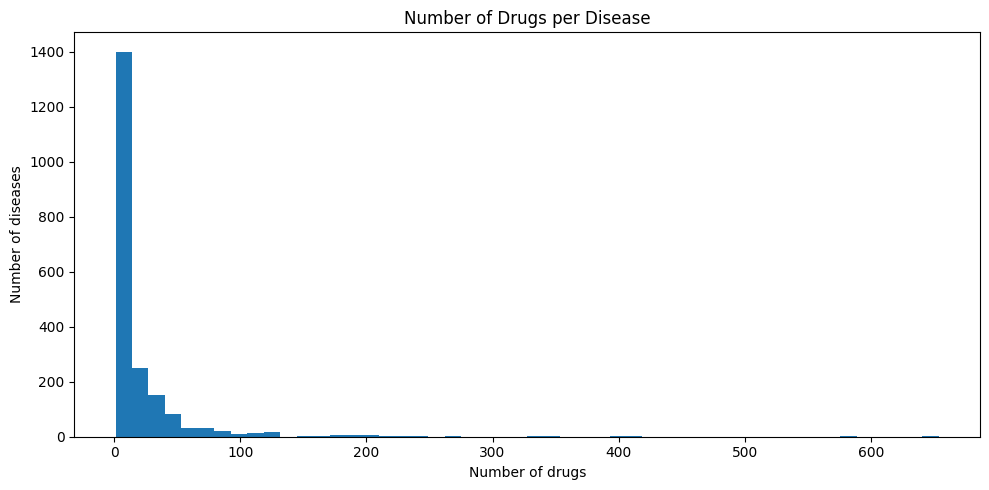

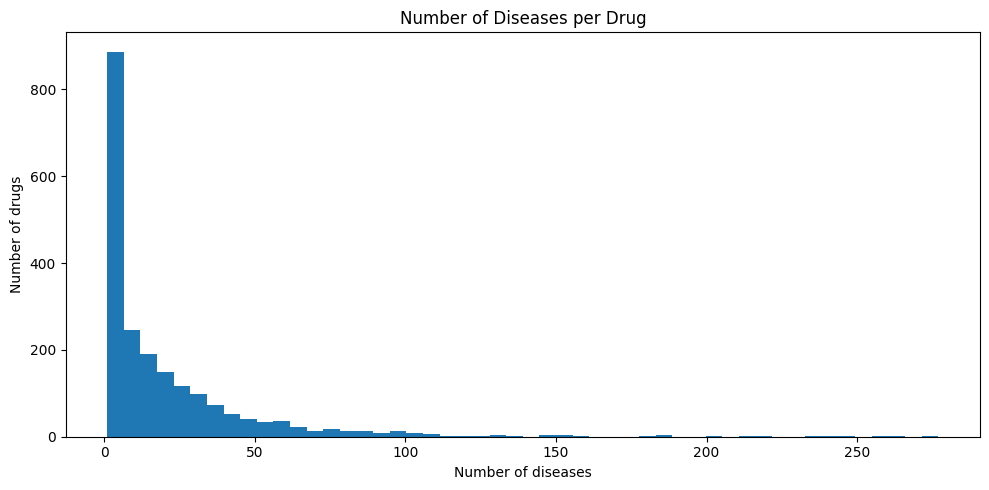

In [ ]:
#Drugs per disease and diseases per drug

drugs_per_disease = (
    drug_disease
    .groupby(["disease_index", "disease_name"])["drug_index"]
    .nunique()
    .reset_index()
    .rename(columns={"drug_index": "num_drugs"})
    .sort_values("num_drugs", ascending=False)
)

diseases_per_drug = (
    drug_disease
    .groupby(["drug_index", "drug_name"])["disease_index"]
    .nunique()
    .reset_index()
    .rename(columns={"disease_index": "num_diseases"})
    .sort_values("num_diseases", ascending=False)
)

print("Top diseases by number of related drugs:")
display(drugs_per_disease.head(20))

print("Top drugs by number of related diseases:")
display(diseases_per_drug.head(20))

plt.figure(figsize=(10, 5))
plt.hist(drugs_per_disease["num_drugs"], bins=50)
plt.title("Number of Drugs per Disease")
plt.xlabel("Number of drugs")
plt.ylabel("Number of diseases")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.hist(diseases_per_drug["num_diseases"], bins=50)
plt.title("Number of Diseases per Drug")
plt.xlabel("Number of diseases")
plt.ylabel("Number of drugs")
plt.tight_layout()
plt.show()

Η ανάλυση του αριθμού φαρμάκων ανά ασθένεια και του αριθμού ασθενειών ανά φάρμακο δείχνει ότι οι drug–disease σχέσεις δεν κατανέμονται ομοιόμορφα.

 Οι περισσότερες ασθένειες συνδέονται με μικρό αριθμό φαρμάκων, ενώ λίγες ασθένειες εμφανίζουν πολύ μεγάλο αριθμό σχετιζόμενων drugs. Αντίστοιχα, τα περισσότερα φάρμακα συνδέονται με μικρό αριθμό ασθενειών, ενώ λίγα φάρμακα συνδέονται με πολλές ασθένειες.

Το αποτέλεσμα αυτό δείχνει ότι το drug–disease υπογράφημα έχει long-tail κατανομή και περιλαμβάνει κόμβους με πολύ διαφορετική συνδεσιμότητα. Αυτό είναι σημαντικό για το link prediction, καθώς οι πολύ συνδεδεμένοι κόμβοι μπορεί να επηρεάζουν περισσότερο την εκπαίδευση του μοντέλου, ενώ οι λιγότερο συνδεδεμένοι κόμβοι αποτελούν πιο δύσκολες περιπτώσεις πρόβλεψης που πιθανώς αυτές να έχουν σημαντικά αποτελέσματα

In [ ]:
#Drug-gene/protein and disease-gene/protein relations


drug_protein = kg[
    ((kg["x_type"] == "drug") & (kg["y_type"] == "gene/protein")) |
    ((kg["x_type"] == "gene/protein") & (kg["y_type"] == "drug"))
].copy()

disease_protein = kg[
    ((kg["x_type"] == "disease") & (kg["y_type"] == "gene/protein")) |
    ((kg["x_type"] == "gene/protein") & (kg["y_type"] == "disease"))
].copy()

print("Drug-gene/protein edges:", drug_protein.shape[0])
display(drug_protein["display_relation"].value_counts())

print("\nDisease-gene/protein edges:", disease_protein.shape[0])
display(disease_protein["display_relation"].value_counts())

Drug-gene/protein edges: 51306


,count
display_relation,
target,32760
enzyme,10634
transporter,6184
carrier,1728



Disease-gene/protein edges: 160822


,count
display_relation,
associated with,160822


Η ανάλυση των drug–gene/protein και disease–gene/protein σχέσεων δείχνει ότι το PrimeKG περιέχει σημαντικό αριθμό σχέσεων που μπορούν να λειτουργήσουν ως ενδιάμεση πληροφορία μεταξύ φαρμάκων και ασθενειών. Συγκεκριμένα, εντοπίστηκαν 51.306 drug–gene/protein σχέσεις, οι οποίες περιλαμβάνουν σχέσεις target, enzyme, transporter και carrier. Από αυτές, οι σχέσεις target είναι ιδιαίτερα σημαντικές, καθώς περιγράφουν τις πρωτεΐνες ή τα γονίδια στα οποία δρα ένα φάρμακο.

Παράλληλα, εντοπίστηκαν 160.822 disease–gene/protein σχέσεις τύπου associated with, οι οποίες συνδέουν ασθένειες με γονίδια ή πρωτεΐνες. Ο συνδυασμός αυτών των δύο κατηγοριών σχέσεων επιτρέπει τη μελέτη έμμεσων διαδρομών τύπου Drug- Protein-Disease. Το αποτέλεσμα αυτό στηρίζει τη βασική κατεύθυνση της πτυχιακής, δηλαδή τη διερεύνηση του κατά πόσο οι έμμεσες σχέσεις μέσω gene/protein κόμβων μπορούν να βοηθήσουν στην πρόβλεψη πιθανών νέων drug–disease συσχετίσεων.

,drug_index,drug_name,disease_index,disease_name,relation,num_shared_gene_protein
76973,14540,Amoxapine,28313,schizophrenia,contraindication,32
76977,14323,Aripiprazole,28313,schizophrenia,indication,32
34342,14540,Amoxapine,28313,schizophrenia,contraindication,32
34346,14323,Aripiprazole,28313,schizophrenia,indication,32
15330,14540,Amoxapine,30035,substance abuse/dependence,contraindication,28
57961,14540,Amoxapine,30035,substance abuse/dependence,contraindication,28
76971,14140,Ziprasidone,28313,schizophrenia,indication,25
34345,14161,Olanzapine,28313,schizophrenia,indication,25
34340,14140,Ziprasidone,28313,schizophrenia,indication,25
76976,14161,Olanzapine,28313,schizophrenia,indication,25


Average shared gene/protein: 0.3430602143979733
Median shared gene/protein: 0.0
Pairs with at least one shared gene/protein: 13402


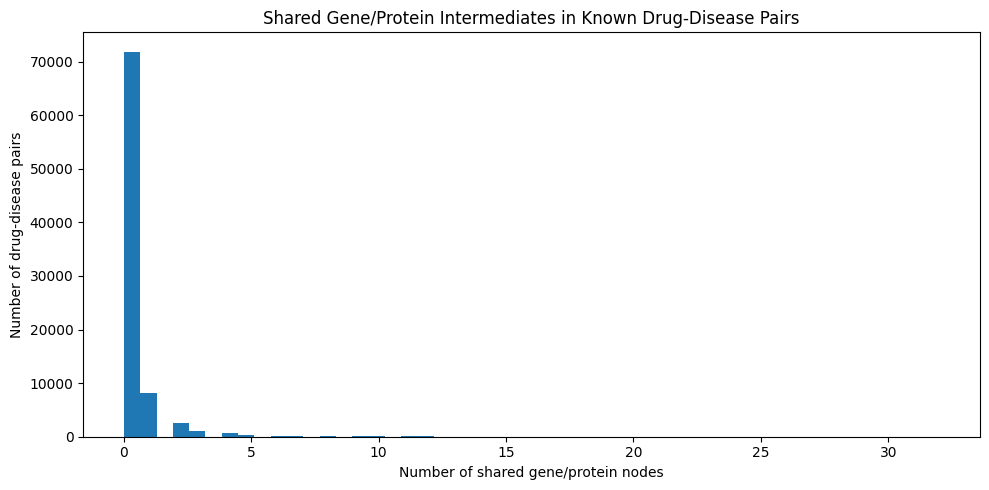

In [ ]:
# sos
#Shared gene/protein intermediates in known drug-disease pairs

from collections import defaultdict

drug_to_protein = defaultdict(set)
disease_to_protein = defaultdict(set)

for _, row in drug_protein.iterrows():
    if row["x_type"] == "drug":
        drug_to_protein[row["x_index"]].add(row["y_index"])
    else:
        drug_to_protein[row["y_index"]].add(row["x_index"])

for _, row in disease_protein.iterrows():
    if row["x_type"] == "disease":
        disease_to_protein[row["x_index"]].add(row["y_index"])
    else:
        disease_to_protein[row["y_index"]].add(row["x_index"])

shared_rows = []

for _, row in drug_disease.iterrows():
    drug = row["drug_index"]
    disease = row["disease_index"]

    shared = drug_to_protein[drug].intersection(disease_to_protein[disease])

    shared_rows.append({
        "drug_index": drug,
        "drug_name": row["drug_name"],
        "disease_index": disease,
        "disease_name": row["disease_name"],
        "relation": row["display_relation"],
        "num_shared_gene_protein": len(shared)
    })

shared_gene_protein_df = pd.DataFrame(shared_rows)

display(shared_gene_protein_df.sort_values("num_shared_gene_protein", ascending=False).head(30))

print("Average shared gene/protein:", shared_gene_protein_df["num_shared_gene_protein"].mean())
print("Median shared gene/protein:", shared_gene_protein_df["num_shared_gene_protein"].median())
print("Pairs with at least one shared gene/protein:",
      (shared_gene_protein_df["num_shared_gene_protein"] > 0).sum())

plt.figure(figsize=(10, 5))
plt.hist(shared_gene_protein_df["num_shared_gene_protein"], bins=50)
plt.title("Shared Gene/Protein Intermediates in Known Drug-Disease Pairs")
plt.xlabel("Number of shared gene/protein nodes")
plt.ylabel("Number of drug-disease pairs")
plt.tight_layout()
plt.show()


Η ανάλυση των κοινών gene/protein ενδιάμεσων κόμβων δείχνει ότι ένα μέρος των γνωστών drug–disease σχέσεων μπορεί να υποστηριχθεί από απλές έμμεσες διαδρομές τύπου Drug - Gene/Protein - Disease. Συγκεκριμένα, εντοπίστηκαν αρκετά γνωστά pairs με έναν ή περισσότερους κοινούς gene/protein κόμβους, ιδιαίτερα σε περιπτώσεις νευροψυχιατρικών ασθενειών και σχετικών φαρμάκων.

Ωστόσο, η διάμεσος του αριθμού κοινών gene/protein κόμβων είναι 0, γεγονός που δείχνει ότι οι περισσότερες γνωστές drug–disease σχέσεις δεν εξηγούνται από ένα απλό μονοπάτι μέσω της ίδιας πρωτεΐνης. Επομένως, η απλή διαδρομή Drug - Protein - Disease είναι χρήσιμη αλλά ανεπαρκής από μόνη της. Το αποτέλεσμα αυτό υποστηρίζει την ανάγκη μελέτης πιο σύνθετων έμμεσων μονοπατιών, όπως Drug -Protein- Protein - Disease μέσω ppi σχέσεων ή Drug - Protein - Pathway -Protein -Disease μέσω pathway κόμβων.


##Με βάση τα παραπάνω θα εστιάσουμε στην μελέτη μέσω του pathway

In [ ]:
# Pathway-related analysis

pathway_edges = kg[
    (kg["x_type"].str.contains("pathway", case=False, na=False)) |
    (kg["y_type"].str.contains("pathway", case=False, na=False))
].copy()

print("Pathway-related edges:", pathway_edges.shape[0])

print("\nRelation types:")
display(pathway_edges["display_relation"].value_counts())

print("\nx_type distribution:")
display(pathway_edges["x_type"].value_counts())


Pathway-related edges: 90362

Relation types:


,count
display_relation,
interacts with,85292
parent-child,5070



x_type distribution:


,count
x_type,
pathway,47716
gene/protein,42646


Το παραπάνω δείχνει ότι στο PrimeKG υπάρχουν 90.362 ακμές στις οποίες συμμετέχει ένα pathway. Οι περισσότερες από αυτές είναι σχέσεις τύπου “interacts with” μεταξύ gene/protein και pathway κόμβων, ενώ ένα μικρο μέρος είναι σχέσεις μεταξύ pathway.

Το αποτέλεσμα δείχνει ότι τα pathways δεν συνδέονται άμεσα με drug ή disease κόμβους αλλά κυρίως με gene/protein κόμβους.

 Επομένως, η pathway πληροφορία μπορεί να χρησιμοποιηθεί για τη μελέτη πιο σύνθετων έμμεσων διαδρομών

 # Pathway analysis

Στη βιολογία, ένα pathway είναι μια οργανωμένη ακολουθία μοριακών βημάτων ή αντιδράσεων, μέσω των οποίων εκτελείται μια βιολογική λειτουργία, όπως μεταβολισμός, σηματοδότηση, ανοσολογική απόκριση ή κυτταρική ρύθμιση.

Στο πλαίσιο του PrimeKG, τα pathways είναι χρήσιμα επειδή μπορούν να λειτουργήσουν ως ενδιάμεσο επίπεδο ερμηνείας ανάμεσα σε φάρμακα και ασθένειες.  
Για παράδειγμα:

Drug - Gene/Protein - Pathway - Gene/Protein - Disease

Αν ένα φάρμακο και μια ασθένεια συνδέονται με το ίδιο pathway, τότε υπάρχει πιθανή βιολογική σύνδεση που μπορεί να αξιοποιηθεί είτε για link prediction είτε για explainability.



In [ ]:
#Identify pathway nodes and pathway-related edges




pathway_nodes = nodes[
    nodes["node_type"].astype(str).str.contains("pathway", case=False, na=False)
].copy()

pathway_edges = kg[
    kg["x_type"].astype(str).str.contains("pathway", case=False, na=False) |
    kg["y_type"].astype(str).str.contains("pathway", case=False, na=False)
].copy()

print("Unique pathway nodes:", pathway_nodes.shape[0])
print("Pathway-related edges:", pathway_edges.shape[0])

print("\nPathway node types:")
display(pathway_nodes["node_type"].value_counts().reset_index().rename(
    columns={"index": "node_type", "node_type": "count"}
))

print("\nPathway-related relation types:")
display(pathway_edges["display_relation"].value_counts().reset_index().rename(
    columns={"index": "relation", "display_relation": "count"}
))

print("\nPathway type-pairs:")
pathway_edges["pathway_type_pair"] = pathway_edges["x_type"].astype(str) + " -> " + pathway_edges["y_type"].astype(str)
display(pathway_edges["pathway_type_pair"].value_counts().reset_index().rename(
    columns={"index": "type_pair", "pathway_type_pair": "count"}
).head(30))

Unique pathway nodes: 2516
Pathway-related edges: 90362

Pathway node types:


,count,count
0,pathway,2516



Pathway-related relation types:


,count,count
0,interacts with,85292
1,parent-child,5070



Pathway type-pairs:


,count,count
0,gene/protein -> pathway,42646
1,pathway -> gene/protein,42646
2,pathway -> pathway,5070


,node_index,degree,node_name,node_type
127886,127886,479,Neutrophil degranulation,pathway
129352,129352,394,Olfactory Signaling Pathway,pathway
62504,62504,360,Generic Transcription Pathway,pathway
129365,129365,310,Antigen processing: Ubiquitination & Proteasom...,pathway
62702,62702,261,G alpha (i) signalling events,pathway
128799,128799,235,Neddylation,pathway
128781,128781,221,Ub-specific processing proteases,pathway
128867,128867,192,Separation of Sister Chromatids,pathway
129140,129140,186,RAC1 GTPase cycle,pathway
129034,129034,185,Major pathway of rRNA processing in the nucleo...,pathway


/tmp/ipykernel_1669/1012987836.py:21: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


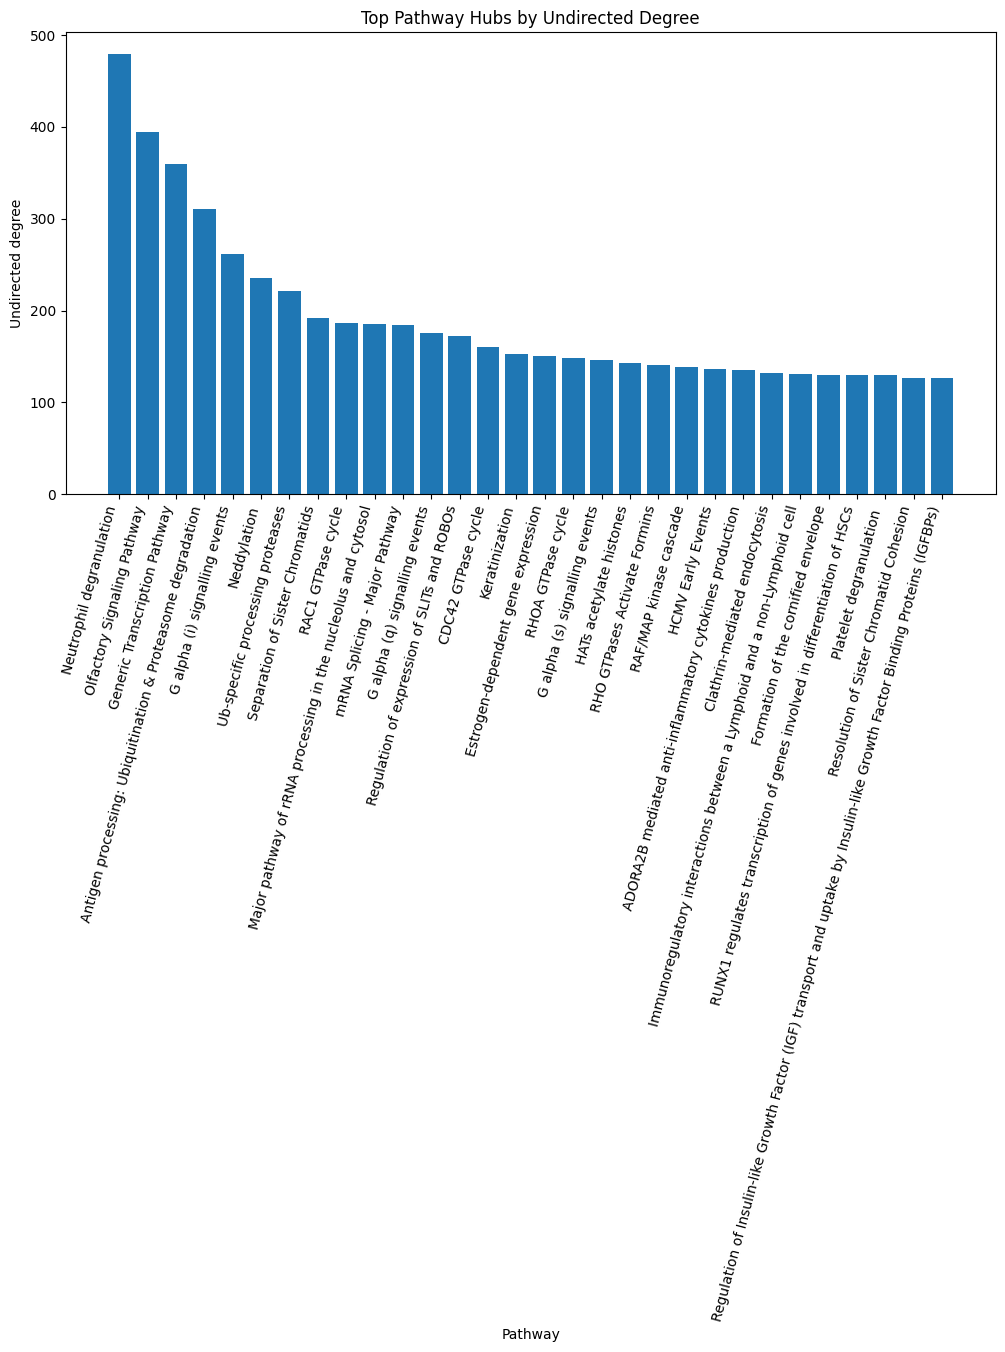

In [ ]:
#Top pathway hubs degree

import matplotlib.pyplot as plt

top_pathways = (
    undirected_degree_df[
        undirected_degree_df["node_type"].astype(str).str.contains("pathway", case=False, na=False)
    ]
    .sort_values("degree", ascending=False)
    .head(30)
)

display(top_pathways)

plt.figure(figsize=(12, 6))
plt.bar(top_pathways["node_name"].astype(str), top_pathways["degree"])
plt.title("Top Pathway Hubs by Undirected Degree")
plt.xlabel("Pathway")
plt.ylabel("Undirected degree")
plt.xticks(rotation=75, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
from collections import defaultdict
import pandas as pd

gene_protein_pathway = kg[
    (
        (kg["x_type"] == "gene/protein") &
        (kg["y_type"].str.contains("pathway", case=False, na=False))
    ) |
    (
        (kg["y_type"] == "gene/protein") &
        (kg["x_type"].str.contains("pathway", case=False, na=False))
    )
].copy()

gp_pathway_rows = []

for _, row in gene_protein_pathway.iterrows():
    if row["x_type"] == "gene/protein":
        gp_pathway_rows.append({
            "gene_protein_index": row["x_index"],
            "gene_protein_name": row["x_name"],
            "pathway_index": row["y_index"],
            "pathway_name": row["y_name"],
            "relation": row["display_relation"]
        })
    else:
        gp_pathway_rows.append({
            "gene_protein_index": row["y_index"],
            "gene_protein_name": row["y_name"],
            "pathway_index": row["x_index"],
            "pathway_name": row["x_name"],
            "relation": row["display_relation"]
        })

gp_pathway_df = pd.DataFrame(gp_pathway_rows)

# Remove duplicate gene/protein-pathway-relation rows
gp_pathway_unique = gp_pathway_df.drop_duplicates(
    subset=["gene_protein_index", "pathway_index", "relation"]
).copy()

# Build dictionary: gene/protein -> set(pathways)
gp_to_pathways = defaultdict(set)

for _, row in gp_pathway_unique.iterrows():
    gp_to_pathways[row["gene_protein_index"]].add(row["pathway_index"])

print("Raw gene/protein-pathway rows:", gene_protein_pathway.shape[0])
print("Unique gene/protein-pathway edges:", gp_pathway_unique.shape[0])
print("Gene/protein nodes with pathway connections:", len(gp_to_pathways))
print("Unique pathway nodes connected to gene/protein:", gp_pathway_unique["pathway_index"].nunique())

Raw gene/protein-pathway rows: 85292
Unique gene/protein-pathway edges: 42646
Gene/protein nodes with pathway connections: 10849
Unique pathway nodes connected to gene/protein: 2020


In [ ]:
# Build drug - pathway and disease -> pathway mappings

drug_to_gp = defaultdict(set)
disease_to_gp = defaultdict(set)

# Drug-gene/protein
drug_protein = kg[
    ((kg["x_type"] == "drug") & (kg["y_type"] == "gene/protein")) |
    ((kg["x_type"] == "gene/protein") & (kg["y_type"] == "drug"))
].copy()

for _, row in drug_protein.iterrows():
    if row["x_type"] == "drug":
        drug_to_gp[row["x_index"]].add(row["y_index"])
    else:
        drug_to_gp[row["y_index"]].add(row["x_index"])

# Disease-gene/protein
disease_protein = kg[
    ((kg["x_type"] == "disease") & (kg["y_type"] == "gene/protein")) |
    ((kg["x_type"] == "gene/protein") & (kg["y_type"] == "disease"))
].copy()

for _, row in disease_protein.iterrows():
    if row["x_type"] == "disease":
        disease_to_gp[row["x_index"]].add(row["y_index"])
    else:
        disease_to_gp[row["y_index"]].add(row["x_index"])

def expand_to_pathways(gp_set):
    pathways = set()
    for gp in gp_set:
        pathways.update(gp_to_pathways.get(gp, set()))
    return pathways

drug_to_pathways = {
    drug: expand_to_pathways(gps)
    for drug, gps in drug_to_gp.items()
}

disease_to_pathways = {
    disease: expand_to_pathways(gps)
    for disease, gps in disease_to_gp.items()
}

print("Drugs with gene/protein connections:", len(drug_to_gp))
print("Drugs with pathway connections through gene/protein:", sum(len(v) > 0 for v in drug_to_pathways.values()))

print("Diseases with gene/protein connections:", len(disease_to_gp))
print("Diseases with pathway connections through gene/protein:", sum(len(v) > 0 for v in disease_to_pathways.values()))

Drugs with gene/protein connections: 6282
Drugs with pathway connections through gene/protein: 6131
Diseases with gene/protein connections: 5593
Diseases with pathway connections through gene/protein: 5113


##Εμφαση  pathways σε έμμεσες σχέσεις

Η ανάλυση των έμμεσων συνδέσεων προς pathways μέσω gene/protein κόμβων δείχνει ότι 6.282 drugs έχουν τουλάχιστον μία drug–gene/protein σύνδεση, ενώ 6.131 από αυτά μπορούν να συνδεθούν με τουλάχιστον ένα pathway μέσω των αντίστοιχων gene/protein κόμβων. Αυτό αντιστοιχεί περίπου στο 97,6% των drugs με gene/protein πληροφορία.

Αντίστοιχα, 5.593 diseases έχουν τουλάχιστον μία disease–gene/protein σύνδεση, ενώ 5.113 από αυτές μπορούν να συνδεθούν με τουλάχιστον ένα pathway μέσω gene/protein κόμβων, ποσοστό περίπου 91,4%.

Τα αποτελέσματα αυτά δείχνουν ότι η pathway πληροφορία καλύπτει μεγάλο μέρος των drugs και diseases που έχουν gene/protein συνδέσεις. Επομένως, τα pathways μπορούν να χρησιμοποιηθούν ως πρόσθετο ενδιάμεσο επίπεδο πληροφορίας για τη μελέτη πιο σύνθετων έμμεσων διαδρομών, όπως Drug - Protein - Pathway -Protein- Disease.

In [ ]:
# Top drugs and diseases by number of connected pathways

node_names = nodes.set_index("node_index")["node_name"].to_dict()

drug_pathway_counts = pd.DataFrame([
    {
        "drug_index": drug,
        "drug_name": node_names.get(drug, drug),
        "num_pathways": len(pathways)
    }
    for drug, pathways in drug_to_pathways.items()
]).sort_values("num_pathways", ascending=False)

disease_pathway_counts = pd.DataFrame([
    {
        "disease_index": disease,
        "disease_name": node_names.get(disease, disease),
        "num_pathways": len(pathways)
    }
    for disease, pathways in disease_to_pathways.items()
]).sort_values("num_pathways", ascending=False)

print("Top drugs by connected pathways:")
display(drug_pathway_counts.head(30))

print("Top diseases by connected pathways:")
display(disease_pathway_counts.head(30))

Top drugs by connected pathways:


,drug_index,drug_name,num_pathways
1662,15674,Fostamatinib,686
0,14012,Copper,449
668,14680,Zinc acetate,270
667,14679,Zinc,267
478,14490,Zinc chloride,259
479,14491,"Zinc sulfate, unspecified form",259
1769,15781,Acetylsalicylic acid,225
1018,15030,Ponatinib,222
1230,15242,Artenimol,218
4393,18405,Guanosine-5'-Diphosphate,216


Top diseases by connected pathways:


,disease_index,disease_name,num_pathways
44,32617,hereditary breast ovarian cancer syndrome,1290
42,28347,hereditary breast carcinoma,1251
43,35771,breast neoplasm,1244
46,84244,undifferentiated carcinoma of the corpus uteri,1244
45,84243,squamous cell carcinoma of the corpus uteri,1244
41,36691,breast cancer,1244
0,28313,schizophrenia,1156
7,28849,colorectal cancer,1131
39,30826,familial prostate carcinoma,1112
20,31116,lung cancer,1107


,drug_index,drug_name,disease_index,disease_name,relation,num_drug_pathways,num_disease_pathways,num_shared_pathways
21374,14413,Nintedanib,31116,lung cancer,indication,194,1107,150
64005,14413,Nintedanib,31116,lung cancer,indication,194,1107,150
26820,15599,Regorafenib,29646,hepatocellular carcinoma,indication,143,1026,109
69451,15599,Regorafenib,29646,hepatocellular carcinoma,indication,143,1026,109
26821,15599,Regorafenib,36634,liver cancer,indication,143,1014,109
64004,14413,Nintedanib,33688,non-small cell lung carcinoma (disease),indication,194,602,109
21373,14413,Nintedanib,33688,non-small cell lung carcinoma (disease),indication,194,602,109
69452,15599,Regorafenib,36634,liver cancer,indication,143,1014,109
57872,14783,Caffeine,30035,substance abuse/dependence,contraindication,126,858,108
15241,14783,Caffeine,30035,substance abuse/dependence,contraindication,126,858,108


Average shared pathways: 3.7442236869883416
Median shared pathways: 0.0
Pairs with at least one shared pathway: 40278


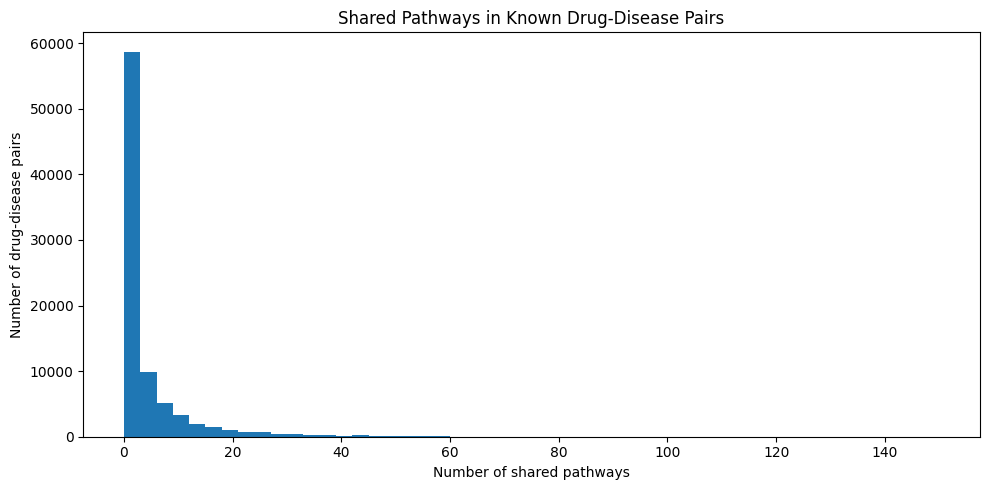

In [ ]:
# Shared pathways for known drug-disease pai

if "drug_disease" not in globals():
    drug_disease = kg[
        ((kg["x_type"] == "drug") & (kg["y_type"] == "disease")) |
        ((kg["x_type"] == "disease") & (kg["y_type"] == "drug"))
    ].copy()

    def extract_drug(row):
        if row["x_type"] == "drug":
            return pd.Series([row["x_index"], row["x_name"], row["x_id"]])
        return pd.Series([row["y_index"], row["y_name"], row["y_id"]])

    def extract_disease(row):
        if row["x_type"] == "disease":
            return pd.Series([row["x_index"], row["x_name"], row["x_id"]])
        return pd.Series([row["y_index"], row["y_name"], row["y_id"]])

    drug_disease[["drug_index", "drug_name", "drug_id"]] = drug_disease.apply(extract_drug, axis=1)
    drug_disease[["disease_index", "disease_name", "disease_id"]] = drug_disease.apply(extract_disease, axis=1)

shared_pathway_rows = []

for _, row in drug_disease.iterrows():
    drug = row["drug_index"]
    disease = row["disease_index"]

    drug_paths = drug_to_pathways.get(drug, set())
    disease_paths = disease_to_pathways.get(disease, set())

    shared = drug_paths.intersection(disease_paths)

    shared_pathway_rows.append({
        "drug_index": drug,
        "drug_name": row["drug_name"],
        "disease_index": disease,
        "disease_name": row["disease_name"],
        "relation": row["display_relation"],
        "num_drug_pathways": len(drug_paths),
        "num_disease_pathways": len(disease_paths),
        "num_shared_pathways": len(shared)
    })

shared_pathways_df = pd.DataFrame(shared_pathway_rows)

display(shared_pathways_df.sort_values("num_shared_pathways", ascending=False).head(30))

print("Average shared pathways:", shared_pathways_df["num_shared_pathways"].mean())
print("Median shared pathways:", shared_pathways_df["num_shared_pathways"].median())
print("Pairs with at least one shared pathway:",
      (shared_pathways_df["num_shared_pathways"] > 0).sum())

plt.figure(figsize=(10, 5))
plt.hist(shared_pathways_df["num_shared_pathways"], bins=50)
plt.title("Shared Pathways in Known Drug-Disease Pairs")
plt.xlabel("Number of shared pathways")
plt.ylabel("Number of drug-disease pairs")
plt.tight_layout()
plt.show()

Η κατανομή δείχνει ότι τα περισσότερα γνωστά drug–disease pairs έχουν μικρό αριθμό κοινών pathways

In [ ]:
#Directed in-degree and out-degree


out_degree = (
    kg.groupby(["x_index", "x_name", "x_type"])
    .size()
    .reset_index(name="out_degree")
)
out_degree.columns = ["node_index", "node_name", "node_type", "out_degree"]

in_degree = (
    kg.groupby(["y_index", "y_name", "y_type"])
    .size()
    .reset_index(name="in_degree")
)
in_degree.columns = ["node_index", "node_name", "node_type", "in_degree"]

directed_degree = pd.merge(
    out_degree,
    in_degree,
    on=["node_index", "node_name", "node_type"],
    how="outer"
).fillna(0)

directed_degree["out_degree"] = directed_degree["out_degree"].astype(int)
directed_degree["in_degree"] = directed_degree["in_degree"].astype(int)
directed_degree["total_degree"] = directed_degree["in_degree"] + directed_degree["out_degree"]

display(directed_degree.sort_values("total_degree", ascending=False).head(30))

directed_degree_stats = (
    directed_degree
    .groupby("node_type")[["in_degree", "out_degree", "total_degree"]]
    .agg(["count", "mean", "median", "max"])
)

display(directed_degree_stats)

,node_index,node_name,node_type,out_degree,in_degree,total_degree
129373,129373,multi-cellular organism,anatomy,17355,17355,34710
64546,64546,small intestine,anatomy,16855,16855,33710
63376,63376,testis,anatomy,16743,16743,33486
66050,66050,fallopian tube,anatomy,16742,16742,33484
64796,64796,prostate gland,anatomy,16619,16619,33238
64544,64544,spleen,anatomy,16600,16600,33200
63223,63223,intestine,anatomy,16542,16542,33084
69442,69442,dorsolateral prefrontal cortex,anatomy,16513,16513,33026
63500,63500,esophagus,anatomy,16476,16476,32952
63423,63423,stomach,anatomy,16473,16473,32946


in_degree                           out_degree              \
                       count        mean median    max      count        mean   
node_type                                                                       
anatomy                14035  111.589170    1.0  17355      14035  111.589170   
biological_process     28642    8.805321    4.0   1656      28642    8.805321   
cellular_component      4176   22.294540    2.0   5407       4176   22.294540   
disease                17080   19.979157    6.0   1524      17080   19.979157   
drug                    7957  352.607264   13.0   2600       7957  352.607264   
effect/phenotype       15311   16.791588    3.0   2399      15311   16.791588   
exposure                 818   11.413203    4.0    341        818   11.413203   
gene/protein           27671   95.089769   71.0   5580      27671   95.089769   
molecular_function     11169    8.659952    2.0  12546      11169    8.659952   
pathway                 2516   18.965024    9.0    479       2516   18.965024   

                                 total_degree                            
                   median    max        count        mean median    max  
node_type                                                                
anatomy               1.0  17355        14035  223.178340    2.0  34710  
biological_process    4.0   1656        28642   17.610642    8.0   3312  
cellular_component    2.0   5407         4176   44.589080    4.0  10814  
disease               6.0   1524        17080   39.958314   12.0   3048  
drug                 13.0   2600         7957  705.214528   26.0   5200  
effect/phenotype      3.0   2399        15311   33.583175    6.0   4798  
exposure              4.0    341          818   22.826406    8.0    682  
gene/protein         71.0   5580        27671  190.179538  142.0  11160  
molecular_function    2.0  12546        11169   17.319903    4.0  25092  
pathway               9.0    479         2516   37.930048   18.0    958

In [ ]:
#Top in degree and out degree hubs by node type


def show_top_hubs_by_type(node_type, degree_col="total_degree", top_k=20):
    temp = directed_degree[directed_degree["node_type"] == node_type]
    temp = temp.sort_values(degree_col, ascending=False).head(top_k)
    display(temp)
    return temp

print("Top drug hubs by total degree:")
top_drug_hubs = show_top_hubs_by_type("drug", "total_degree", 20)

print("Top disease hubs by total degree:")
top_disease_hubs = show_top_hubs_by_type("disease", "total_degree", 20)

print("Top gene/protein hubs by total degree:")
top_gp_hubs = show_top_hubs_by_type("gene/protein", "total_degree", 20)

Top drug hubs by total degree:


,node_index,node_name,node_type,out_degree,in_degree,total_degree
14258,14258,Quinidine,drug,2600,2600,5200
14178,14178,Chlorpromazine,drug,2589,2589,5178
15093,15093,Clozapine,drug,2575,2575,5150
14156,14156,Amitriptyline,drug,2541,2541,5082
14325,14325,Clomipramine,drug,2505,2505,5010
14173,14173,Imipramine,drug,2492,2492,4984
14956,14956,Carbamazepine,drug,2465,2465,4930
14999,14999,Quetiapine,drug,2464,2464,4928
14310,14310,Doxepin,drug,2451,2451,4902
14952,14952,Haloperidol,drug,2429,2429,4858


Top disease hubs by total degree:


,node_index,node_name,node_type,out_degree,in_degree,total_degree
35432,35432,Mendelian disease,disease,1524,1524,3048
32617,32617,hereditary breast ovarian cancer syndrome,disease,1219,1219,2438
35771,35771,breast neoplasm,disease,1173,1173,2346
28347,28347,hereditary breast carcinoma,disease,1094,1094,2188
36691,36691,breast cancer,disease,1084,1084,2168
84243,84243,squamous cell carcinoma of the corpus uteri,disease,1079,1079,2158
84244,84244,undifferentiated carcinoma of the corpus uteri,disease,1079,1079,2158
28313,28313,schizophrenia,disease,976,976,1952
28849,28849,colorectal cancer,disease,840,840,1680
27933,27933,anxiety disorder,disease,794,794,1588


Top gene/protein hubs by total degree:


,node_index,node_name,node_type,out_degree,in_degree,total_degree
189,189,UBC,gene/protein,5580,5580,11160
119,119,ETS1,gene/protein,1655,1655,3310
454,454,GATA2,gene/protein,1594,1594,3188
71,71,CTCF,gene/protein,1533,1533,3066
178,178,EP300,gene/protein,1484,1484,2968
25,25,MYC,gene/protein,1437,1437,2874
363,363,AR,gene/protein,1425,1425,2850
1785,1785,TP53,gene/protein,1335,1335,2670
611,611,APP,gene/protein,1325,1325,2650
375,375,ESR1,gene/protein,1270,1270,2540


In [ ]:
# Type pair density


node_type_sizes = nodes["node_type"].value_counts().to_dict()

type_pair_table = (
    kg.groupby(["x_type", "y_type"])
    .size()
    .reset_index(name="num_edges")
)

def possible_edges(row):
    src_n = node_type_sizes.get(row["x_type"], 0)
    dst_n = node_type_sizes.get(row["y_type"], 0)

    if row["x_type"] == row["y_type"]:
        return max(src_n * (src_n - 1), 1)
    return max(src_n * dst_n, 1)

type_pair_table["possible_edges"] = type_pair_table.apply(possible_edges, axis=1)
type_pair_table["density"] = type_pair_table["num_edges"] / type_pair_table["possible_edges"]

type_pair_table = type_pair_table.sort_values("num_edges", ascending=False)

display(type_pair_table.head(40))

,x_type,y_type,num_edges,possible_edges,density
14,drug,drug,2672628,63305892,0.042218
1,anatomy,gene/protein,1538090,388362485,0.003960
27,gene/protein,anatomy,1538090,388362485,0.003960
34,gene/protein,gene/protein,642150,765656570,0.000839
10,disease,effect/phenotype,151510,261511880,0.000579
17,effect/phenotype,disease,151510,261511880,0.000579
28,gene/protein,biological_process,144805,792552782,0.000183
4,biological_process,gene/protein,144805,792552782,0.000183
2,biological_process,biological_process,105772,820335522,0.000129
7,cellular_component,gene/protein,83402,115554096,0.000722


In [ ]:
#Edge concentration analysis


def concentration_for_type_pair(src_type, dst_type, relation=None, endpoint="source", threshold=0.90, undirected_if_same=True):
    temp = kg.copy()

    if undirected_if_same and src_type == dst_type:
        temp = temp[
            ((temp["x_type"] == src_type) & (temp["y_type"] == dst_type)) |
            ((temp["x_type"] == dst_type) & (temp["y_type"] == src_type))
        ].copy()
    else:
        temp = temp[
            (temp["x_type"] == src_type) &
            (temp["y_type"] == dst_type)
        ].copy()

    if relation is not None:
        temp = temp[temp["display_relation"] == relation].copy()

    if temp.empty:
        return pd.DataFrame(), {
            "src_type": src_type,
            "dst_type": dst_type,
            "relation": relation,
            "total_edges": 0,
            "nodes_needed_for_threshold": 0,
            "available_nodes": 0,
            "threshold": threshold
        }

    if endpoint == "source":
        group_cols = ["x_index", "x_name", "x_type"]
        id_col, name_col, type_col = "x_index", "x_name", "x_type"
    elif endpoint == "target":
        group_cols = ["y_index", "y_name", "y_type"]
        id_col, name_col, type_col = "y_index", "y_name", "y_type"
    else:
        left = temp[["x_index", "x_name", "x_type"]].copy()
        left.columns = ["node_index", "node_name", "node_type"]

        right = temp[["y_index", "y_name", "y_type"]].copy()
        right.columns = ["node_index", "node_name", "node_type"]

        both = pd.concat([left, right], ignore_index=True)

        counts = (
            both.groupby(["node_index", "node_name", "node_type"])
            .size()
            .reset_index(name="edge_count")
            .sort_values("edge_count", ascending=False)
        )

        counts["cum_edges"] = counts["edge_count"].cumsum()
        counts["cum_ratio"] = counts["cum_edges"] / counts["edge_count"].sum()

        needed = counts[counts["cum_ratio"] <= threshold].shape[0]
        if needed < counts.shape[0]:
            needed += 1

        summary = {
            "src_type": src_type,
            "dst_type": dst_type,
            "relation": relation,
            "endpoint": endpoint,
            "total_edges": temp.shape[0],
            "nodes_needed_for_threshold": needed,
            "available_nodes": counts.shape[0],
            "percentage_of_nodes_needed": 100 * needed / counts.shape[0],
            "threshold": threshold
        }

        return counts, summary

    counts = (
        temp.groupby(group_cols)
        .size()
        .reset_index(name="edge_count")
        .sort_values("edge_count", ascending=False)
    )

    counts.columns = ["node_index", "node_name", "node_type", "edge_count"]
    counts["cum_edges"] = counts["edge_count"].cumsum()
    counts["cum_ratio"] = counts["cum_edges"] / counts["edge_count"].sum()

    needed = counts[counts["cum_ratio"] <= threshold].shape[0]
    if needed < counts.shape[0]:
        needed += 1

    summary = {
        "src_type": src_type,
        "dst_type": dst_type,
        "relation": relation,
        "endpoint": endpoint,
        "total_edges": temp.shape[0],
        "nodes_needed_for_threshold": needed,
        "available_nodes": counts.shape[0],
        "percentage_of_nodes_needed": 100 * needed / counts.shape[0],
        "threshold": threshold
    }

    return counts, summary

Drug-drug 90% concentration summary:
{'src_type': 'drug', 'dst_type': 'drug', 'relation': None, 'endpoint': 'both', 'total_edges': 2672628, 'nodes_needed_for_threshold': 2394, 'available_nodes': 4278, 'percentage_of_nodes_needed': 55.96072931276297, 'threshold': 0.9}


,node_index,node_name,node_type,edge_count,cum_edges,cum_ratio
198,14258,Quinidine,drug,4922,4922,0.000921
121,14178,Chlorpromazine,drug,4892,9814,0.001836
99,14156,Amitriptyline,drug,4698,14512,0.002715
941,15093,Clozapine,drug,4676,19188,0.003590
116,14173,Imipramine,drug,4654,23842,0.004460
265,14325,Clomipramine,drug,4554,28396,0.005312
250,14310,Doxepin,drug,4548,32944,0.006163
801,14952,Haloperidol,drug,4536,37480,0.007012
805,14956,Carbamazepine,drug,4466,41946,0.007847
120,14177,Duloxetine,drug,4442,46388,0.008678


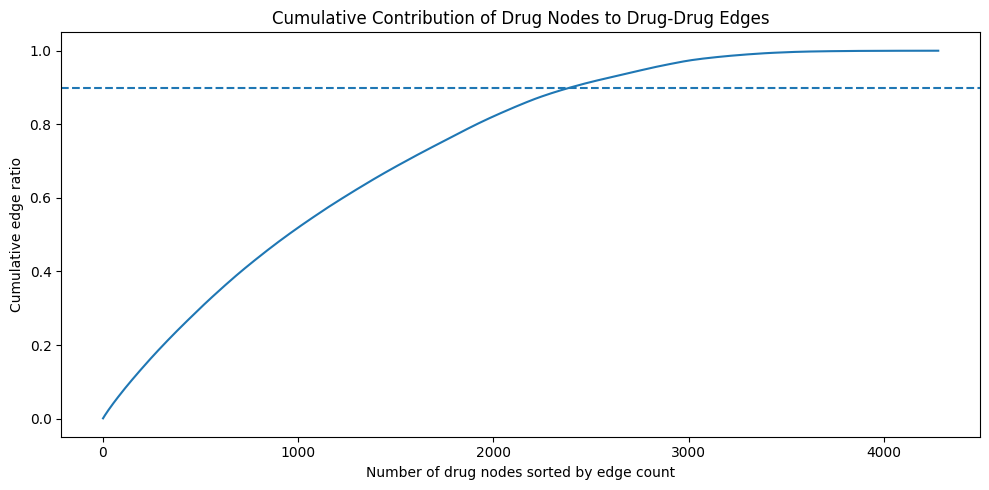

In [ ]:
#drug-drug concentration analysis

drug_drug_nodes_90, drug_drug_summary_90 = concentration_for_type_pair(
    src_type="drug",
    dst_type="drug",
    relation=None,
    endpoint="both",
    threshold=0.90
)

print("Drug-drug 90% concentration summary:")
print(drug_drug_summary_90)

display(drug_drug_nodes_90.head(30))

if not drug_drug_nodes_90.empty:
    plt.figure(figsize=(10, 5))
    plt.plot(range(1, len(drug_drug_nodes_90) + 1), drug_drug_nodes_90["cum_ratio"])
    plt.axhline(0.90, linestyle="--")
    plt.title("Cumulative Contribution of Drug Nodes to Drug-Drug Edges")
    plt.xlabel("Number of drug nodes sorted by edge count")
    plt.ylabel("Cumulative edge ratio")
    plt.tight_layout()
    plt.show()

In [ ]:
# 90% concentration analysis for main type pairs


main_pairs = [
    ("drug", "drug"),
    ("drug", "disease"),
    ("disease", "drug"),
    ("drug", "gene/protein"),
    ("gene/protein", "drug"),
    ("disease", "gene/protein"),
    ("gene/protein", "disease"),
    ("gene/protein", "gene/protein"),
]

concentration_summaries = []

for src, dst in main_pairs:
    _, summary = concentration_for_type_pair(
        src_type=src,
        dst_type=dst,
        endpoint="both",
        threshold=0.90
    )
    concentration_summaries.append(summary)

concentration_summary_df = pd.DataFrame(concentration_summaries)
display(concentration_summary_df.sort_values("total_edges", ascending=False))

,src_type,dst_type,relation,endpoint,total_edges,nodes_needed_for_threshold,available_nodes,percentage_of_nodes_needed,threshold
0,drug,drug,None,both,2672628,2394,4278,55.960729,0.9
7,gene/protein,gene/protein,None,both,642150,8998,18354,49.024736,0.9
5,disease,gene/protein,None,both,80411,6528,14673,44.489879,0.9
6,gene/protein,disease,None,both,80411,6528,14673,44.489879,0.9
1,drug,disease,None,both,42631,1748,4128,42.344961,0.9
2,disease,drug,None,both,42631,1748,4128,42.344961,0.9
3,drug,gene/protein,None,both,25653,4588,9376,48.933447,0.9
4,gene/protein,drug,None,both,25653,4588,9376,48.933447,0.9


Η edge concentration analysis δείχνει ότι οι βασικές κατηγορίες ακμών του γράφου δεν είναι ακραία συγκεντρωμένες σε πολύ μικρό αριθμό κόμβων. Για την κάλυψη του 90% των ακμών απαιτείται περίπου 42% έως 56% των συμμετεχόντων κόμβων, ανάλογα με το type pair. Αυτό δείχνει ότι υπάρχουν hub effects, αλλά όχι σε μεγάλο βαθμό.

Οι drug–disease σχέσεις εμφανίζουν τη μεγαλύτερη σχετική συγκέντρωση, καθώς περίπου το 42% των συμμετεχόντων drug/disease κόμβων καλύπτει το 90% των αντίστοιχων ακμών. Αυτό σημαίνει ότι οι γνωστές drug–disease σχέσεις επηρεάζονται περισσότερο από συγκεκριμένους καλά συνδεδεμένους κόμβους. Αντίθετα, οι drug–drug σχέσεις είναι λιγότερο συγκεντρωμένες, καθώς απαιτείται περίπου το 56% των συμμετεχόντων drug κόμβων για να καλυφθεί το 90% των ακμών.

Το αποτέλεσμα δείχνει ότι το μοντέλο μπορεί να επηρεαστεί από καλά συνδεδεμένους κόμβους, αλλά η πληροφορία δεν περιορίζεται αποκλειστικά σε λίγους hubs.

In [ ]:
#Relation-specific hubs


def top_nodes_for_relation(relation_name, top_k=20):
    temp = kg[kg["display_relation"] == relation_name].copy()

    if temp.empty:
        print("No edges found for relation:", relation_name)
        return pd.DataFrame()

    left = temp[["x_index", "x_name", "x_type"]].copy()
    left.columns = ["node_index", "node_name", "node_type"]

    right = temp[["y_index", "y_name", "y_type"]].copy()
    right.columns = ["node_index", "node_name", "node_type"]

    both = pd.concat([left, right], ignore_index=True)

    counts = (
        both.groupby(["node_index", "node_name", "node_type"])
        .size()
        .reset_index(name="edge_count")
        .sort_values("edge_count", ascending=False)
        .head(top_k)
    )

    return counts

for rel in ["indication", "contraindication", "off-label use", "target", "interacts with", "associated with"]:
    print("\nTop nodes for relation:", rel)
    display(top_nodes_for_relation(rel, top_k=20))


Top nodes for relation: indication


,node_index,node_name,node_type,edge_count
573,15003,Cortisone acetate,drug,296
12,14030,Prednisolone,drug,292
200,14320,Dexamethasone,drug,288
10,14028,Hydrocortisone,drug,278
7,14023,Triamcinolone,drug,258
4,14019,Betamethasone,drug,246
153,14269,Methylprednisolone,drug,236
8,14024,Prednisone,drug,218
2246,33577,hypertensive disorder,disease,206
2388,36035,hypertension,disease,206



Top nodes for relation: contraindication


,node_index,node_name,node_type,edge_count
1806,35961,gallbladder disease,disease,1308
1733,35565,liver disease,disease,1308
2175,83762,pyoureter,disease,1164
1762,35764,kidney disease,disease,1164
1400,29113,diabetic ketoacidosis,disease,690
1657,33575,diabetes mellitus (disease),disease,686
1741,35641,epilepsy,disease,620
1826,36035,hypertension,disease,616
1658,33577,hypertensive disorder,disease,614
2139,39531,liver failure,disease,546



Top nodes for relation: off-label use


...

,node_index,node_name,node_type,edge_count
3839,15674,Fostamatinib,drug,604
3024,14586,NADH,drug,288
2595,14012,Copper,drug,284
14,40,CDK2,gene/protein,272
3100,14679,Zinc,drug,248
3101,14680,Zinc acetate,drug,248
434,1659,ADRA1A,gene/protein,238
100,375,ESR1,gene/protein,236
9,29,F2,gene/protein,228
869,3417,HTR2A,gene/protein,228



Top nodes for relation: interacts with


,node_index,node_name,node_type,edge_count
22091,53699,protein binding,molecular_function,24870
23501,56073,nucleus,cellular_component,10790
23677,56436,cytosol,cellular_component,10568
23592,56241,cytoplasm,cellular_component,9448
23601,56263,plasma membrane,cellular_component,9372
38724,124249,nucleoplasm,cellular_component,7608
23182,55522,integral component of membrane,cellular_component,7316
22047,53620,metal ion binding,molecular_function,4644
39434,126196,extracellular exosome,cellular_component,4424
23300,55725,membrane,cellular_component,4260



Top nodes for relation: associated with


,node_index,node_name,node_type,edge_count
11024,32617,hereditary breast ovarian cancer syndrome,disease,2312
8596,28347,hereditary breast carcinoma,disease,2170
14425,84244,undifferentiated carcinoma of the corpus uteri,disease,2148
13490,36691,breast cancer,disease,2148
13242,35771,breast neoplasm,disease,2148
14424,84243,squamous cell carcinoma of the corpus uteri,disease,2148
8575,28313,schizophrenia,disease,1780
8883,28849,colorectal cancer,disease,1638
13435,36480,colorectal carcinoma,disease,1404
13451,36538,colorectal neoplasm,disease,1404


In [ ]:
# Percentage of known drug disease pairs
# with indirect biological support


shared_gene_protein_unique = shared_gene_protein_df[
    [
        "drug_index",
        "drug_name",
        "disease_index",
        "disease_name",
        "relation",
        "num_shared_gene_protein"
    ]
].drop_duplicates(
    subset=["drug_index", "disease_index", "relation"]
).copy()

shared_pathways_unique = shared_pathways_df[
    [
        "drug_index",
        "disease_index",
        "relation",
        "num_shared_pathways"
    ]
].drop_duplicates(
    subset=["drug_index", "disease_index", "relation"]
).copy()


indirect_support_df = pd.merge(
    shared_gene_protein_unique,
    shared_pathways_unique,
    on=["drug_index", "disease_index", "relation"],
    how="outer"
)



indirect_support_df = indirect_support_df.drop_duplicates(
    subset=["drug_index", "disease_index", "relation"]
).copy()

indirect_support_df["num_shared_gene_protein"] = (
    indirect_support_df["num_shared_gene_protein"]
    .fillna(0)
    .astype(int)
)

indirect_support_df["num_shared_pathways"] = (
    indirect_support_df["num_shared_pathways"]
    .fillna(0)
    .astype(int)
)

indirect_support_df["has_shared_gene_protein"] = (
    indirect_support_df["num_shared_gene_protein"] > 0
)

indirect_support_df["has_shared_pathway"] = (
    indirect_support_df["num_shared_pathways"] > 0
)


indirect_support_df["has_any_indirect_support"] = (
    indirect_support_df["has_shared_gene_protein"] |
    indirect_support_df["has_shared_pathway"]
)







total_unique_pairs = len(indirect_support_df)

pairs_with_gene_protein_support = indirect_support_df["has_shared_gene_protein"].sum()
pairs_with_pathway_support = indirect_support_df["has_shared_pathway"].sum()
pairs_with_any_indirect_support = indirect_support_df["has_any_indirect_support"].sum()
pairs_without_indirect_support = total_unique_pairs - pairs_with_any_indirect_support

print("Total UNIQUE known drug-disease pairs:", total_unique_pairs)

print(
    "Pairs with shared gene/protein:",
    pairs_with_gene_protein_support,
    f"({pairs_with_gene_protein_support / total_unique_pairs * 100:.2f}%)"
)

print(
    "Pairs with shared pathway:",
    pairs_with_pathway_support,
    f"({pairs_with_pathway_support / total_unique_pairs * 100:.2f}%)"
)

print(
    "Pairs with any indirect biological support:",
    pairs_with_any_indirect_support,
    f"({pairs_with_any_indirect_support / total_unique_pairs * 100:.2f}%)"
)

print(
    "Pairs without indirect biological support:",
    pairs_without_indirect_support,
    f"({pairs_without_indirect_support / total_unique_pairs * 100:.2f}%)"
)



display(
    indirect_support_df
    .sort_values(
        ["has_any_indirect_support", "num_shared_pathways", "num_shared_gene_protein"],
        ascending=False
    )
    .head(30)
)

Total UNIQUE known drug-disease pairs: 42631
Pairs with shared gene/protein: 6701 (15.72%)
Pairs with shared pathway: 20139 (47.24%)
Pairs with any indirect biological support: 20140 (47.24%)
Pairs without indirect biological support: 22491 (52.76%)


,drug_index,drug_name,disease_index,disease_name,relation,num_shared_gene_protein,num_shared_pathways,has_shared_gene_protein,has_shared_pathway,has_any_indirect_support
11360,14413,Nintedanib,31116,lung cancer,indication,7,150,True,True,True
27893,15599,Regorafenib,29646,hepatocellular carcinoma,indication,6,109,True,True,True
27895,15599,Regorafenib,36634,liver cancer,indication,6,109,True,True,True
11362,14413,Nintedanib,33688,non-small cell lung carcinoma (disease),indication,4,109,True,True,True
15333,14783,Caffeine,30035,substance abuse/dependence,contraindication,5,108,True,True,True
27896,15599,Regorafenib,36999,adenocarcinoma of liver and intrahepatic bilia...,indication,5,104,True,True,True
27897,15599,Regorafenib,37115,squamous cell carcinoma of liver and intrahepa...,indication,5,104,True,True,True
27900,15599,Regorafenib,83870,undifferentiated carcinoma of liver and intrah...,indication,5,104,True,True,True
15317,14783,Caffeine,27933,anxiety disorder,contraindication,8,101,True,True,True
27899,15599,Regorafenib,83869,fibrolamellar hepatocellular carcinoma,indication,4,101,True,True,True


,relation,total_unique_pairs,pairs_with_shared_gene_protein,pairs_with_shared_pathway,pairs_with_any_indirect_support,shared_gene_protein_percent,shared_pathway_percent,any_indirect_support_percent
0,contraindication,30675,4409,14282,14283,14.37,46.56,46.56
1,indication,9388,1931,4563,4563,20.57,48.60,48.60
2,off-label use,2568,361,1294,1294,14.06,50.39,50.39


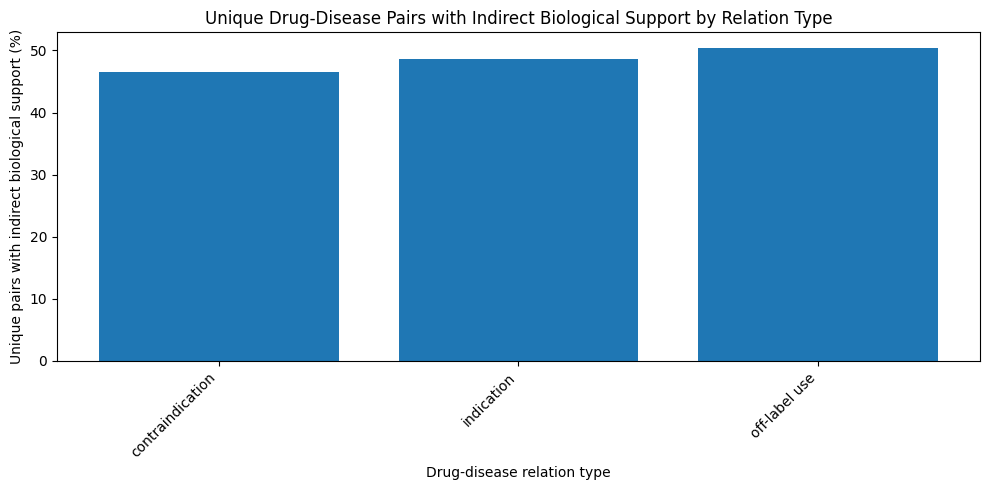

In [ ]:
# ------------------------------------------------------------
# Indirect biological support by drug-disease relation type
# using UNIQUE drug-disease-relation pairs
# ------------------------------------------------------------

# Safety: make sure we only count each drug-disease-relation pair once
indirect_support_unique = indirect_support_df.drop_duplicates(
    subset=["drug_index", "disease_index", "relation"]
).copy()

indirect_support_by_relation = (
    indirect_support_unique
    .groupby("relation")
    .agg(
        total_unique_pairs=("relation", "count"),
        pairs_with_shared_gene_protein=("has_shared_gene_protein", "sum"),
        pairs_with_shared_pathway=("has_shared_pathway", "sum"),
        pairs_with_any_indirect_support=("has_any_indirect_support", "sum")
    )
    .reset_index()
)

indirect_support_by_relation["shared_gene_protein_percent"] = (
    indirect_support_by_relation["pairs_with_shared_gene_protein"] /
    indirect_support_by_relation["total_unique_pairs"] * 100
)

indirect_support_by_relation["shared_pathway_percent"] = (
    indirect_support_by_relation["pairs_with_shared_pathway"] /
    indirect_support_by_relation["total_unique_pairs"] * 100
)

indirect_support_by_relation["any_indirect_support_percent"] = (
    indirect_support_by_relation["pairs_with_any_indirect_support"] /
    indirect_support_by_relation["total_unique_pairs"] * 100
)

percent_cols = [
    "shared_gene_protein_percent",
    "shared_pathway_percent",
    "any_indirect_support_percent"
]

indirect_support_by_relation[percent_cols] = (
    indirect_support_by_relation[percent_cols].round(2)
)

display(indirect_support_by_relation)







plt.figure(figsize=(10, 5))

plt.bar(
    indirect_support_by_relation["relation"],
    indirect_support_by_relation["any_indirect_support_percent"]
)

plt.title("Unique Drug-Disease Pairs with Indirect Biological Support by Relation Type")
plt.xlabel("Drug-disease relation type")
plt.ylabel("Unique pairs with indirect biological support (%)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Παραπάνω πραγματοποιείται ο έλεγχος για το ποσοστό των άμεσων σχέσεων drug disease που συνδέονται με έμμεσες σχέσεις που εμπλέκουν pathway και gene/protein

Τα αποτελέσματα δείχνουν ότι οι indication σχέσεις εμφανίζουν το υψηλότερο ποσοστό άμεσης gene/protein υποστήριξης, με 1.931 από τα 9.388 ζεύγη, δηλαδή 20,57%, να έχουν τουλάχιστον έναν κοινό gene/protein κόμβο. Αντίθετα, το αντίστοιχο ποσοστό είναι 14,37% για τα contraindications και 14,06% για τα off-label use pairs.

Η υποστήριξη μέσω κοινών pathways είναι σημαντικά συχνότερη σε όλες τις κατηγορίες. Συγκεκριμένα, 14.282 από τα 30.675 contraindication pairs, δηλαδή 46,56%, έχουν τουλάχιστον ένα κοινό pathway. Για τα indication pairs το ποσοστό είναι 48,60%, ενώ για τα off-label use pairs φτάνει το 50,39%. Το αποτέλεσμα αυτό δείχνει ότι τα pathways λειτουργούν ως ευρύτερο ενδιάμεσο βιολογικό επίπεδο σύνδεσης μεταξύ φαρμάκων και ασθενειών.

Ενδιαφέρον παρουσιάζει οτι τα off-label use pairs έχουν το υψηλότερο ποσοστό shared pathway υποστήριξης. Επειδή οι off-label use σχέσεις συνδέονται άμεσα με τη λογική του drug repurposing
Από τα παραπάνω καταλήγουμε στο συμπέρασμα ότι οι pathway related σχέσεις μπορούν να είναι χρήσιμες για την επιλογή υπογράφου και την ερμηνεία πιθανών νέων drug–disease προβλέψεων.

## Aνάλυση για έμμεσες συνδέσεις για τα ζευγάρια που έχουν άμεση σύνδεση drug–disease.
Α) Η παρακάτω ανάλυση γίνεται για να δούμε το είδος των κορυφών που παρεμβάλουν σε έμμεσες συνδέσεις drug–disease.

In [ ]:
# Connectivity check of the full PrimeKG graph as UNDIRECTED


import networkx as nx
import pandas as pd
import numpy as np


edges = kg[["x_index", "y_index"]].dropna().copy()


edges["x_index"] = edges["x_index"].astype(int)
edges["y_index"] = edges["y_index"].astype(int)

#Canonical undirected edge representation to remove duplicated directions
edges["u"] = np.minimum(edges["x_index"], edges["y_index"])
edges["v"] = np.maximum(edges["x_index"], edges["y_index"])


undirected_edges = (
    edges[edges["u"] != edges["v"]]
    [["u", "v"]]
    .drop_duplicates()
    .copy()
)

print("Original directed edge rows:", len(kg))
print("Unique undirected edges:", len(undirected_edges))

# Create undirected graph
G_undirected = nx.Graph()

#Add all nodes appearing in the graph
all_nodes = pd.concat([kg["x_index"], kg["y_index"]]).dropna().astype(int).unique()
G_undirected.add_nodes_from(all_nodes)

#Add unique undirected edges
G_undirected.add_edges_from(
    undirected_edges[["u", "v"]].itertuples(index=False, name=None)
)

print("Number of nodes:", G_undirected.number_of_nodes())
print("Number of edges:", G_undirected.number_of_edges())

#Check if the graph is connected
is_connected = nx.is_connected(G_undirected)

print("Is the full graph connected as undirected graph?", is_connected)

Original directed edge rows: 8100498
Unique undirected edges: 4049642
Number of nodes: 129375
Number of edges: 4049642
Is the full graph connected as undirected graph? True


In [ ]:
# Full corrected 2-hop indirect path pattern analysis
# Drug -- Intermediate node -- Disease


from collections import Counter
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt




candidate_dfs = []

for name, obj in list(globals().items()):
    if isinstance(obj, pd.DataFrame):
        cols = set(obj.columns)

        required_cols = {"x_index", "y_index", "x_type", "y_type"}

        if required_cols.issubset(cols):
            candidate_dfs.append((name, obj.shape))

print("Candidate PrimeKG dataframes:")
for name, shape in candidate_dfs:
    print(name, shape)

if len(candidate_dfs) == 0:
    raise ValueError(
        "No dataframe with columns x_index, y_index, x_type, y_type was found. "
        "Check the name and columns of your PrimeKG dataframe."
    )

main_df_name = max(candidate_dfs, key=lambda x: x[1][0])[0]
kg = globals()[main_df_name]

print("\nUsing dataframe as kg:", main_df_name)
print("kg shape:", kg.shape)
print("kg columns:", list(kg.columns))



node_types_x = kg[["x_index", "x_type"]].rename(
    columns={"x_index": "node", "x_type": "type"}
)

node_types_y = kg[["y_index", "y_type"]].rename(
    columns={"y_index": "node", "y_type": "type"}
)

node_type_df = (
    pd.concat([node_types_x, node_types_y], ignore_index=True)
    .drop_duplicates(subset=["node"])
)

node_type = dict(zip(node_type_df["node"], node_type_df["type"]))

print("\nNode types loaded:", len(node_type))





if "G_undirected" not in globals():
    print("\nG_undirected not found. Building undirected graph...")

    edges = kg[["x_index", "y_index"]].dropna().copy()

    edges["x_index"] = edges["x_index"].astype(int)
    edges["y_index"] = edges["y_index"].astype(int)

    edges["u"] = edges[["x_index", "y_index"]].min(axis=1)
    edges["v"] = edges[["x_index", "y_index"]].max(axis=1)

    undirected_edges = (
        edges[edges["u"] != edges["v"]]
        [["u", "v"]]
        .drop_duplicates()
        .copy()
    )

    G_undirected = nx.from_pandas_edgelist(
        undirected_edges,
        source="u",
        target="v",
        create_using=nx.Graph()
    )

    print("Graph created.")
else:
    print("\nUsing existing G_undirected.")

print("Number of nodes:", G_undirected.number_of_nodes())
print("Number of edges:", G_undirected.number_of_edges())




if "indirect_support_df" not in globals():
    raise ValueError(
        "indirect_support_df was not found. "
        "Run the previous indirect biological support analysis first."
    )

known_dd_pairs = indirect_support_df[
    [
        "drug_index",
        "drug_name",
        "disease_index",
        "disease_name",
        "relation"
    ]
].drop_duplicates(
    subset=["drug_index", "disease_index", "relation"]
).copy()

print("\nUnique known drug-disease-relation pairs:", len(known_dd_pairs))
display(known_dd_pairs.head())





#Find all 2-hop paths and classify by intermediate node type

two_hop_rows = []

for _, row in known_dd_pairs.iterrows():
    drug = row["drug_index"]
    disease = row["disease_index"]

    if drug not in G_undirected or disease not in G_undirected:
        common_intermediates = set()
    else:
        drug_neighbors = set(G_undirected.neighbors(drug))
        disease_neighbors = set(G_undirected.neighbors(disease))

        common_intermediates = drug_neighbors.intersection(disease_neighbors)

        common_intermediates.discard(drug)
        common_intermediates.discard(disease)

    intermediate_type_counts = Counter()

    for node in common_intermediates:
        intermediate_type = node_type.get(node, "unknown")
        intermediate_type_counts[intermediate_type] += 1

    result = {
        "drug_index": drug,
        "drug_name": row["drug_name"],
        "disease_index": disease,
        "disease_name": row["disease_name"],
        "relation": row["relation"],
        "num_2hop_paths": len(common_intermediates),
        "has_2hop_path": len(common_intermediates) > 0
    }

    for intermediate_type, count in intermediate_type_counts.items():
        result[f"2hop_via_{intermediate_type}"] = count

    two_hop_rows.append(result)

two_hop_df = pd.DataFrame(two_hop_rows).fillna(0)

print("\nAnalyzed unique drug-disease pairs:", len(two_hop_df))
print(
    "Pairs with at least one 2-hop indirect path:",
    two_hop_df["has_2hop_path"].sum(),
    f"({two_hop_df['has_2hop_path'].mean() * 100:.2f}%)"
)

display(
    two_hop_df
    .sort_values("num_2hop_paths", ascending=False)
    .head(30)
)

Candidate PrimeKG dataframes:
__ (5, 12)
___ (5, 12)
kg (8100498, 13)
_2 (5, 12)
_3 (5, 12)
drug_disease (85262, 19)
drug_protein (51306, 13)
disease_protein (160822, 13)
pathway_edges (90362, 14)
kg_undirected (8100498, 17)
unique_edges_undirected (4050249, 17)
kg_undirected_degree (8100498, 15)
unique_undirected_edges (4050249, 15)
indication_edges (18776, 19)
contra_edges (61350, 19)
offlabel_edges (5136, 19)
gene_protein_pathway (85292, 13)

Using dataframe as kg: kg
kg shape: (8100498, 13)
kg columns: ['relation', 'display_relation', 'x_index', 'x_id', 'x_type', 'x_name', 'x_source', 'y_index', 'y_id', 'y_type', 'y_name', 'y_source', 'type_pair']

Node types loaded: 129375

Using existing G_undirected.
Number of nodes: 129375
Number of edges: 4049642

Unique known drug-disease-relation pairs: 42631


,drug_index,drug_name,disease_index,disease_name,relation
0,14014,Flunisolide,29229,glaucoma,contraindication
1,14014,Flunisolide,30813,Addison disease,contraindication
2,14014,Flunisolide,33675,asthma,indication
3,14014,Flunisolide,35533,dermatophytosis,contraindication
4,14014,Flunisolide,35543,fungal infectious disease,contraindication



Analyzed unique drug-disease pairs: 42631
Pairs with at least one 2-hop indirect path: 40401 (94.77%)


,drug_index,drug_name,disease_index,disease_name,relation,num_2hop_paths,has_2hop_path,2hop_via_drug,2hop_via_effect/phenotype,2hop_via_disease,2hop_via_gene/protein
7413,14258,Quinidine,35565,liver disease,contraindication,553,True,552.0,0.0,1.0,0.0
4371,14178,Chlorpromazine,35565,liver disease,contraindication,553,True,553.0,0.0,0.0,0.0
4377,14178,Chlorpromazine,35961,gallbladder disease,contraindication,553,True,553.0,0.0,0.0,0.0
7416,14258,Quinidine,35961,gallbladder disease,contraindication,552,True,552.0,0.0,0.0,0.0
3478,14156,Amitriptyline,35961,gallbladder disease,contraindication,545,True,545.0,0.0,0.0,0.0
3470,14156,Amitriptyline,35565,liver disease,contraindication,545,True,545.0,0.0,0.0,0.0
21653,15093,Clozapine,35565,liver disease,contraindication,541,True,541.0,0.0,0.0,0.0
21657,15093,Clozapine,35961,gallbladder disease,contraindication,541,True,541.0,0.0,0.0,0.0
18733,14952,Haloperidol,35961,gallbladder disease,contraindication,537,True,537.0,0.0,0.0,0.0
18730,14952,Haloperidol,35565,liver disease,contraindication,537,True,537.0,0.0,0.0,0.0


Στη γενική 2-hop ανάλυση εξετάστηκαν 42.631 μοναδικά drug–disease pairs. Από αυτά, 40.401 pairs, δηλαδή 94,77%, έχουν τουλάχιστον ένα έμμεσο 2-hop μονοπάτι της μορφής Drug–X–Disease.

Το ποσοστό αυτό είναι αρκετά υψηλό, αλλά χρειάζεται προσεκτική ερμηνεία. Επειδή ο PrimeKG περιλαμβάνει πολύ μεγάλο αριθμό drug–drug σχέσεων, πολλά από τα 2-hop μονοπάτια μπορεί να έχουν μορφή Drug A–Drug B–Disease. Επομένως, το 94,77% δεν πρέπει να ερμηνευθεί άμεσα ως καθαρή βιολογική υποστήριξη μέσω proteins ή pathways, αλλά ως ένδειξη γενικής υψηλής συνδεσιμότητας του γράφου σε 2 hops.

Για τον λόγο αυτό, στο επόμενο βήμα ταξινομούμε τα 2-hop μονοπάτια με βάση τον τύπο του ενδιάμεσου κόμβου X. Με αυτόν τον τρόπο μπορούμε να δούμε ποιο ποσοστό των έμμεσων συνδέσεων περνά μέσω drug, gene/protein, disease, effect/phenotype ή άλλων τύπων κόμβων.

In [ ]:
# Summary of 2-hop path patterns by intermediate node type
# Drug-x-Disease

pattern_cols = [
    col for col in two_hop_df.columns
    if col.startswith("2hop_via_")
]

two_hop_pattern_summary = []

for col in pattern_cols:
    intermediate_type = col.replace("2hop_via_", "")

    total_paths = two_hop_df[col].sum()
    pairs_with_pattern = (two_hop_df[col] > 0).sum()
    percent_pairs = pairs_with_pattern / len(two_hop_df) * 100

    two_hop_pattern_summary.append({
        "path_pattern": f"Drug-{intermediate_type}-Disease",
        "intermediate_type": intermediate_type,
        "total_2hop_paths": int(total_paths),
        "pairs_with_this_pattern": int(pairs_with_pattern),
        "percent_of_pairs": round(percent_pairs, 2)
    })

two_hop_pattern_summary_df = (
    pd.DataFrame(two_hop_pattern_summary)
    .sort_values("pairs_with_this_pattern", ascending=False)
)

display(two_hop_pattern_summary_df)

,path_pattern,intermediate_type,total_2hop_paths,pairs_with_this_pattern,percent_of_pairs
0,Drug-drug-Disease,drug,2277692,37758,88.57
2,Drug-disease-Disease,disease,34619,24141,56.63
3,Drug-gene/protein-Disease,gene/protein,14625,6701,15.72
1,Drug-effect/phenotype-Disease,effect/phenotype,17500,4959,11.63


88.57% έχουν 2-hop μονοπάτι μέσω drug

56.63% έχουν 2-hop μονοπάτι μέσω disease

15.72% έχουν 2-hop μονοπάτι gene/protein

11.63% έχουν 2-hop μονοπάτι effect/phenotype


Στη συνέχεια ταξινομήθηκαν τα 2-hop μονοπάτια της μορφής Drug–X–Disease με βάση τον τύπο του ενδιάμεσου κόμβου X. Η ανάλυση έδειξε ότι το συχνότερο 2-hop pattern είναι το Drug–Drug–Disease, το οποίο εμφανίζεται σε 37.758 από τα 42.631 γνωστά drug–disease pairs, δηλαδή στο 88,57% των περιπτώσεων. Επιπλέον, το συνολικό πλήθος τέτοιων 2-hop paths είναι 2.277.692, γεγονός που δείχνει ότι οι drug–drug σχέσεις δημιουργούν πολύ μεγάλο αριθμό σύντομων μονοπατιών στον γράφο.

Το δεύτερο συχνότερο pattern είναι το Drug–Disease–Disease, το οποίο εμφανίζεται σε 24.141 pairs, δηλαδή στο 56,63%. Αντίθετα, τα πιο άμεσα μοριακά μονοπάτια τύπου Drug–Gene/Protein–Disease εμφανίζονται σε 6.701 pairs, δηλαδή στο 15,72%, ενώ τα Drug–Effect/Phenotype–Disease μονοπάτια εμφανίζονται σε 4.959 pairs, δηλαδή στο 11,63%.

Τα αποτελέσματα αυτά δείχνουν ότι, αν εξεταστούν όλα τα 2-hop μονοπάτια του συνολικού PrimeKG, οι drug–drug mediated συνδέσεις κυριαρχούν. Επομένως, το υψηλό συνολικό ποσοστό ύπαρξης 2-hop μονοπατιών δεν πρέπει να ερμηνευθεί απευθείας ως καθαρή βιολογική υποστήριξη μέσω gene/protein ή pathway μηχανισμών. Αντίθετα, δείχνει ότι οι drug–drug σχέσεις είναι πολλες και μπορούν να επηρεάσουν έντονα την εκπαίδευση.


## Παρακάτω εξετάζονται έμμεσα μονοπάτια με τέσσερις κορυφές, δηλαδή 3-hop paths της μορφής Drug–X–Y–Disease, όπου τα άκρα του μονοπατιού είναι ένας drug κόμβος και ένας disease κόμβος.

Με βάση την προηγούμενη 2-hop ανάλυση, παρατηρήθηκε ότι πολλά σύντομα μονοπάτια περνούν μέσω drug ή disease κόμβων, όπως Drug–Drug–Disease και Drug–Disease–Disease. Επειδή τέτοια μονοπάτια μπορεί να κυριαρχούν λόγω της πυκνότητας των drug–drug και disease–disease σχέσεων, στην επόμενη ανάλυση θα δοθεί έμφαση σε πιο βιολογικά ερμηνεύσιμα 3-hop μονοπάτια. Για τον λόγο αυτό, θα εξεταστεί η αφαίρεση ή ξεχωριστή μεταχείριση των μονοπατιών στα οποία οι ενδιάμεσοι κόμβοι είναι τύπου drug ή disease.

In [ ]:
# 3-hop indirect path pattern analysis
# Drug-X-Y-Disease




from collections import Counter, defaultdict
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


if "G_undirected" not in globals():
    raise ValueError("G_undirected was not found. Run the undirected graph construction first.")

if "indirect_support_df" not in globals():
    raise ValueError("indirect_support_df was not found. Run the indirect support analysis first.")

# If node_type does not exist, create it from kg
if "node_type" not in globals():
    if "kg" not in globals():
        raise ValueError("Neither node_type nor kg was found. Run the previous graph setup cell first.")

    node_types_x = kg[["x_index", "x_type"]].rename(
        columns={"x_index": "node", "x_type": "type"}
    )

    node_types_y = kg[["y_index", "y_type"]].rename(
        columns={"y_index": "node", "y_type": "type"}
    )

    node_type_df = (
        pd.concat([node_types_x, node_types_y], ignore_index=True)
        .drop_duplicates(subset=["node"])
    )

    node_type = dict(zip(node_type_df["node"], node_type_df["type"]))

print("Node types loaded:", len(node_type))




known_dd_pairs = indirect_support_df[
    [
        "drug_index",
        "drug_name",
        "disease_index",
        "disease_name",
        "relation"
    ]
].drop_duplicates(
    subset=["drug_index", "disease_index", "relation"]
).copy()

print("Unique known drug-disease-relation pairs:", len(known_dd_pairs))



adj = {
    node: set(G_undirected.neighbors(node))
    for node in G_undirected.nodes()
}

print("Adjacency dictionary created.")





excluded_intermediate_types = {"drug", "disease"}




three_hop_rows = []

for _, row in known_dd_pairs.iterrows():
    drug = row["drug_index"]
    disease = row["disease_index"]

    if drug not in adj or disease not in adj:
        left_nodes = set()
        right_nodes = set()
    else:
        #X candidates: neighbors of Drug
        left_nodes = adj[drug].copy()

        #Y candidates: neighbors of Disease
        right_nodes = adj[disease].copy()

        # Remove endpoints
        left_nodes.discard(drug)
        left_nodes.discard(disease)
        right_nodes.discard(drug)
        right_nodes.discard(disease)

        #Remove intermediate nodes of type drug or disease
        left_nodes = {
            n for n in left_nodes
            if node_type.get(n, "unknown") not in excluded_intermediate_types
        }

        right_nodes = {
            n for n in right_nodes
            if node_type.get(n, "unknown") not in excluded_intermediate_types
        }

    pattern_counts = Counter()
    total_3hop_paths = 0





    for x in left_nodes:
        x_neighbors = adj.get(x, set())

        #Y nodes that connect X to Disease side
        valid_y_nodes = x_neighbors.intersection(right_nodes)

        for y in valid_y_nodes:
            x_type = node_type.get(x, "unknown")
            y_type = node_type.get(y, "unknown")

            pattern = f"Drug-{x_type}-{y_type}-Disease"
            pattern_counts[pattern] += 1
            total_3hop_paths += 1

    result = {
        "drug_index": drug,
        "drug_name": row["drug_name"],
        "disease_index": disease,
        "disease_name": row["disease_name"],
        "relation": row["relation"],
        "num_3hop_paths_no_drug_disease_intermediate": total_3hop_paths,
        "has_3hop_path_no_drug_disease_intermediate": total_3hop_paths > 0
    }

    for pattern, count in pattern_counts.items():
        result[f"3hop_{pattern}"] = count

    three_hop_rows.append(result)

three_hop_df = pd.DataFrame(three_hop_rows).fillna(0)

print("Analyzed unique drug-disease pairs:", len(three_hop_df))
print(
    "Pairs with at least one 3-hop path without drug/disease intermediates:",
    three_hop_df["has_3hop_path_no_drug_disease_intermediate"].sum(),
    f"({three_hop_df['has_3hop_path_no_drug_disease_intermediate'].mean() * 100:.2f}%)"
)

display(
    three_hop_df
    .sort_values("num_3hop_paths_no_drug_disease_intermediate", ascending=False)
    .head(30)
)

Node types loaded: 129375
Unique known drug-disease-relation pairs: 42631
Adjacency dictionary created.
Analyzed unique drug-disease pairs: 42631
Pairs with at least one 3-hop path without drug/disease intermediates: 24615 (57.74%)


,drug_index,drug_name,disease_index,disease_name,relation,num_3hop_paths_no_drug_disease_intermediate,has_3hop_path_no_drug_disease_intermediate,3hop_Drug-effect/phenotype-effect/phenotype-Disease,3hop_Drug-gene/protein-gene/protein-Disease,3hop_Drug-effect/phenotype-gene/protein-Disease,3hop_Drug-gene/protein-effect/phenotype-Disease,3hop_Drug-gene/protein-exposure-Disease
5860,14213,Tamoxifen,32617,hereditary breast ovarian cancer syndrome,off-label use,882,True,1.0,783.0,98.0,0.0,0.0
14004,14685,Progesterone,32617,hereditary breast ovarian cancer syndrome,contraindication,675,True,0.0,518.0,157.0,0.0,0.0
10223,14323,Aripiprazole,28313,schizophrenia,indication,635,True,11.0,251.0,373.0,0.0,0.0
18385,14943,Levonorgestrel,32617,hereditary breast ovarian cancer syndrome,contraindication,504,True,2.0,432.0,70.0,0.0,0.0
5569,14208,Testosterone,32617,hereditary breast ovarian cancer syndrome,contraindication,471,True,1.0,360.0,110.0,0.0,0.0
1963,14058,Diethylstilbestrol,32617,hereditary breast ovarian cancer syndrome,contraindication,471,True,0.0,471.0,0.0,0.0,0.0
22408,15116,Paroxetine,27933,anxiety disorder,indication,467,True,0.0,126.0,341.0,0.0,0.0
13983,14685,Progesterone,27933,anxiety disorder,contraindication,459,True,0.0,210.0,241.0,0.0,8.0
2985,14144,Topiramate,27933,anxiety disorder,contraindication,453,True,0.0,71.0,380.0,0.0,2.0
5730,14211,Estrone,32617,hereditary breast ovarian cancer syndrome,contraindication,444,True,0.0,389.0,55.0,0.0,0.0


In [ ]:
# Summary of 3-hop path patterns
# Drug-X-Y-Disease


three_hop_pattern_cols = [
    col for col in three_hop_df.columns
    if col.startswith("3hop_Drug-")
]

three_hop_pattern_summary = []

for col in three_hop_pattern_cols:
    path_pattern = col.replace("3hop_", "")

    total_paths = three_hop_df[col].sum()
    pairs_with_pattern = (three_hop_df[col] > 0).sum()
    percent_pairs = pairs_with_pattern / len(three_hop_df) * 100

    three_hop_pattern_summary.append({
        "path_pattern": path_pattern,
        "total_3hop_paths": int(total_paths),
        "pairs_with_this_pattern": int(pairs_with_pattern),
        "percent_of_pairs": round(percent_pairs, 2)
    })

three_hop_pattern_summary_df = (
    pd.DataFrame(three_hop_pattern_summary)
    .sort_values("pairs_with_this_pattern", ascending=False)
)

display(three_hop_pattern_summary_df)

,path_pattern,total_3hop_paths,pairs_with_this_pattern,percent_of_pairs
2,Drug-effect/phenotype-gene/protein-Disease,419487,17801,41.76
1,Drug-gene/protein-gene/protein-Disease,169818,13986,32.81
0,Drug-effect/phenotype-effect/phenotype-Disease,18378,4814,11.29
3,Drug-gene/protein-effect/phenotype-Disease,7309,2872,6.74
4,Drug-gene/protein-exposure-Disease,6074,2377,5.58


Μετά από αυτό το φιλτράρισμα, βρέθηκε ότι 24.615 από τα 42.631 μοναδικά γνωστά drug–disease pairs, δηλαδή 57,74%, έχουν τουλάχιστον ένα 3-hop μονοπάτι μέσω άλλων τύπων κόμβων. Αυτό δείχνει ότι πάνω από τα μισά γνωστά drug–disease pairs διαθέτουν επιπλέον έμμεσες συνδέσεις που δεν βασίζονται σε drug–drug ή disease–disease paths.

Το συχνότερο 3-hop pattern είναι το Drug–Effect/Phenotype–Gene/Protein–Disease, το οποίο εμφανίζεται σε 17.801 pairs, δηλαδή στο 41,76% των γνωστών drug–disease pairs. Το δεύτερο συχνότερο pattern είναι το Drug–Gene/Protein–Gene/Protein–Disease, το οποίο εμφανίζεται σε 13.986 pairs, δηλαδή στο 32,81%.

Το αποτέλεσμα αυτό δείχνει ότι οι gene/protein κόμβοι έχουν κεντρικό ρόλο στις έμμεσες συνδέσεις drug–disease, είτε μόνοι τους είτε σε συνδυασμό με effect/phenotype κόμβους. Ιδιαίτερα το pattern Drug–Gene/Protein–Gene/Protein–Disease υποστηρίζει την ιδέα ότι οι gene/protein–gene/protein ή protein–protein σχέσεις μπορούν να προσθέσουν χρήσιμη βιολογική πληροφορία στον υπογράφο. Παράλληλα, η υψηλή παρουσία των effect/phenotype κόμβων δείχνει ότι υπάρχει και σημαντική φαινοτυπική ή κλινική πληροφορία, η οποία όμως πρέπει να εξεταστεί προσεκτικά, επειδή δεν αντιστοιχεί πάντα σε άμεσο μοριακό μηχανισμό.

In [ ]:
# Overlap analysis between 3-hop path patterns

three_hop_pattern_cols = [
    col for col in three_hop_df.columns
    if col.startswith("3hop_Drug-")
]

# Create binary dataframe: True if pair has this pattern
pattern_binary_df = three_hop_df[
    [
        "drug_index",
        "drug_name",
        "disease_index",
        "disease_name",
        "relation"
    ] + three_hop_pattern_cols
].copy()

for col in three_hop_pattern_cols:
    pattern_binary_df[col] = pattern_binary_df[col] > 0

# Rename columns to cleaner pattern names
clean_pattern_names = {
    col: col.replace("3hop_", "")
    for col in three_hop_pattern_cols
}

pattern_binary_clean = pattern_binary_df.rename(columns=clean_pattern_names)

clean_cols = list(clean_pattern_names.values())







overlap_rows = []

for pattern_a in clean_cols:
    pairs_a = pattern_binary_clean[pattern_binary_clean[pattern_a]]
    count_a = len(pairs_a)

    row = {
        "pattern": pattern_a,
        "pairs_with_pattern": count_a
    }

    for pattern_b in clean_cols:
        if count_a == 0:
            overlap_percent = 0
        else:
            overlap_count = pairs_a[pattern_b].sum()
            overlap_percent = overlap_count / count_a * 100

        row[pattern_b] = round(overlap_percent, 2)

    overlap_rows.append(row)

overlap_matrix_df = pd.DataFrame(overlap_rows)

display(overlap_matrix_df)

,pattern,pairs_with_pattern,Drug-effect/phenotype-effect/phenotype-Disease,Drug-gene/protein-gene/protein-Disease,Drug-effect/phenotype-gene/protein-Disease,Drug-gene/protein-effect/phenotype-Disease,Drug-gene/protein-exposure-Disease
0,Drug-effect/phenotype-effect/phenotype-Disease,4814,100.00,36.41,66.64,36.48,5.21
1,Drug-gene/protein-gene/protein-Disease,13986,12.53,100.00,67.71,9.02,11.57
2,Drug-effect/phenotype-gene/protein-Disease,17801,18.02,53.20,100.00,8.75,8.26
3,Drug-gene/protein-effect/phenotype-Disease,2872,61.14,43.91,54.21,100.00,6.86
4,Drug-gene/protein-exposure-Disease,2377,10.56,68.07,61.84,8.29,100.00


Στη συνέχεια πραγματοποιήθηκε ανάλυση επικάλυψης μεταξύ των διαφορετικών 3-hop path patterns. Στόχος ήταν να εξεταστεί αν κάποια patterns προσφέρουν ανεξάρτητη πληροφορία ή αν εμφανίζονται σχεδόν πάντα μαζί με άλλα patterns.

Τα αποτελέσματα δείχνουν ότι τα δύο σημαντικότερα patterns είναι το Drug–Effect/Phenotype–Gene/Protein–Disease και το Drug–Gene/Protein–Gene/Protein–Disease. Το πρώτο εμφανίζεται σε 17.801 drug–disease pairs, ενώ το δεύτερο σε 13.986 pairs. Η επικάλυψη μεταξύ τους είναι σημαντική αλλά όχι πλήρης: από τα pairs που έχουν Drug–Effect/Phenotype–Gene/Protein–Disease, το 53,20% έχουν επίσης Drug–Gene/Protein–Gene/Protein–Disease. Αντίστροφα, από τα pairs που έχουν Drug–Gene/Protein–Gene/Protein–Disease, το 67,71% έχουν επίσης Drug–Effect/Phenotype–Gene/Protein–Disease.

Αυτό σημαίνει ότι τα δύο patterns είναι μερικώς συμπληρωματικά και δεν καλύπτονται πλήρως το ένα από το άλλο. Επομένως, το Drug–Gene/Protein–Gene/Protein–Disease pattern παραμένει σημαντικό, επειδή υποστηρίζει τη χρήση gene/protein–gene/protein ή protein–protein σχέσεων στον υπογράφο. Παράλληλα, το Drug–Effect/Phenotype–Gene/Protein–Disease pattern δείχνει ότι οι effect/phenotype κόμβοι μπορούν να προσφέρουν επιπλέον φαινοτυπική ή κλινική πληροφορία.

Αντίθετα, το Drug–Gene/Protein–Exposure–Disease εμφανίζεται σε λιγότερα pairs και έχει υψηλή επικάλυψη με τα δύο βασικά patterns, καθώς το 68,07% των pairs που το έχουν διαθέτουν επίσης Drug–Gene/Protein–Gene/Protein–Disease και το 61,84% διαθέτουν επίσης Drug–Effect/Phenotype–Gene/Protein–Disease. Επομένως, οι exposure κόμβοι φαίνεται να προσθέτουν λιγότερη ανεξάρτητη πληροφορία και μπορούν να εξεταστούν σε μεταγενέστερο ή προαιρετικό στάδιο.

## Aνάλυση για έμμεσες συνδέσεις για τα ζευγάρια που έχουν άμεση σύνδεση drug–disease.
Β) Η παρακάτω ανάλυση γίνεται για να δούμε το είδος των ακμών που παρεμβάλουν σε έμμεσες συνδέσεις drug–disease.

In [ ]:
# 2-hop edge-type pattern analysis
# Drug-X-Disease


from collections import Counter, defaultdict
import pandas as pd
import numpy as np





if "kg" not in globals():
    raise ValueError("kg was not found. Make sure your PrimeKG dataframe is named kg.")

if "G_undirected" not in globals():
    raise ValueError("G_undirected was not found. Run the undirected graph construction first.")

if "indirect_support_df" not in globals():
    raise ValueError("indirect_support_df was not found. Run the indirect support analysis first.")

# Create node_type dictionary if it does not already exist
if "node_type" not in globals():
    node_types_x = kg[["x_index", "x_type"]].rename(
        columns={"x_index": "node", "x_type": "type"}
    )

    node_types_y = kg[["y_index", "y_type"]].rename(
        columns={"y_index": "node", "y_type": "type"}
    )

    node_type_df = (
        pd.concat([node_types_x, node_types_y], ignore_index=True)
        .drop_duplicates(subset=["node"])
    )

    node_type = dict(zip(node_type_df["node"], node_type_df["type"]))

print("Node types loaded:", len(node_type))



if "display_relation" in kg.columns:
    relation_col = "display_relation"
else:
    relation_col = "relation"

print("Using edge relation column:", relation_col)





#Build edge -> relation labels map
edge_rel_df = kg[["x_index", "y_index", relation_col]].dropna().copy()

edge_rel_df["x_index"] = edge_rel_df["x_index"].astype(int)
edge_rel_df["y_index"] = edge_rel_df["y_index"].astype(int)

edge_rel_df["u"] = edge_rel_df[["x_index", "y_index"]].min(axis=1)
edge_rel_df["v"] = edge_rel_df[["x_index", "y_index"]].max(axis=1)

edge_rel_df = edge_rel_df[edge_rel_df["u"] != edge_rel_df["v"]].copy()

edge_relation_map = (
    edge_rel_df
    .groupby(["u", "v"])[relation_col]
    .apply(lambda s: "|".join(sorted(set(s.astype(str)))))
    .to_dict()
)

print("Undirected edges with relation labels:", len(edge_relation_map))


def get_edge_relation(a, b):
    """
    Return the relation label(s) between two nodes in the undirected graph.
    If more than one relation exists, labels are joined with '|'.
    """
    u = min(int(a), int(b))
    v = max(int(a), int(b))
    return edge_relation_map.get((u, v), "unknown_relation")






known_dd_pairs = indirect_support_df[
    [
        "drug_index",
        "drug_name",
        "disease_index",
        "disease_name",
        "relation"
    ]
].drop_duplicates(
    subset=["drug_index", "disease_index", "relation"]
).copy()

print("Unique known drug-disease-relation pairs:", len(known_dd_pairs))



adj = {
    node: set(G_undirected.neighbors(node))
    for node in G_undirected.nodes()
}

print("Adjacency dictionary created.")



edge_pattern_counter = Counter()
node_pattern_counter = Counter()


pairs_per_2hop_edge_pattern = defaultdict(set)

#relation type breakdown
edge_pattern_by_dd_relation_counter = defaultdict(Counter)
pairs_per_2hop_edge_pattern_by_dd_relation = defaultdict(lambda: defaultdict(set))

per_pair_rows = []

for _, row in known_dd_pairs.iterrows():
    drug = int(row["drug_index"])
    disease = int(row["disease_index"])
    dd_relation = row["relation"]

    pair_key = (drug, disease, dd_relation)

    if drug not in adj or disease not in adj:
        common_neighbors = set()
    else:
        common_neighbors = adj[drug].intersection(adj[disease])

        # Remove endpoints if they appear
        common_neighbors.discard(drug)
        common_neighbors.discard(disease)

    pair_edge_pattern_counts = Counter()
    pair_node_pattern_counts = Counter()
    pair_total_paths = 0

    for x in common_neighbors:
        x_type = node_type.get(x, "unknown")

        node_pattern = f"Drug-{x_type}-Disease"

        rel_1 = get_edge_relation(drug, x)
        rel_2 = get_edge_relation(x, disease)

        edge_pattern = f"{rel_1} -- {rel_2}"

        node_pattern_counter[node_pattern] += 1
        edge_pattern_counter[edge_pattern] += 1

        edge_pattern_by_dd_relation_counter[dd_relation][edge_pattern] += 1

        pairs_per_2hop_edge_pattern[edge_pattern].add(pair_key)
        pairs_per_2hop_edge_pattern_by_dd_relation[dd_relation][edge_pattern].add(pair_key)

        pair_edge_pattern_counts[edge_pattern] += 1
        pair_node_pattern_counts[node_pattern] += 1
        pair_total_paths += 1

    result = {
        "drug_index": drug,
        "drug_name": row["drug_name"],
        "disease_index": disease,
        "disease_name": row["disease_name"],
        "relation": dd_relation,
        "num_2hop_edge_type_paths": pair_total_paths,
        "has_2hop_edge_type_path": pair_total_paths > 0,
        "num_distinct_2hop_edge_type_patterns": len(pair_edge_pattern_counts),
        "num_distinct_2hop_node_type_patterns": len(pair_node_pattern_counts)
    }

    if len(pair_edge_pattern_counts) > 0:
        top_pattern, top_count = pair_edge_pattern_counts.most_common(1)[0]
        result["top_2hop_edge_type_pattern"] = top_pattern
        result["top_2hop_edge_type_pattern_count"] = top_count
    else:
        result["top_2hop_edge_type_pattern"] = None
        result["top_2hop_edge_type_pattern_count"] = 0

    per_pair_rows.append(result)

two_hop_edge_type_df = pd.DataFrame(per_pair_rows)

print("Analyzed unique drug-disease pairs:", len(two_hop_edge_type_df))
print(
    "Pairs with at least one 2-hop path classified by edge types:",
    two_hop_edge_type_df["has_2hop_edge_type_path"].sum(),
    f"({two_hop_edge_type_df['has_2hop_edge_type_path'].mean() * 100:.2f}%)"
)

display(
    two_hop_edge_type_df
    .sort_values("num_2hop_edge_type_paths", ascending=False)
    .head(30)
)

Node types loaded: 129375
Using edge relation column: display_relation
Undirected edges with relation labels: 4049642
Unique known drug-disease-relation pairs: 42631
Adjacency dictionary created.
Analyzed unique drug-disease pairs: 42631
Pairs with at least one 2-hop path classified by edge types: 40401 (94.77%)


,drug_index,drug_name,disease_index,disease_name,relation,num_2hop_edge_type_paths,has_2hop_edge_type_path,num_distinct_2hop_edge_type_patterns,num_distinct_2hop_node_type_patterns,top_2hop_edge_type_pattern,top_2hop_edge_type_pattern_count
7413,14258,Quinidine,35565,liver disease,contraindication,553,True,2,2,synergistic interaction -- contraindication,552
4371,14178,Chlorpromazine,35565,liver disease,contraindication,553,True,1,1,synergistic interaction -- contraindication,553
4377,14178,Chlorpromazine,35961,gallbladder disease,contraindication,553,True,1,1,synergistic interaction -- contraindication,553
7416,14258,Quinidine,35961,gallbladder disease,contraindication,552,True,1,1,synergistic interaction -- contraindication,552
3478,14156,Amitriptyline,35961,gallbladder disease,contraindication,545,True,1,1,synergistic interaction -- contraindication,545
3470,14156,Amitriptyline,35565,liver disease,contraindication,545,True,1,1,synergistic interaction -- contraindication,545
21653,15093,Clozapine,35565,liver disease,contraindication,541,True,1,1,synergistic interaction -- contraindication,541
21657,15093,Clozapine,35961,gallbladder disease,contraindication,541,True,1,1,synergistic interaction -- contraindication,541
18733,14952,Haloperidol,35961,gallbladder disease,contraindication,537,True,1,1,synergistic interaction -- contraindication,537
18730,14952,Haloperidol,35565,liver disease,contraindication,537,True,1,1,synergistic interaction -- contraindication,537


In [ ]:
# Summary of 2-hop edge-type patterns
# Drug-X-Disease

total_pairs = len(known_dd_pairs)

two_hop_edge_type_pattern_summary = []

for pattern, total_paths in edge_pattern_counter.items():
    pairs_with_pattern = len(pairs_per_2hop_edge_pattern[pattern])
    percent_pairs = pairs_with_pattern / total_pairs * 100

    two_hop_edge_type_pattern_summary.append({
        "edge_type_pattern": pattern,
        "total_2hop_paths": int(total_paths),
        "pairs_with_this_edge_pattern": int(pairs_with_pattern),
        "percent_of_pairs": round(percent_pairs, 2)
    })

two_hop_edge_type_pattern_summary_df = (
    pd.DataFrame(two_hop_edge_type_pattern_summary)
    .sort_values("pairs_with_this_edge_pattern", ascending=False)
)

display(two_hop_edge_type_pattern_summary_df.head(30))

,edge_type_pattern,total_2hop_paths,pairs_with_this_edge_pattern,percent_of_pairs
0,synergistic interaction -- contraindication,1998430,32208,75.55
3,synergistic interaction -- indication,229140,21423,50.25
2,contraindication -- parent-child,24748,17556,41.18
4,synergistic interaction -- off-label use,38870,12967,30.42
5,indication -- parent-child,7697,5622,13.19
1,side effect -- phenotype present,17398,4952,11.62
9,target -- associated with,9000,4467,10.48
10,enzyme -- associated with,3142,2198,5.16
13,synergistic interaction -- contraindication|in...,5046,1724,4.04
6,synergistic interaction -- indication|off-labe...,3821,1632,3.83


In [ ]:
# 2-hop edge-type patterns by drug-disease relation type


two_hop_edge_type_by_relation_rows = []

for dd_relation, pattern_counter in edge_pattern_by_dd_relation_counter.items():
    total_pairs_for_relation = (
        known_dd_pairs[known_dd_pairs["relation"] == dd_relation]
        .drop_duplicates(subset=["drug_index", "disease_index", "relation"])
        .shape[0]
    )

    for pattern, total_paths in pattern_counter.items():
        pairs_with_pattern = len(
            pairs_per_2hop_edge_pattern_by_dd_relation[dd_relation][pattern]
        )

        percent_pairs = pairs_with_pattern / total_pairs_for_relation * 100

        two_hop_edge_type_by_relation_rows.append({
            "relation": dd_relation,
            "edge_type_pattern": pattern,
            "total_unique_pairs": total_pairs_for_relation,
            "total_2hop_paths": int(total_paths),
            "pairs_with_this_edge_pattern": int(pairs_with_pattern),
            "percent_of_pairs": round(percent_pairs, 2)
        })

two_hop_edge_type_by_relation_df = (
    pd.DataFrame(two_hop_edge_type_by_relation_rows)
    .sort_values(["relation", "pairs_with_this_edge_pattern"], ascending=[True, False])
)

display(two_hop_edge_type_by_relation_df.head(60))

,relation,edge_type_pattern,total_unique_pairs,total_2hop_paths,pairs_with_this_edge_pattern,percent_of_pairs
0,contraindication,synergistic interaction -- contraindication,30675,1863026,27430,89.42
2,contraindication,contraindication -- parent-child,30675,24156,17047,55.57
3,contraindication,synergistic interaction -- indication,30675,108903,12455,40.60
7,contraindication,synergistic interaction -- off-label use,30675,18577,7272,23.71
1,contraindication,side effect -- phenotype present,30675,11576,3504,11.42
6,contraindication,target -- associated with,30675,5474,2848,9.28
8,contraindication,enzyme -- associated with,30675,1870,1402,4.57
9,contraindication,synergistic interaction -- contraindication|in...,30675,3858,1292,4.21
10,contraindication,synergistic interaction -- indication|off-labe...,30675,1936,827,2.70
4,contraindication,synergistic interaction -- contraindication|of...,30675,1867,776,2.53


In [ ]:
# 3-hop edge-type pattern analysis
# Drug-X-Y-Disease


from collections import Counter, defaultdict
import pandas as pd
import numpy as np




if "kg" not in globals():
    raise ValueError("kg was not found. Make sure your PrimeKG dataframe is named kg.")

if "G_undirected" not in globals():
    raise ValueError("G_undirected was not found. Run the undirected graph construction first.")

if "indirect_support_df" not in globals():
    raise ValueError("indirect_support_df was not found. Run the indirect support analysis first.")




if "node_type" not in globals():
    node_types_x = kg[["x_index", "x_type"]].rename(
        columns={"x_index": "node", "x_type": "type"}
    )

    node_types_y = kg[["y_index", "y_type"]].rename(
        columns={"y_index": "node", "y_type": "type"}
    )

    node_type_df = (
        pd.concat([node_types_x, node_types_y], ignore_index=True)
        .drop_duplicates(subset=["node"])
    )

    node_type = dict(zip(node_type_df["node"], node_type_df["type"]))

print("Node types loaded:", len(node_type))



if "display_relation" in kg.columns:
    relation_col = "display_relation"
else:
    relation_col = "relation"

print("Using edge relation column:", relation_col)



edge_rel_df = kg[["x_index", "y_index", relation_col]].dropna().copy()

edge_rel_df["x_index"] = edge_rel_df["x_index"].astype(int)
edge_rel_df["y_index"] = edge_rel_df["y_index"].astype(int)

edge_rel_df["u"] = edge_rel_df[["x_index", "y_index"]].min(axis=1)
edge_rel_df["v"] = edge_rel_df[["x_index", "y_index"]].max(axis=1)

edge_rel_df = edge_rel_df[edge_rel_df["u"] != edge_rel_df["v"]].copy()

edge_relation_map = (
    edge_rel_df
    .groupby(["u", "v"])[relation_col]
    .apply(lambda s: "|".join(sorted(set(s.astype(str)))))
    .to_dict()
)

print("Undirected edges with relation labels:", len(edge_relation_map))


def get_edge_relation(a, b):
    """
    Return the relation label(s) between two nodes in the undirected graph.
    If more than one relation exists, labels are joined with '|'.
    """
    u = min(int(a), int(b))
    v = max(int(a), int(b))
    return edge_relation_map.get((u, v), "unknown_relation")





known_dd_pairs = indirect_support_df[
    [
        "drug_index",
        "drug_name",
        "disease_index",
        "disease_name",
        "relation"
    ]
].drop_duplicates(
    subset=["drug_index", "disease_index", "relation"]
).copy()

print("Unique known drug-disease-relation pairs:", len(known_dd_pairs))





adj = {
    node: set(G_undirected.neighbors(node))
    for node in G_undirected.nodes()
}

print("Adjacency dictionary created.")




excluded_intermediate_types = {"drug", "disease"}




three_hop_edge_pattern_counter = Counter()
three_hop_node_pattern_counter = Counter()

# pattern -> set of (drug, disease, relation) pairs that have this edge pattern
pairs_per_3hop_edge_pattern = defaultdict(set)

# relation type breakdown
three_hop_edge_pattern_by_dd_relation_counter = defaultdict(Counter)
pairs_per_3hop_edge_pattern_by_dd_relation = defaultdict(lambda: defaultdict(set))

per_pair_rows = []

for _, row in known_dd_pairs.iterrows():
    drug = int(row["drug_index"])
    disease = int(row["disease_index"])
    dd_relation = row["relation"]

    pair_key = (drug, disease, dd_relation)

    if drug not in adj or disease not in adj:
        left_nodes = set()
        right_nodes = set()
    else:
        #X candidates: neighbors of Drug
        left_nodes = adj[drug].copy()

        #Y candidates: neighbors of Disease
        right_nodes = adj[disease].copy()

        # Remove endpoints
        left_nodes.discard(drug)
        left_nodes.discard(disease)
        right_nodes.discard(drug)
        right_nodes.discard(disease)

        #Remove drug/disease intermediate nodes
        left_nodes = {
            n for n in left_nodes
            if node_type.get(n, "unknown") not in excluded_intermediate_types
        }

        right_nodes = {
            n for n in right_nodes
            if node_type.get(n, "unknown") not in excluded_intermediate_types
        }

    pair_edge_pattern_counts = Counter()
    pair_node_pattern_counts = Counter()
    pair_total_paths = 0

    for x in left_nodes:
        x_neighbors = adj.get(x, set())

        # Y must be connected to X and to Disease
        valid_y_nodes = x_neighbors.intersection(right_nodes)

        for y in valid_y_nodes:
            x_type = node_type.get(x, "unknown")
            y_type = node_type.get(y, "unknown")

            node_pattern = f"Drug-{x_type}-{y_type}-Disease"

            rel_1 = get_edge_relation(drug, x)
            rel_2 = get_edge_relation(x, y)
            rel_3 = get_edge_relation(y, disease)

            edge_pattern = f"{rel_1} -- {rel_2} -- {rel_3}"

            three_hop_node_pattern_counter[node_pattern] += 1
            three_hop_edge_pattern_counter[edge_pattern] += 1

            three_hop_edge_pattern_by_dd_relation_counter[dd_relation][edge_pattern] += 1

            pairs_per_3hop_edge_pattern[edge_pattern].add(pair_key)
            pairs_per_3hop_edge_pattern_by_dd_relation[dd_relation][edge_pattern].add(pair_key)

            pair_edge_pattern_counts[edge_pattern] += 1
            pair_node_pattern_counts[node_pattern] += 1
            pair_total_paths += 1

    result = {
        "drug_index": drug,
        "drug_name": row["drug_name"],
        "disease_index": disease,
        "disease_name": row["disease_name"],
        "relation": dd_relation,
        "num_3hop_edge_type_paths": pair_total_paths,
        "has_3hop_edge_type_path": pair_total_paths > 0,
        "num_distinct_3hop_edge_type_patterns": len(pair_edge_pattern_counts),
        "num_distinct_3hop_node_type_patterns": len(pair_node_pattern_counts)
    }

    if len(pair_edge_pattern_counts) > 0:
        top_pattern, top_count = pair_edge_pattern_counts.most_common(1)[0]
        result["top_3hop_edge_type_pattern"] = top_pattern
        result["top_3hop_edge_type_pattern_count"] = top_count
    else:
        result["top_3hop_edge_type_pattern"] = None
        result["top_3hop_edge_type_pattern_count"] = 0

    per_pair_rows.append(result)

three_hop_edge_type_df = pd.DataFrame(per_pair_rows)

print("Analyzed unique drug-disease pairs:", len(three_hop_edge_type_df))
print(
    "Pairs with at least one 3-hop path classified by edge types:",
    three_hop_edge_type_df["has_3hop_edge_type_path"].sum(),
    f"({three_hop_edge_type_df['has_3hop_edge_type_path'].mean() * 100:.2f}%)"
)

display(
    three_hop_edge_type_df
    .sort_values("num_3hop_edge_type_paths", ascending=False)
    .head(30)
)

Node types loaded: 129375
Using edge relation column: display_relation
Undirected edges with relation labels: 4049642
Unique known drug-disease-relation pairs: 42631
Adjacency dictionary created.
Analyzed unique drug-disease pairs: 42631
Pairs with at least one 3-hop path classified by edge types: 24615 (57.74%)


,drug_index,drug_name,disease_index,disease_name,relation,num_3hop_edge_type_paths,has_3hop_edge_type_path,num_distinct_3hop_edge_type_patterns,num_distinct_3hop_node_type_patterns,top_3hop_edge_type_pattern,top_3hop_edge_type_pattern_count
5860,14213,Tamoxifen,32617,hereditary breast ovarian cancer syndrome,off-label use,882,True,6,3,target -- ppi -- associated with,727
14004,14685,Progesterone,32617,hereditary breast ovarian cancer syndrome,contraindication,675,True,5,2,target -- ppi -- associated with,485
10223,14323,Aripiprazole,28313,schizophrenia,indication,635,True,5,3,side effect -- associated with -- associated with,373
18385,14943,Levonorgestrel,32617,hereditary breast ovarian cancer syndrome,contraindication,504,True,4,3,target -- ppi -- associated with,431
5569,14208,Testosterone,32617,hereditary breast ovarian cancer syndrome,contraindication,471,True,6,3,target -- ppi -- associated with,328
1963,14058,Diethylstilbestrol,32617,hereditary breast ovarian cancer syndrome,contraindication,471,True,4,1,target -- ppi -- associated with,437
22408,15116,Paroxetine,27933,anxiety disorder,indication,467,True,3,2,side effect -- associated with -- associated with,341
13983,14685,Progesterone,27933,anxiety disorder,contraindication,459,True,6,3,side effect -- associated with -- associated with,241
2985,14144,Topiramate,27933,anxiety disorder,contraindication,453,True,6,3,side effect -- associated with -- associated with,380
5730,14211,Estrone,32617,hereditary breast ovarian cancer syndrome,contraindication,444,True,5,2,target -- ppi -- associated with,366


In [ ]:
# Summary of 3-hop edge-type patterns


total_pairs = len(known_dd_pairs)

three_hop_edge_type_pattern_summary = []

for pattern, total_paths in three_hop_edge_pattern_counter.items():
    pairs_with_pattern = len(pairs_per_3hop_edge_pattern[pattern])
    percent_pairs = pairs_with_pattern / total_pairs * 100

    three_hop_edge_type_pattern_summary.append({
        "edge_type_pattern": pattern,
        "total_3hop_paths": int(total_paths),
        "pairs_with_this_edge_pattern": int(pairs_with_pattern),
        "percent_of_pairs": round(percent_pairs, 2)
    })

three_hop_edge_type_pattern_summary_df = (
    pd.DataFrame(three_hop_edge_type_pattern_summary)
    .sort_values("pairs_with_this_edge_pattern", ascending=False)
)

display(three_hop_edge_type_pattern_summary_df.head(40))

,edge_type_pattern,total_3hop_paths,pairs_with_this_edge_pattern,percent_of_pairs
2,side effect -- associated with -- associated with,419487,17801,41.76
1,target -- ppi -- associated with,145120,11882,27.87
0,side effect -- parent-child -- phenotype present,18184,4760,11.17
9,enzyme -- ppi -- associated with,12125,4238,9.94
3,carrier -- ppi -- associated with,6467,3193,7.49
8,transporter -- ppi -- associated with,5645,2705,6.35
15,target -- associated with -- phenotype present,3989,1696,3.98
11,carrier -- interacts with -- linked to,2227,1215,2.85
12,target -- interacts with -- linked to,1971,922,2.16
7,enzyme -- associated with -- phenotype present,1718,892,2.09


In [ ]:
# 3-hop edge-type patterns by drug-disease relation type




three_hop_edge_type_by_relation_rows = []

for dd_relation, pattern_counter in three_hop_edge_pattern_by_dd_relation_counter.items():
    total_pairs_for_relation = (
        known_dd_pairs[known_dd_pairs["relation"] == dd_relation]
        .drop_duplicates(subset=["drug_index", "disease_index", "relation"])
        .shape[0]
    )

    for pattern, total_paths in pattern_counter.items():
        pairs_with_pattern = len(
            pairs_per_3hop_edge_pattern_by_dd_relation[dd_relation][pattern]
        )

        percent_pairs = pairs_with_pattern / total_pairs_for_relation * 100

        three_hop_edge_type_by_relation_rows.append({
            "relation": dd_relation,
            "edge_type_pattern": pattern,
            "total_unique_pairs": total_pairs_for_relation,
            "total_3hop_paths": int(total_paths),
            "pairs_with_this_edge_pattern": int(pairs_with_pattern),
            "percent_of_pairs": round(percent_pairs, 2)
        })

three_hop_edge_type_by_relation_df = (
    pd.DataFrame(three_hop_edge_type_by_relation_rows)
    .sort_values(["relation", "pairs_with_this_edge_pattern"], ascending=[True, False])
)

display(three_hop_edge_type_by_relation_df.head(80))

,relation,edge_type_pattern,total_unique_pairs,total_3hop_paths,pairs_with_this_edge_pattern,percent_of_pairs
2,contraindication,side effect -- associated with -- associated with,30675,302795,13143,42.85
1,contraindication,target -- ppi -- associated with,30675,102706,8065,26.29
0,contraindication,side effect -- parent-child -- phenotype present,30675,11786,3272,10.67
10,contraindication,enzyme -- ppi -- associated with,30675,6277,2676,8.72
3,contraindication,carrier -- ppi -- associated with,30675,5275,2474,8.07
...,...,...,...,...,...,...
59,off-label use,carrier -- interacts with -- linked to,2568,32,18,0.70
66,off-label use,target|transporter -- ppi -- associated with,2568,5,5,0.19
64,off-label use,side effect -- parent-child -- phenotype absent,2568,5,4,0.16
69,off-label use,enzyme|target -- associated with -- phenotype ...,2568,3,3,0.12


## 4-hop

In [ ]:
# General 4-hop node-type pattern analysis
# Drug-X-Y-Z-Disease
# Excluding drug/disease intermediate nodes





from collections import Counter, defaultdict
import pandas as pd
import numpy as np


if "G_undirected" not in globals():
    raise ValueError("G_undirected was not found. Run the undirected graph construction first.")

if "indirect_support_df" not in globals():
    raise ValueError("indirect_support_df was not found. Run the indirect support analysis first.")

if "kg" not in globals():
    raise ValueError("kg was not found. Make sure your PrimeKG dataframe is named kg.")

# Create node_type dictionary if it does not already exist
if "node_type" not in globals():
    node_types_x = kg[["x_index", "x_type"]].rename(
        columns={"x_index": "node", "x_type": "type"}
    )

    node_types_y = kg[["y_index", "y_type"]].rename(
        columns={"y_index": "node", "y_type": "type"}
    )

    node_type_df = (
        pd.concat([node_types_x, node_types_y], ignore_index=True)
        .drop_duplicates(subset=["node"])
    )

    node_type = dict(zip(node_type_df["node"], node_type_df["type"]))

print("Node types loaded:", len(node_type))



known_dd_pairs = indirect_support_df[
    [
        "drug_index",
        "drug_name",
        "disease_index",
        "disease_name",
        "relation"
    ]
].drop_duplicates(
    subset=["drug_index", "disease_index", "relation"]
).copy()

print("Unique known drug-disease-relation pairs:", len(known_dd_pairs))



adj = {
    node: set(G_undirected.neighbors(node))
    for node in G_undirected.nodes()
}

print("Adjacency dictionary created.")



EXCLUDED_INTERMEDIATE_TYPES = {"drug", "disease"}


PROGRESS_EVERY = 500
MAX_PAIRS = None


four_hop_node_pattern_counter = Counter()
pairs_per_4hop_node_pattern = defaultdict(set)
four_hop_node_pattern_by_relation_counter = defaultdict(Counter)
pairs_per_4hop_node_pattern_by_relation = defaultdict(lambda: defaultdict(set))

per_pair_rows = []

pairs_iter = known_dd_pairs.reset_index(drop=True)

if MAX_PAIRS is not None:
    pairs_iter = pairs_iter.head(MAX_PAIRS)

for pair_id, row in pairs_iter.iterrows():
    drug = int(row["drug_index"])
    disease = int(row["disease_index"])
    dd_relation = row["relation"]

    if pair_id > 0 and pair_id % PROGRESS_EVERY == 0:
        print(f"Processed {pair_id} pairs...")

    if drug not in adj or disease not in adj:
        left_nodes = set()
        right_nodes = set()
    else:
        # X candidates: neighbors of Drug
        left_nodes = adj[drug].copy()

        # Z candidates: neighbors of Disease
        right_nodes = adj[disease].copy()

        # Remove endpoints
        left_nodes.discard(drug)
        left_nodes.discard(disease)

        right_nodes.discard(drug)
        right_nodes.discard(disease)


        left_nodes = {
            n for n in left_nodes
            if node_type.get(n, "unknown") not in EXCLUDED_INTERMEDIATE_TYPES
        }

        right_nodes = {
            n for n in right_nodes
            if node_type.get(n, "unknown") not in EXCLUDED_INTERMEDIATE_TYPES
        }






    # Drug-X-Y-Z-Disease
    # X is neighbor of Drug
    # Z is neighbor of Disease
    # Y connects X and Z
    # X, Y, Z must not be drug or disease.


    left_middle_counts = defaultdict(Counter)
    right_middle_counts = defaultdict(Counter)


    for x in left_nodes:
        x_type = node_type.get(x, "unknown")

        for y in adj.get(x, set()):
            if y == drug or y == disease:
                continue

            y_type = node_type.get(y, "unknown")



            if y_type in EXCLUDED_INTERMEDIATE_TYPES:
                continue

            left_middle_counts[y][x_type] += 1



    for z in right_nodes:
        z_type = node_type.get(z, "unknown")

        for y in adj.get(z, set()):
            if y == drug or y == disease:
                continue

            y_type = node_type.get(y, "unknown")


            if y_type in EXCLUDED_INTERMEDIATE_TYPES:
                continue

            right_middle_counts[y][z_type] += 1

    common_middle_nodes = set(left_middle_counts.keys()).intersection(
        right_middle_counts.keys()
    )

    pair_pattern_counts = Counter()
    pair_total_4hop_paths = 0

    for y in common_middle_nodes:
        y_type = node_type.get(y, "unknown")

        left_counts = left_middle_counts[y]
        right_counts = right_middle_counts[y]



        same_xz_type_counts = Counter()

        possible_same_nodes = left_nodes.intersection(right_nodes).intersection(
            adj.get(y, set())
        )

        for same_node in possible_same_nodes:
            same_type = node_type.get(same_node, "unknown")

            if same_type in EXCLUDED_INTERMEDIATE_TYPES:
                continue

            same_xz_type_counts[same_type] += 1

        for x_type, x_count in left_counts.items():
            for z_type, z_count in right_counts.items():
                path_count = x_count * z_count



                if x_type == z_type:
                    path_count -= same_xz_type_counts[x_type]

                if path_count <= 0:
                    continue

                pattern = f"Drug-{x_type}-{y_type}-{z_type}-Disease"

                pair_pattern_counts[pattern] += path_count
                pair_total_4hop_paths += path_count

    # Store global counts
    for pattern, count in pair_pattern_counts.items():
        four_hop_node_pattern_counter[pattern] += count
        pairs_per_4hop_node_pattern[pattern].add(pair_id)

        four_hop_node_pattern_by_relation_counter[dd_relation][pattern] += count
        pairs_per_4hop_node_pattern_by_relation[dd_relation][pattern].add(pair_id)

    result = {
        "drug_index": drug,
        "drug_name": row["drug_name"],
        "disease_index": disease,
        "disease_name": row["disease_name"],
        "relation": dd_relation,
        "num_4hop_paths_no_drug_disease_intermediate": int(pair_total_4hop_paths),
        "has_4hop_path_no_drug_disease_intermediate": pair_total_4hop_paths > 0,
        "num_distinct_4hop_node_type_patterns": len(pair_pattern_counts)
    }

    if len(pair_pattern_counts) > 0:
        top_pattern, top_count = pair_pattern_counts.most_common(1)[0]
        result["top_4hop_node_type_pattern"] = top_pattern
        result["top_4hop_node_type_pattern_count"] = int(top_count)
    else:
        result["top_4hop_node_type_pattern"] = None
        result["top_4hop_node_type_pattern_count"] = 0

    per_pair_rows.append(result)

four_hop_node_type_df = pd.DataFrame(per_pair_rows)

print("Analyzed drug-disease-relation pairs:", len(four_hop_node_type_df))
print(
    "Pairs with at least one 4-hop path without drug/disease intermediates:",
    four_hop_node_type_df["has_4hop_path_no_drug_disease_intermediate"].sum(),
    f"({four_hop_node_type_df['has_4hop_path_no_drug_disease_intermediate'].mean() * 100:.2f}%)"
)

display(
    four_hop_node_type_df
    .sort_values("num_4hop_paths_no_drug_disease_intermediate", ascending=False)
    .head(30)
)

Node types loaded: 129375
Unique known drug-disease-relation pairs: 42631
Adjacency dictionary created.
Processed 500 pairs...
Processed 1000 pairs...
Processed 1500 pairs...
Processed 2000 pairs...
Processed 2500 pairs...
Processed 3000 pairs...
Processed 3500 pairs...
Processed 4000 pairs...
Processed 4500 pairs...
Processed 5000 pairs...
Processed 5500 pairs...
Processed 6000 pairs...
Processed 6500 pairs...
Processed 7000 pairs...
Processed 7500 pairs...
Processed 8000 pairs...
Processed 8500 pairs...
Processed 9000 pairs...
Processed 9500 pairs...
Processed 10000 pairs...
Processed 10500 pairs...
Processed 11000 pairs...
Processed 11500 pairs...
Processed 12000 pairs...
Processed 12500 pairs...
Processed 13000 pairs...
Processed 13500 pairs...
Processed 14000 pairs...
Processed 14500 pairs...
Processed 15000 pairs...
Processed 15500 pairs...
Processed 16000 pairs...
Processed 16500 pairs...
Processed 17000 pairs...
Processed 17500 pairs...
Processed 18000 pairs...
Processed 18500 

,drug_index,drug_name,disease_index,disease_name,relation,num_4hop_paths_no_drug_disease_intermediate,has_4hop_path_no_drug_disease_intermediate,num_distinct_4hop_node_type_patterns,top_4hop_node_type_pattern,top_4hop_node_type_pattern_count
5860,14213,Tamoxifen,32617,hereditary breast ovarian cancer syndrome,off-label use,2705267,True,11,Drug-gene/protein-anatomy-gene/protein-Disease,2494475
8287,14275,Doxorubicin,32617,hereditary breast ovarian cancer syndrome,indication,2174511,True,11,Drug-gene/protein-anatomy-gene/protein-Disease,2073713
8312,14275,Doxorubicin,35771,breast neoplasm,indication,2001897,True,15,Drug-gene/protein-anatomy-gene/protein-Disease,1908798
4606,14186,Cisplatin,32617,hereditary breast ovarian cancer syndrome,indication,1943616,True,10,Drug-gene/protein-anatomy-gene/protein-Disease,1863325
11872,14483,Estradiol valerate,32617,hereditary breast ovarian cancer syndrome,contraindication,1918674,True,8,Drug-gene/protein-anatomy-gene/protein-Disease,1812345
11772,14481,Estradiol cypionate,32617,hereditary breast ovarian cancer syndrome,contraindication,1918674,True,8,Drug-gene/protein-anatomy-gene/protein-Disease,1812345
6617,14235,Estradiol,32617,hereditary breast ovarian cancer syndrome,contraindication,1635001,True,11,Drug-gene/protein-anatomy-gene/protein-Disease,1531612
14004,14685,Progesterone,32617,hereditary breast ovarian cancer syndrome,contraindication,1516766,True,10,Drug-gene/protein-anatomy-gene/protein-Disease,1390689
11672,14477,Testosterone enanthate,32617,hereditary breast ovarian cancer syndrome,contraindication,1476007,True,8,Drug-gene/protein-anatomy-gene/protein-Disease,1388020
11576,14476,Testosterone cypionate,32617,hereditary breast ovarian cancer syndrome,contraindication,1476007,True,8,Drug-gene/protein-anatomy-gene/protein-Disease,1388020


In [ ]:
# Summary of 4-hop node-type patterns
# Drug-X-Y-Z-Disease


total_pairs = len(four_hop_node_type_df)

four_hop_node_type_pattern_summary = []

for pattern, total_paths in four_hop_node_pattern_counter.items():
    pairs_with_pattern = len(pairs_per_4hop_node_pattern[pattern])
    percent_pairs = pairs_with_pattern / total_pairs * 100

    four_hop_node_type_pattern_summary.append({
        "node_type_pattern": pattern,
        "total_4hop_paths": int(total_paths),
        "pairs_with_this_pattern": int(pairs_with_pattern),
        "percent_of_pairs": round(percent_pairs, 2)
    })

four_hop_node_type_pattern_summary_df = (
    pd.DataFrame(four_hop_node_type_pattern_summary)
    .sort_values("pairs_with_this_pattern", ascending=False)
)

display(four_hop_node_type_pattern_summary_df.head(50))

,node_type_pattern,total_4hop_paths,pairs_with_this_pattern,percent_of_pairs
0,Drug-gene/protein-anatomy-gene/protein-Disease,896653346,29778,69.85
5,Drug-gene/protein-cellular_component-gene/prot...,18775421,29555,69.33
4,Drug-gene/protein-molecular_function-gene/prot...,14955365,28959,67.93
1,Drug-gene/protein-gene/protein-gene/protein-Di...,24180840,28280,66.34
2,Drug-gene/protein-biological_process-gene/prot...,6656954,27630,64.81
14,Drug-gene/protein-effect/phenotype-gene/protei...,1124301,21577,50.61
3,Drug-effect/phenotype-gene/protein-gene/protei...,4643129,20801,48.79
10,Drug-gene/protein-pathway-gene/protein-Disease,701269,19933,46.76
7,Drug-effect/phenotype-effect/phenotype-gene/pr...,542595,16587,38.91
16,Drug-gene/protein-exposure-gene/protein-Disease,115241,9873,23.16


In [ ]:
# Check specific pathway-centered 4-hop pattern
# Drug-Gene/Protein-Pathway-Gene/Protein-Disease

target_pathway_pattern = "Drug-gene/protein-pathway-gene/protein-Disease"

ranked_four_hop_patterns = (
    four_hop_node_type_pattern_summary_df
    .reset_index(drop=True)
    .reset_index()
)

ranked_four_hop_patterns["rank"] = ranked_four_hop_patterns["index"] + 1

pathway_pattern_rank = ranked_four_hop_patterns[
    ranked_four_hop_patterns["node_type_pattern"] == target_pathway_pattern
]

if len(pathway_pattern_rank) == 0:
    print("The pathway-centered pattern was not found:")
    print(target_pathway_pattern)
else:
    display(pathway_pattern_rank[
        [
            "rank",
            "node_type_pattern",
            "total_4hop_paths",
            "pairs_with_this_pattern",
            "percent_of_pairs"
        ]
    ])

,rank,node_type_pattern,total_4hop_paths,pairs_with_this_pattern,percent_of_pairs
7,8,Drug-gene/protein-pathway-gene/protein-Disease,701269,19933,46.76


In [ ]:
# 4-hop node-type patterns by drug-disease relation type
# without drug/disease intermediate nodes

four_hop_node_type_by_relation_rows = []

for dd_relation, pattern_counter in four_hop_node_pattern_by_relation_counter.items():
    total_pairs_for_relation = (
        four_hop_node_type_df[four_hop_node_type_df["relation"] == dd_relation]
        .shape[0]
    )

    for pattern, total_paths in pattern_counter.items():
        pairs_with_pattern = len(
            pairs_per_4hop_node_pattern_by_relation[dd_relation][pattern]
        )

        percent_pairs = pairs_with_pattern / total_pairs_for_relation * 100

        four_hop_node_type_by_relation_rows.append({
            "relation": dd_relation,
            "node_type_pattern": pattern,
            "total_unique_pairs": total_pairs_for_relation,
            "total_4hop_paths": int(total_paths),
            "pairs_with_this_pattern": int(pairs_with_pattern),
            "percent_of_pairs": round(percent_pairs, 2)
        })

four_hop_node_type_by_relation_df = (
    pd.DataFrame(four_hop_node_type_by_relation_rows)
    .sort_values(["relation", "pairs_with_this_pattern"], ascending=[True, False])
)

display(four_hop_node_type_by_relation_df.head(100))

,relation,node_type_pattern,total_unique_pairs,total_4hop_paths,pairs_with_this_pattern,percent_of_pairs
0,contraindication,Drug-gene/protein-anatomy-gene/protein-Disease,30675,559953566,21807,71.09
5,contraindication,Drug-gene/protein-cellular_component-gene/prot...,30675,12139656,21646,70.57
4,contraindication,Drug-gene/protein-molecular_function-gene/prot...,30675,9693541,21159,68.98
1,contraindication,Drug-gene/protein-gene/protein-gene/protein-Di...,30675,16188521,20594,67.14
2,contraindication,Drug-gene/protein-biological_process-gene/prot...,30675,4446822,20160,65.72
16,contraindication,Drug-gene/protein-effect/phenotype-gene/protei...,30675,793602,16017,52.22
3,contraindication,Drug-effect/phenotype-gene/protein-gene/protei...,30675,2654530,15312,49.92
10,contraindication,Drug-gene/protein-pathway-gene/protein-Disease,30675,468795,14167,46.18
7,contraindication,Drug-effect/phenotype-effect/phenotype-gene/pr...,30675,391182,12185,39.72
15,contraindication,Drug-gene/protein-exposure-gene/protein-Disease,30675,78382,7032,22.92


In [ ]:
# Save 4-hop node-type analysis results

four_hop_node_type_df.to_csv(
    "four_hop_node_type_per_pair_no_drug_disease_intermediate.csv",
    index=False
)

four_hop_node_type_pattern_summary_df.to_csv(
    "four_hop_node_type_pattern_summary_no_drug_disease_intermediate.csv",
    index=False
)

four_hop_node_type_by_relation_df.to_csv(
    "four_hop_node_type_patterns_by_relation_no_drug_disease_intermediate.csv",
    index=False
)

In [ ]:
# 4-hop pattern overlap / containment analysis


import pandas as pd
import numpy as np

# Choose which patterns to analyze.
# Here we use all patterns from the summary table.
patterns = four_hop_node_type_pattern_summary_df["node_type_pattern"].tolist()


pattern_pair_sets = {
    pattern: set(pairs_per_4hop_node_pattern[pattern])
    for pattern in patterns
}

# Basic size per pattern
pattern_sizes = {
    pattern: len(pair_set)
    for pattern, pair_set in pattern_pair_sets.items()
}




overlap_rows = []

for pattern_a in patterns:
    set_a = pattern_pair_sets[pattern_a]
    size_a = len(set_a)

    for pattern_b in patterns:
        set_b = pattern_pair_sets[pattern_b]
        size_b = len(set_b)

        overlap = len(set_a.intersection(set_b))
        union = len(set_a.union(set_b))

        containment_a_in_b = overlap / size_a * 100 if size_a > 0 else 0
        containment_b_in_a = overlap / size_b * 100 if size_b > 0 else 0
        jaccard = overlap / union * 100 if union > 0 else 0

        overlap_rows.append({
            "pattern_a": pattern_a,
            "pattern_b": pattern_b,
            "pairs_a": size_a,
            "pairs_b": size_b,
            "overlap_pairs": overlap,
            "percent_of_a_also_in_b": round(containment_a_in_b, 2),
            "percent_of_b_also_in_a": round(containment_b_in_a, 2),
            "jaccard_percent": round(jaccard, 2)
        })

four_hop_pattern_overlap_df = pd.DataFrame(overlap_rows)

display(four_hop_pattern_overlap_df.head())

,pattern_a,pattern_b,pairs_a,pairs_b,overlap_pairs,percent_of_a_also_in_b,percent_of_b_also_in_a,jaccard_percent
0,Drug-gene/protein-anatomy-gene/protein-Disease,Drug-gene/protein-anatomy-gene/protein-Disease,29778,29778,29778,100.00,100.00,100.00
1,Drug-gene/protein-anatomy-gene/protein-Disease,Drug-gene/protein-cellular_component-gene/prot...,29778,29555,29511,99.10,99.85,98.96
2,Drug-gene/protein-anatomy-gene/protein-Disease,Drug-gene/protein-molecular_function-gene/prot...,29778,28959,28926,97.14,99.89,97.03
3,Drug-gene/protein-anatomy-gene/protein-Disease,Drug-gene/protein-gene/protein-gene/protein-Di...,29778,28280,28243,94.85,99.87,94.73
4,Drug-gene/protein-anatomy-gene/protein-Disease,Drug-gene/protein-biological_process-gene/prot...,29778,27630,27614,92.73,99.94,92.68


In [ ]:
#Containment matrix


containment_matrix = pd.DataFrame(index=patterns, columns=patterns, dtype=float)

for pattern_a in patterns:
    set_a = pattern_pair_sets[pattern_a]
    size_a = len(set_a)

    for pattern_b in patterns:
        set_b = pattern_pair_sets[pattern_b]

        overlap = len(set_a.intersection(set_b))
        value = overlap / size_a * 100 if size_a > 0 else 0

        containment_matrix.loc[pattern_a, pattern_b] = round(value, 2)

display(containment_matrix)

,Drug-gene/protein-anatomy-gene/protein-Disease,Drug-gene/protein-cellular_component-gene/protein-Disease,Drug-gene/protein-molecular_function-gene/protein-Disease,Drug-gene/protein-gene/protein-gene/protein-Disease,Drug-gene/protein-biological_process-gene/protein-Disease,Drug-gene/protein-effect/phenotype-gene/protein-Disease,Drug-effect/phenotype-gene/protein-gene/protein-Disease,Drug-gene/protein-pathway-gene/protein-Disease,Drug-effect/phenotype-effect/phenotype-gene/protein-Disease,Drug-gene/protein-exposure-gene/protein-Disease,Drug-effect/phenotype-effect/phenotype-effect/phenotype-Disease,Drug-gene/protein-biological_process-exposure-Disease,Drug-effect/phenotype-gene/protein-effect/phenotype-Disease,Drug-gene/protein-gene/protein-exposure-Disease,Drug-effect/phenotype-gene/protein-exposure-Disease,Drug-gene/protein-gene/protein-effect/phenotype-Disease,Drug-gene/protein-exposure-exposure-Disease,Drug-gene/protein-effect/phenotype-effect/phenotype-Disease,Drug-gene/protein-molecular_function-exposure-Disease,Drug-gene/protein-cellular_component-exposure-Disease
Drug-gene/protein-anatomy-gene/protein-Disease,100.00,99.10,97.14,94.85,92.73,72.40,68.14,66.92,54.52,33.16,20.43,19.57,18.23,16.82,16.07,16.62,10.50,9.63,0.73,0.01
Drug-gene/protein-cellular_component-gene/protein-Disease,99.85,100.00,97.41,95.30,93.08,72.77,68.41,67.39,54.74,33.38,20.40,19.66,18.23,16.89,16.19,16.65,10.57,9.67,0.76,0.01
Drug-gene/protein-molecular_function-gene/protein-Disease,99.89,99.42,100.00,96.01,93.90,73.51,68.94,68.36,55.44,34.01,20.45,19.90,18.22,17.16,16.35,16.71,10.76,9.66,0.76,0.01
Drug-gene/protein-gene/protein-gene/protein-Disease,99.87,99.60,98.32,100.00,94.85,74.88,69.83,69.80,56.38,34.68,20.48,20.45,18.18,17.68,16.76,16.92,11.01,9.78,0.79,0.01
Drug-gene/protein-biological_process-gene/protein-Disease,99.94,99.57,98.42,97.08,100.00,76.63,69.84,72.05,56.97,35.59,20.31,20.85,18.06,17.91,17.02,16.86,11.26,9.76,0.79,0.01
Drug-gene/protein-effect/phenotype-gene/protein-Disease,99.91,99.68,98.66,98.14,98.12,100.00,72.46,78.85,64.26,42.72,19.74,24.20,17.02,20.97,19.22,16.07,13.66,10.79,0.95,0.01
Drug-effect/phenotype-gene/protein-gene/protein-Disease,97.54,97.20,95.98,94.94,92.76,75.16,100.00,69.41,78.16,35.65,27.72,20.29,24.68,17.27,23.32,16.43,11.24,10.00,0.82,0.01
Drug-gene/protein-pathway-gene/protein-Disease,99.97,99.91,99.31,99.03,99.87,85.35,72.43,100.00,63.37,43.60,19.32,25.23,16.87,22.16,20.14,16.36,14.21,10.30,0.88,0.02
Drug-effect/phenotype-effect/phenotype-gene/protein-Disease,97.88,97.53,96.79,96.13,94.90,83.59,98.02,76.16,100.00,40.36,26.13,23.46,22.00,20.19,26.04,14.59,12.73,9.47,0.99,0.02
Drug-gene/protein-exposure-gene/protein-Disease,100.00,99.92,99.76,99.33,99.60,93.37,75.11,88.02,67.80,100.00,20.39,26.39,18.24,24.26,20.78,17.59,25.77,10.91,1.80,0.00


In [ ]:
# Find broad/general vs specific/redundant 4-hop patterns
# based on containment / overlap analysis

import pandas as pd
import numpy as np

# Thresholds
HIGH_CONTAINMENT = 95.0   # A is almost contained in B
MIN_SIZE = 100            # ignore very tiny patterns if needed

# Remove self-comparisons
overlap_no_self = four_hop_pattern_overlap_df[
    four_hop_pattern_overlap_df["pattern_a"] != four_hop_pattern_overlap_df["pattern_b"]
].copy()

# Optional: ignore extremely small patterns
overlap_no_self = overlap_no_self[
    overlap_no_self["pairs_a"] >= MIN_SIZE
].copy()

# Cases where A is almost contained in B
near_containment_df = overlap_no_self[
    overlap_no_self["percent_of_a_also_in_b"] >= HIGH_CONTAINMENT
].copy()

near_containment_df = near_containment_df.sort_values(
    ["percent_of_a_also_in_b", "pairs_b"],
    ascending=[False, False]
)

display(
    near_containment_df[
        [
            "pattern_a",
            "pattern_b",
            "pairs_a",
            "pairs_b",
            "overlap_pairs",
            "percent_of_a_also_in_b",
            "percent_of_b_also_in_a",
            "jaccard_percent"
        ]
    ]
)

,pattern_a,pattern_b,pairs_a,pairs_b,overlap_pairs,percent_of_a_also_in_b,percent_of_b_also_in_a,jaccard_percent
180,Drug-gene/protein-exposure-gene/protein-Disease,Drug-gene/protein-anatomy-gene/protein-Disease,9873,29778,9873,100.00,33.16,33.16
140,Drug-gene/protein-pathway-gene/protein-Disease,Drug-gene/protein-anatomy-gene/protein-Disease,19933,29778,19927,99.97,66.92,66.91
80,Drug-gene/protein-biological_process-gene/prot...,Drug-gene/protein-anatomy-gene/protein-Disease,27630,29778,27614,99.94,92.73,92.68
181,Drug-gene/protein-exposure-gene/protein-Disease,Drug-gene/protein-cellular_component-gene/prot...,9873,29555,9865,99.92,33.38,33.37
100,Drug-gene/protein-effect/phenotype-gene/protei...,Drug-gene/protein-anatomy-gene/protein-Disease,21577,29778,21558,99.91,72.40,72.35
141,Drug-gene/protein-pathway-gene/protein-Disease,Drug-gene/protein-cellular_component-gene/prot...,19933,29555,19916,99.91,67.39,67.35
40,Drug-gene/protein-molecular_function-gene/prot...,Drug-gene/protein-anatomy-gene/protein-Disease,28959,29778,28926,99.89,97.14,97.03
60,Drug-gene/protein-gene/protein-gene/protein-Di...,Drug-gene/protein-anatomy-gene/protein-Disease,28280,29778,28243,99.87,94.85,94.73
144,Drug-gene/protein-pathway-gene/protein-Disease,Drug-gene/protein-biological_process-gene/prot...,19933,27630,19908,99.87,72.05,71.99
20,Drug-gene/protein-cellular_component-gene/prot...,Drug-gene/protein-anatomy-gene/protein-Disease,29555,29778,29511,99.85,99.10,98.96


In [ ]:
# Drug-Disease-Disease paths
# Drug-intermediate Disease-target Disease

disease_disease_rows = []

for _, row in known_dd_pairs.iterrows():
    drug = int(row["drug_index"])
    target_disease = int(row["disease_index"])
    dd_relation = row["relation"]

    pair_key = (drug, target_disease, dd_relation)

    if drug not in adj or target_disease not in adj:
        intermediate_diseases = set()
    else:
        intermediate_diseases = (
            adj[drug]
            .intersection(adj[target_disease])
        )

        intermediate_diseases.discard(drug)
        intermediate_diseases.discard(target_disease)

        intermediate_diseases = {
            node for node in intermediate_diseases
            if node_type.get(node, "unknown") == "disease"
        }

    edge_patterns = Counter()

    for intermediate_disease in intermediate_diseases:
        rel_1 = get_edge_relation(drug, intermediate_disease)
        rel_2 = get_edge_relation(
            intermediate_disease,
            target_disease
        )

        edge_pattern = f"{rel_1} -- {rel_2}"
        edge_patterns[edge_pattern] += 1

    result = {
        "drug_index": drug,
        "drug_name": row["drug_name"],
        "disease_index": target_disease,
        "disease_name": row["disease_name"],
        "relation": dd_relation,
        "num_drug_disease_disease_paths":
            len(intermediate_diseases),
        "has_drug_disease_disease_path":
            len(intermediate_diseases) > 0
    }

    for pattern, count in edge_patterns.items():
        result[f"DDD_{pattern}"] = count

    disease_disease_rows.append(result)

drug_disease_disease_df = (
    pd.DataFrame(disease_disease_rows)
    .fillna(0)
)

supported_pairs = (
    drug_disease_disease_df[
        "has_drug_disease_disease_path"
    ].sum()
)

coverage = (
    supported_pairs /
    len(drug_disease_disease_df) *
    100
)

print(
    "Pairs with at least one "
    "Drug-Disease-Disease path:",
    supported_pairs
)

print(f"Coverage: {coverage:.2f}%")

display(
    drug_disease_disease_df
    .sort_values(
        "num_drug_disease_disease_paths",
        ascending=False
    )
    .head(30)
)

Pairs with at least one Drug-Disease-Disease path: 24141
Coverage: 56.63%


,drug_index,drug_name,disease_index,disease_name,relation,num_drug_disease_disease_paths,has_drug_disease_disease_path,DDD_contraindication -- parent-child,DDD_indication -- parent-child,DDD_off-label use -- parent-child,DDD_indication|off-label use -- parent-child,DDD_contraindication|indication -- parent-child,DDD_contraindication|off-label use -- parent-child,DDD_contraindication|indication|off-label use -- parent-child
16611,14838,Succinylcholine,36166,progressive muscular dystrophy,contraindication,10,True,10.0,0.0,0.0,0.0,0.0,0.0,0.0
16622,14838,Succinylcholine,38865,autosomal dominant distal myopathy,contraindication,10,True,10.0,0.0,0.0,0.0,0.0,0.0,0.0
8313,14275,Doxorubicin,35884,diffuse large B-cell lymphoma,indication,10,True,0.0,9.0,1.0,0.0,0.0,0.0,0.0
4226,14176,Fluoxetine,27933,anxiety disorder,indication,10,True,1.0,5.0,1.0,1.0,1.0,1.0,0.0
29670,15893,Bleomycin,35884,diffuse large B-cell lymphoma,indication,9,True,0.0,9.0,0.0,0.0,0.0,0.0,0.0
12483,14544,Bupropion,27933,anxiety disorder,contraindication,9,True,3.0,5.0,1.0,0.0,0.0,0.0,0.0
606,14023,Triamcinolone,36924,dermatitis,contraindication,9,True,0.0,8.0,0.0,1.0,0.0,0.0,0.0
12484,14544,Bupropion,27933,anxiety disorder,indication,9,True,3.0,5.0,1.0,0.0,0.0,0.0,0.0
20395,15003,Cortisone acetate,36924,dermatitis,contraindication,9,True,0.0,7.0,0.0,2.0,0.0,0.0,0.0
18797,14955,Vincristine,35884,diffuse large B-cell lymphoma,indication,9,True,0.0,9.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
drug_disease_disease_by_relation = (
    drug_disease_disease_df
    .groupby("relation")
    .agg(
        total_pairs=(
            "has_drug_disease_disease_path",
            "size"
        ),
        pairs_with_path=(
            "has_drug_disease_disease_path",
            "sum"
        ),
        total_paths=(
            "num_drug_disease_disease_paths",
            "sum"
        )
    )
    .reset_index()
)

drug_disease_disease_by_relation[
    "percent_with_path"
] = (
    drug_disease_disease_by_relation[
        "pairs_with_path"
    ]
    /
    drug_disease_disease_by_relation[
        "total_pairs"
    ]
    * 100
).round(2)

display(drug_disease_disease_by_relation)

,relation,total_pairs,pairs_with_path,total_paths,percent_with_path
0,contraindication,30675,17278,24819,56.33
1,indication,9388,5506,7836,58.65
2,off-label use,2568,1357,1964,52.84


Η ανάλυση των Drug–Disease–Disease έδειξε ότι 24.141 από τα 42.631 γνωστά ζεύγη Drug–Disease (ποσοστό 56,63%) διαθέτουν τουλάχιστον ένα τέτοιο έμμεσο μονοπάτι μέσω σχέσεων μεταξύ ασθενειών. Ανά κατηγορία σχέσης, το ποσοστό κάλυψης ήταν 58,65% για τις indications, 56,33% για τις contraindications και 52,84% για τις off-label uses. Τα αποτελέσματα αυτά υποδεικνύουν ότι οι σχέσεις μεταξύ ασθενειών μεταφέρουν σημαντική πληροφορία

,support_combination,pairs,percentage
0,None,11485,26.94
1,Disease-Disease,11006,25.82
2,Pathway + Disease-Disease,8520,19.99
3,Pathway,4919,11.54
4,Gene/Protein + Pathway + Disease-Disease,4615,10.83
5,Gene/Protein + Pathway,2085,4.89
6,Gene/Protein,1,0.00


,support_combination,pairs,percentage
0,Gene/Protein + Pathway + Disease-Disease,4615,10.83
1,Gene/Protein + Pathway,2085,4.89
2,Pathway + Disease-Disease,8520,19.99
3,Gene/Protein,1,0.00
4,Pathway,4919,11.54
5,Disease-Disease,11006,25.82
6,None,11485,26.94


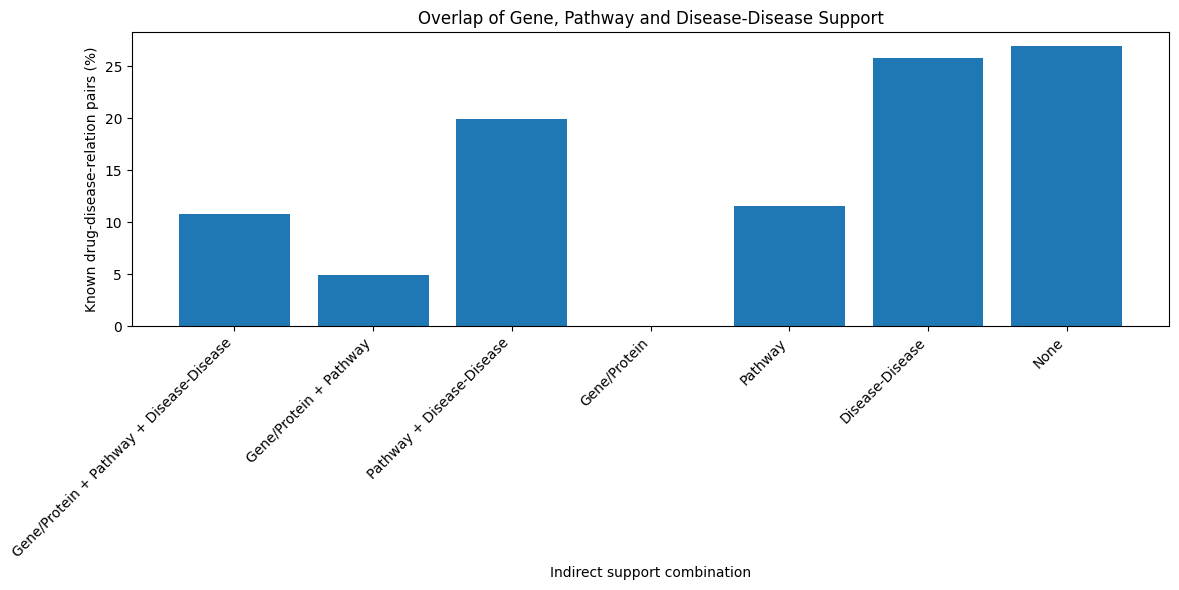

In [ ]:
#Keep one row per drug-disease-relation pair
disease_disease_unique = (
    drug_disease_disease_df[
        [
            "drug_index",
            "disease_index",
            "relation",
            "has_drug_disease_disease_path"
        ]
    ]
    .drop_duplicates(
        subset=["drug_index", "disease_index", "relation"]
    )
    .rename(
        columns={
            "has_drug_disease_disease_path":
                "has_disease_disease_support"
        }
    )
)

# Add Disease-Disease support to the existing Gene/Pathway table
overlap_df = pd.merge(
    indirect_support_df,
    disease_disease_unique,
    on=["drug_index", "disease_index", "relation"],
    how="outer"
)

boolean_columns = [
    "has_shared_gene_protein",
    "has_shared_pathway",
    "has_disease_disease_support"
]

overlap_df[boolean_columns] = (
    overlap_df[boolean_columns]
    .fillna(False)
    .astype(bool)
)

# Label every possible overlap combination
def get_support_combination(row):
    support_types = []

    if row["has_shared_gene_protein"]:
        support_types.append("Gene/Protein")

    if row["has_shared_pathway"]:
        support_types.append("Pathway")

    if row["has_disease_disease_support"]:
        support_types.append("Disease-Disease")

    if not support_types:
        return "None"

    return " + ".join(support_types)


overlap_df["support_combination"] = overlap_df.apply(
    get_support_combination,
    axis=1
)

overlap_summary = (
    overlap_df["support_combination"]
    .value_counts()
    .rename_axis("support_combination")
    .reset_index(name="pairs")
)

overlap_summary["percentage"] = (
    overlap_summary["pairs"]
    / len(overlap_df)
    * 100
).round(2)

display(overlap_summary)


combination_order = [
    "Gene/Protein + Pathway + Disease-Disease",
    "Gene/Protein + Pathway",
    "Gene/Protein + Disease-Disease",
    "Pathway + Disease-Disease",
    "Gene/Protein",
    "Pathway",
    "Disease-Disease",
    "None"
]

overlap_summary["support_combination"] = pd.Categorical(
    overlap_summary["support_combination"],
    categories=combination_order,
    ordered=True
)

overlap_summary = (
    overlap_summary
    .sort_values("support_combination")
    .reset_index(drop=True)
)

display(overlap_summary)



plt.figure(figsize=(12, 6))

plt.bar(
    overlap_summary["support_combination"].astype(str),
    overlap_summary["percentage"]
)

plt.title(
    "Overlap of Gene, Pathway and Disease-Disease Support"
)
plt.xlabel("Indirect support combination")
plt.ylabel("Known drug-disease-relation pairs (%)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Η ανάλυση επικάλυψης των πηγών έμμεσης υποστήριξης έδειξε ότι η πληροφορία που προέρχεται από τις σχέσεις μεταξύ ασθενειών αποτελεί τη σημαντικότερη μοναδική πηγή δομικής πληροφορίας, καλύπτοντας το 25,82% των γνωστών σχέσεων φαρμάκου–νόσου χωρίς να συνοδεύεται από κοινά γονίδια ή βιολογικά μονοπάτια. Επιπλέον, το 19,99% των σχέσεων υποστηρίζεται ταυτόχρονα από pathways και disease hierarchy, ενώ μόλις μία περίπτωση βασίζεται αποκλειστικά σε κοινό γονίδιο. Τέλος, το 26,94% των σχέσεων δεν υποστηρίζεται από καμία από τις τρεις εξεταζόμενες πηγές, γεγονός που υποδηλώνει ότι και άλλοι τύποι βιολογικών σχέσεων του PrimeKG συμβάλλουν στη συνδεσιμότητα του γράφου.

In [ ]:
# Incremental information gained from 2-hop to 3-hop
# and from 3-hop to 4-hop

pair_keys = [
    "drug_index",
    "disease_index",
    "relation"
]

hop_overlap_df = (
    two_hop_df[
        pair_keys + ["has_2hop_path"]
    ]
    .drop_duplicates(subset=pair_keys)
    .merge(
        three_hop_df[
            pair_keys +
            ["has_3hop_path_no_drug_disease_intermediate"]
        ].drop_duplicates(subset=pair_keys),
        on=pair_keys,
        how="outer"
    )
    .merge(
        four_hop_node_type_df[
            pair_keys +
            ["has_4hop_path_no_drug_disease_intermediate"]
        ].drop_duplicates(subset=pair_keys),
        on=pair_keys,
        how="outer"
    )
)

hop_columns = [
    "has_2hop_path",
    "has_3hop_path_no_drug_disease_intermediate",
    "has_4hop_path_no_drug_disease_intermediate"
]

hop_overlap_df[hop_columns] = (
    hop_overlap_df[hop_columns]
    .fillna(False)
    .astype(bool)
)

# Νέα pairs που εμφανίζονται στα 3-hop αλλά όχι στα 2-hop
hop_overlap_df["new_at_3hop"] = (
    ~hop_overlap_df["has_2hop_path"]
    & hop_overlap_df[
        "has_3hop_path_no_drug_disease_intermediate"
    ]
)

# Νέα pairs που εμφανίζονται στα 4-hop αλλά όχι στα 3-hop
hop_overlap_df["new_at_4hop_vs_3hop"] = (
    ~hop_overlap_df[
        "has_3hop_path_no_drug_disease_intermediate"
    ]
    & hop_overlap_df[
        "has_4hop_path_no_drug_disease_intermediate"
    ]
)

# Νέα pairs στα 4-hop που δεν είχαν ούτε 2-hop ούτε 3-hop
hop_overlap_df["new_only_at_4hop"] = (
    ~hop_overlap_df["has_2hop_path"]
    & ~hop_overlap_df[
        "has_3hop_path_no_drug_disease_intermediate"
    ]
    & hop_overlap_df[
        "has_4hop_path_no_drug_disease_intermediate"
    ]
)

total_pairs = len(hop_overlap_df)

incremental_hop_summary = pd.DataFrame({
    "comparison": [
        "2-hop coverage",
        "3-hop coverage",
        "New at 3-hop, absent at 2-hop",
        "4-hop coverage",
        "New at 4-hop, absent at 3-hop",
        "New only at 4-hop, absent at 2-hop and 3-hop"
    ],
    "pairs": [
        hop_overlap_df["has_2hop_path"].sum(),
        hop_overlap_df[
            "has_3hop_path_no_drug_disease_intermediate"
        ].sum(),
        hop_overlap_df["new_at_3hop"].sum(),
        hop_overlap_df[
            "has_4hop_path_no_drug_disease_intermediate"
        ].sum(),
        hop_overlap_df["new_at_4hop_vs_3hop"].sum(),
        hop_overlap_df["new_only_at_4hop"].sum()
    ]
})

incremental_hop_summary["percentage_of_all_pairs"] = (
    incremental_hop_summary["pairs"]
    / total_pairs
    * 100
).round(2)

display(incremental_hop_summary)

,comparison,pairs,percentage_of_all_pairs
0,2-hop coverage,40401,94.77
1,3-hop coverage,24615,57.74
2,"New at 3-hop, absent at 2-hop",397,0.93
3,4-hop coverage,32443,76.10
4,"New at 4-hop, absent at 3-hop",7870,18.46
5,"New only at 4-hop, absent at 2-hop and 3-hop",504,1.18


In [ ]:
def get_hop_combination(row):
    hops = []

    if row["has_2hop_path"]:
        hops.append("2-hop")

    if row["has_3hop_path_no_drug_disease_intermediate"]:
        hops.append("3-hop")

    if row["has_4hop_path_no_drug_disease_intermediate"]:
        hops.append("4-hop")

    return " + ".join(hops) if hops else "None"


hop_overlap_df["hop_combination"] = hop_overlap_df.apply(
    get_hop_combination,
    axis=1
)

hop_combination_summary = (
    hop_overlap_df["hop_combination"]
    .value_counts()
    .rename_axis("hop_combination")
    .reset_index(name="pairs")
)

hop_combination_summary["percentage"] = (
    hop_combination_summary["pairs"]
    / total_pairs
    * 100
).round(2)

display(hop_combination_summary)

,hop_combination,pairs,percentage
0,2-hop + 3-hop + 4-hop,24179,56.72
1,2-hop,8817,20.68
2,2-hop + 4-hop,7366,17.28
3,None,1329,3.12
4,4-hop,504,1.18
5,3-hop + 4-hop,394,0.92
6,2-hop + 3-hop,39,0.09
7,3-hop,3,0.01


In [ ]:
incremental_by_relation = (
    hop_overlap_df
    .groupby("relation")
    .agg(
        total_pairs=("relation", "size"),

        pairs_with_2hop=(
            "has_2hop_path",
            "sum"
        ),

        pairs_with_3hop=(
            "has_3hop_path_no_drug_disease_intermediate",
            "sum"
        ),

        new_pairs_at_3hop=(
            "new_at_3hop",
            "sum"
        ),

        pairs_with_4hop=(
            "has_4hop_path_no_drug_disease_intermediate",
            "sum"
        ),

        new_pairs_at_4hop=(
            "new_at_4hop_vs_3hop",
            "sum"
        ),

        new_pairs_only_at_4hop=(
            "new_only_at_4hop",
            "sum"
        )
    )
    .reset_index()
)

for column in [
    "pairs_with_2hop",
    "pairs_with_3hop",
    "new_pairs_at_3hop",
    "pairs_with_4hop",
    "new_pairs_at_4hop",
    "new_pairs_only_at_4hop"
]:
    incremental_by_relation[
        f"{column}_percent"
    ] = (
        incremental_by_relation[column]
        / incremental_by_relation["total_pairs"]
        * 100
    ).round(2)

display(incremental_by_relation)

,relation,total_pairs,pairs_with_2hop,pairs_with_3hop,new_pairs_at_3hop,pairs_with_4hop,new_pairs_at_4hop,new_pairs_only_at_4hop,pairs_with_2hop_percent,pairs_with_3hop_percent,new_pairs_at_3hop_percent,pairs_with_4hop_percent,new_pairs_at_4hop_percent,new_pairs_only_at_4hop_percent
0,contraindication,30675,29361,17853,265,23823,5994,329,95.72,58.20,0.86,77.66,19.54,1.07
1,indication,9388,8610,5174,111,6708,1550,146,91.71,55.11,1.18,71.45,16.51,1.56
2,off-label use,2568,2430,1588,21,1912,326,29,94.63,61.84,0.82,74.45,12.69,1.13
